# 03 - Data Preparation: Data Exploration Cleaned Dataset
This notebook performs the data exploration and analysis phase after the cleaning step. It loads the cleaned dataset from `data/interim/` folder and perform all the essential steps of the EDA process.

## Import libraries and settings

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from pathlib import Path

from myocardial_infarction_mortality.config import (
    INTERIM_DATA_DIR,
    FILENAME_BASE,
    SELECTED_TIME_SLOT,
    FIGURES_DIR,
    FLOAT_FEATURES,
    INT_FEATURES,
    CATEGORICAL_NOMINAL_FEATURES,
    CATEGORICAL_ORDINAL_FEATURES,
    CATEGORICAL_ORDINAL_FEATURES_WITH_ORDER
)
from myocardial_infarction_mortality.utils.io_utils import load_dataset_with_schema

In [28]:
target : str = "LET_IS_BINARY"

In [29]:
input_path : Path = INTERIM_DATA_DIR / f"{FILENAME_BASE}_{SELECTED_TIME_SLOT}_{target}_cleaned.csv"
print(f"Loading dataset at path:\n\t{input_path}")

Loading dataset at path:
	/home/leonardosaccotelli/Desktop/UNIVERSITA/MACHINE-LEARNING/Cost-Sensitive-Learning-For-Myocardial-Infarction-Mortality-Prediction/data/interim/myocardial_infarction_admission_LET_IS_BINARY_cleaned.csv


In [30]:
FIGURES_DATA_EXPLORATION_DIR = FIGURES_DIR / "DP_data_exploration_cleaned"
FIGURES_DATA_EXPLORATION_DIR.mkdir(parents=True, exist_ok=True)

In [31]:
pd.set_option("display.max_columns", None)
plt.rcParams.update({"font.size": 16})
sns.set_style("whitegrid")
sns.set_palette("tab10")

## Data Loading
We begin by loading the myocardial infarction mortality dataset. This is the untouched file downloaded from ucimlrepo.

In [32]:
df: pd.DataFrame = load_dataset_with_schema(
    file_path=input_path,
    delimiter=",",
    header=0,
    index_col=0,
    float_features=FLOAT_FEATURES,
    int_features=INT_FEATURES,
    categorical_nominal_features=CATEGORICAL_NOMINAL_FEATURES,
    categorical_ordinal_features=CATEGORICAL_ORDINAL_FEATURES_WITH_ORDER
)

print(f"Dataset dimension\n"
      f"\t-Number of rows = {df.shape[0]}\n"
      f"\t-Number of cols = {df.shape[1]}")

Dataset dimension
	-Number of rows = 1572
	-Number of cols = 96


## Basic Overview

In [33]:
df.head(10)

,AGE,SEX,INF_ANAM,STENOK_AN,FK_STENOK,IBS_POST,GB,SIM_GIPERT,DLIT_AG,ZSN_A,nr_11,nr_01,nr_02,nr_03,nr_04,nr_07,nr_08,np_01,np_04,np_05,np_07,np_08,np_09,np_10,endocr_01,endocr_02,endocr_03,zab_leg_01,zab_leg_02,zab_leg_03,zab_leg_04,zab_leg_06,S_AD_ORIT,D_AD_ORIT,O_L_POST,K_SH_POST,MP_TP_POST,SVT_POST,GT_POST,FIB_G_POST,ant_im,lat_im,inf_im,post_im,IM_PG_P,ritm_ecg_p_01,ritm_ecg_p_02,ritm_ecg_p_04,ritm_ecg_p_06,ritm_ecg_p_07,ritm_ecg_p_08,n_r_ecg_p_01,n_r_ecg_p_02,n_r_ecg_p_03,n_r_ecg_p_04,n_r_ecg_p_05,n_r_ecg_p_06,n_r_ecg_p_08,n_r_ecg_p_09,n_r_ecg_p_10,n_p_ecg_p_01,n_p_ecg_p_03,n_p_ecg_p_04,n_p_ecg_p_05,n_p_ecg_p_06,n_p_ecg_p_07,n_p_ecg_p_08,n_p_ecg_p_09,n_p_ecg_p_10,n_p_ecg_p_11,n_p_ecg_p_12,fibr_ter_01,fibr_ter_02,fibr_ter_03,fibr_ter_05,fibr_ter_06,fibr_ter_07,fibr_ter_08,GIPO_K,K_BLOOD,GIPER_NA,NA_BLOOD,ALT_BLOOD,AST_BLOOD,L_BLOOD,ROE,TIME_B_S,NITR_S,LID_S_n,B_BLOK_S_n,ANT_CA_S_n,GEPAR_S_n,ASP_S_n,TIKL_S_n,TRENT_S_n,LET_IS_BINARY
ID,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1,77,1,2,1,1,2.0,3,0.0,7,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,180,100,0.0,0.0,0.0,0.0,0.0,0.0,1,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.7,0.0,138.0,NaN,NaN,8.0,16.0,4,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0
2,55,1,1,0,0,0.0,0,0.0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,120,90,0.0,0.0,0.0,0.0,0.0,0.0,4,1,0,0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,3.5,0.0,132.0,0.38,0.18,7.8,3.0,2,0.0,1.0,0.0,1.0,1.0,1.0,0.0,1.0,0
3,52,1,0,0,0,2.0,2,0.0,2,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,180,100,0.0,0.0,0.0,0.0,0.0,0.0,4,1,0,0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,0.0,132.0,0.30,0.11,10.8,NaN,3,0.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,0
4,68,0,0,0,0,2.0,2,0.0,3,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,120,70,0.0,0.0,0.0,0.0,0.0,0.0,0,1,1,0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,3.9,0.0,146.0,0.75,0.37,NaN,NaN,2,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0
5,60,1,0,0,0,2.0,3,0.0,7,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,160,90,0.0,0.0,0.0,0.0,0.0,0.0,4,1,0,0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,3.5,0.0,132.0,0.45,0.22,8.3,NaN,9,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0
6,64,1,0,1,2,1.0,0,0.0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,140,90,0.0,0.0,0.0,0.0,0.0,0.0,1,1,0,0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,0.45,0.22,7.2,2.0,2,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0
7,70,1,1,1,2,1.0,2,0.0,7,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,120,80,0.0,0.0,0.0,0.0,0.0,0.0,0,0,3,0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,0.30,0.11,11.1,5.0,1,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0
8,65,1,0,1,1,2.0,2,0.0,7,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,145,95,0.0,0.0,0.0,0.0,0.0,0.0,0,0,2,0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.5,0.0,136.0,NaN,NaN,6.2,20.0,7,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0
9,60,1,0,0,0,2.0,2,0.0,6,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0

In [34]:
df.tail(10)

,AGE,SEX,INF_ANAM,STENOK_AN,FK_STENOK,IBS_POST,GB,SIM_GIPERT,DLIT_AG,ZSN_A,nr_11,nr_01,nr_02,nr_03,nr_04,nr_07,nr_08,np_01,np_04,np_05,np_07,np_08,np_09,np_10,endocr_01,endocr_02,endocr_03,zab_leg_01,zab_leg_02,zab_leg_03,zab_leg_04,zab_leg_06,S_AD_ORIT,D_AD_ORIT,O_L_POST,K_SH_POST,MP_TP_POST,SVT_POST,GT_POST,FIB_G_POST,ant_im,lat_im,inf_im,post_im,IM_PG_P,ritm_ecg_p_01,ritm_ecg_p_02,ritm_ecg_p_04,ritm_ecg_p_06,ritm_ecg_p_07,ritm_ecg_p_08,n_r_ecg_p_01,n_r_ecg_p_02,n_r_ecg_p_03,n_r_ecg_p_04,n_r_ecg_p_05,n_r_ecg_p_06,n_r_ecg_p_08,n_r_ecg_p_09,n_r_ecg_p_10,n_p_ecg_p_01,n_p_ecg_p_03,n_p_ecg_p_04,n_p_ecg_p_05,n_p_ecg_p_06,n_p_ecg_p_07,n_p_ecg_p_08,n_p_ecg_p_09,n_p_ecg_p_10,n_p_ecg_p_11,n_p_ecg_p_12,fibr_ter_01,fibr_ter_02,fibr_ter_03,fibr_ter_05,fibr_ter_06,fibr_ter_07,fibr_ter_08,GIPO_K,K_BLOOD,GIPER_NA,NA_BLOOD,ALT_BLOOD,AST_BLOOD,L_BLOOD,ROE,TIME_B_S,NITR_S,LID_S_n,B_BLOK_S_n,ANT_CA_S_n,GEPAR_S_n,ASP_S_n,TIKL_S_n,TRENT_S_n,LET_IS_BINARY
ID,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1690,53,1,1,NaN,NaN,2.0,0,0.0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,110,70,1.0,0.0,0.0,0.0,0.0,0.0,4,2,0,0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.6,0.0,136.0,NaN,NaN,10.6,27.0,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
1691,77,1,0,0,0,0.0,2,0.0,NaN,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,140,80,0.0,0.0,0.0,0.0,0.0,0.0,0,0,4,0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,5.4,13.0,5,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1
1692,62,1,0,0,0,0.0,0,1.0,7,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,140,80,0.0,0.0,0.0,0.0,0.0,0.0,4,1,0,0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,4.9,0.0,133.0,0.15,0.07,10.5,3.0,1,0.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0,1
1693,71,0,0,6,2,2.0,2,0.0,7,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,110,70,0.0,0.0,0.0,0.0,0.0,0.0,4,2,0,0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,3.4,0.0,133.0,0.52,0.22,5.1,8.0,1,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,1
1694,70,0,0,2,2,1.0,2,0.0,7,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,140,80,0.0,0.0,0.0,0.0,0.0,0.0,4,1,0,0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,0.52,0.48,NaN,NaN,1,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1
1695,77,0,0,0,0,0.0,2,0.0,7,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,150,90,0.0,0.0,0.0,0.0,0.0,0.0,4,1,0,0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,3.9,0.0,136.0,0.23,0.18,5.5,20.0,3,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1
1696,77,0,0,4,2,1.0,2,0.0,7,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,110,70,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,0,0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,3.7,0.0,130.0,1.05,0.52,12.8,6.0,2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
1697,70,0,0,6,2,1.0,2,0.0,7,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,50,0,0.0,1.0,0.0,0.0,0.0,0.0,0,0,2,1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1
1699,79,0,2,2,2,1.0,2,0.0,7,

In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1572 entries, 1 to 1700
Data columns (total 96 columns):
 #   Column         Non-Null Count  Dtype   
---  ------         --------------  -----   
 0   AGE            1565 non-null   Int64   
 1   SEX            1572 non-null   category
 2   INF_ANAM       1571 non-null   category
 3   STENOK_AN      1487 non-null   category
 4   FK_STENOK      1516 non-null   category
 5   IBS_POST       1534 non-null   category
 6   GB             1570 non-null   category
 7   SIM_GIPERT     1570 non-null   category
 8   DLIT_AG        1355 non-null   category
 9   ZSN_A          1531 non-null   category
 10  nr_11          1566 non-null   category
 11  nr_01          1566 non-null   category
 12  nr_02          1566 non-null   category
 13  nr_03          1566 non-null   category
 14  nr_04          1566 non-null   category
 15  nr_07          1566 non-null   category
 16  nr_08          1566 non-null   category
 17  np_01          1568 non-null   categor

## Missing Values Inspection

[SAVED] /home/leonardosaccotelli/Desktop/UNIVERSITA/MACHINE-LEARNING/Cost-Sensitive-Learning-For-Myocardial-Infarction-Mortality-Prediction/reports/figures/DP_data_exploration_cleaned/missing_values_heatmap.png


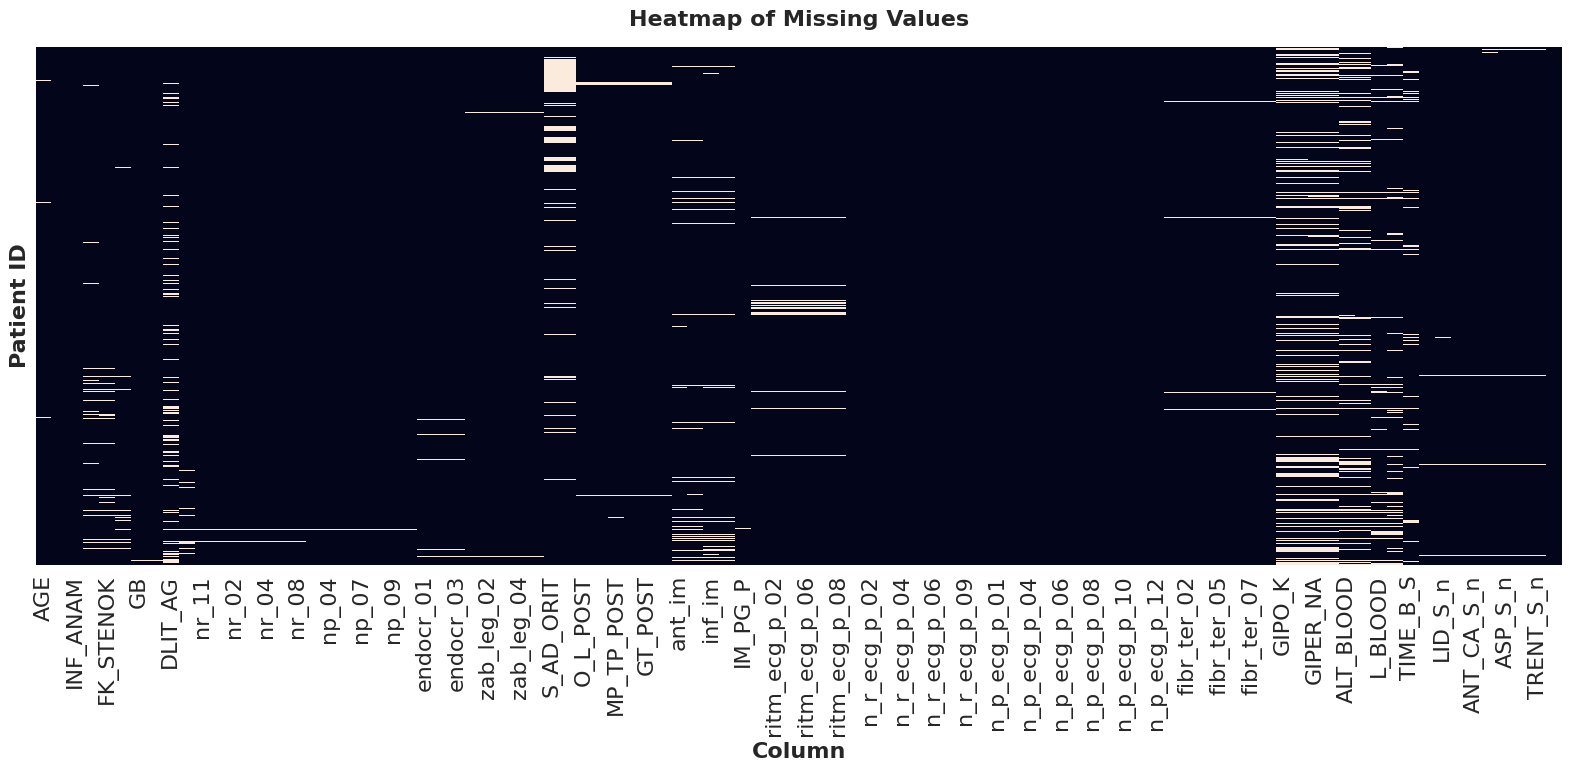

In [36]:
plt.figure(figsize=(16, 8))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False)
plt.xlabel("Column", fontweight="bold")
plt.ylabel("Patient ID", fontweight="bold")
plt.xticks(rotation=90)
plt.title("Heatmap of Missing Values",
          fontsize=16,
          fontweight="bold",
          pad=15
          )
plt.tight_layout()

missing_values_heatmap_path: Path = FIGURES_DATA_EXPLORATION_DIR / "missing_values_heatmap.png"
plt.savefig(FIGURES_DATA_EXPLORATION_DIR / missing_values_heatmap_path, dpi=300)
print(f"[SAVED] {missing_values_heatmap_path}")

plt.show()

In [37]:
# Compute missingness per column
n_rows: int = df.shape[0]

col_missing_count: pd.Series = df.isnull().sum(axis=0)
col_missing_pct: pd.Series = (col_missing_count / n_rows * 100.0) if n_rows > 0 else (col_missing_count * 0.0)

missing_by_column_df: pd.DataFrame = (
    pd.DataFrame(
        {
            "column": col_missing_count.index.astype(str),
            "missing_count": col_missing_count.values.astype(int),
            "missing_pct": col_missing_pct.values.astype(float),
        }
    )
    .sort_values(by=["missing_pct", "missing_count"], ascending=False)
    .reset_index(drop=True)
)

missing_by_column_df

,column,missing_count,missing_pct
0,GIPER_NA,333,21.183206
1,NA_BLOOD,333,21.183206
2,K_BLOOD,330,20.992366
3,GIPO_K,328,20.865140
4,AST_BLOOD,258,16.412214
...,...,...,...
91,n_p_ecg_p_10,1,0.063613
92,n_p_ecg_p_11,1,0.063613
93,n_p_ecg_p_12,1,0.063613
94,SEX,0,0.000000


In [38]:
missing_by_column_path: Path = FIGURES_DATA_EXPLORATION_DIR / "missingness_by_column.csv"
missing_by_column_df.to_csv(missing_by_column_path, index=False)
print(f"[SAVED] {missing_by_column_path}")

[SAVED] /home/leonardosaccotelli/Desktop/UNIVERSITA/MACHINE-LEARNING/Cost-Sensitive-Learning-For-Myocardial-Infarction-Mortality-Prediction/reports/figures/DP_data_exploration_cleaned/missingness_by_column.csv


In [39]:
bins = [-0.1, 0, 1, 5, 10, 20, 50, 80, 100.0]
labels = ["0%", "(0-1]%", "(1-5]%", "(5-10]%", "(10-20]%", "(20-50]%", "(50-80]%", "(80-100]%"]

missing_by_column_df["missing_bin"] = pd.cut(missing_by_column_df["missing_pct"], bins=bins, labels=labels)

bin_summary_df: pd.DataFrame = (
    missing_by_column_df["missing_bin"]
    .value_counts(dropna=False)
    .rename_axis("missing_bin")
    .reset_index(name="n_columns")
    .sort_values(by=["missing_bin"], ascending=True)
)

bin_summary_df

,missing_bin,n_columns
5,0%,2
0,(0-1]%,64
1,(1-5]%,17
4,(5-10]%,3
2,(10-20]%,6
3,(20-50]%,4
6,(50-80]%,0
7,(80-100]%,0


In [40]:
bin_features_path: Path = FIGURES_DATA_EXPLORATION_DIR / "missingness_by_column_bins_features.csv"
bin_summary_df.to_csv(bin_features_path, index=False)
print(f"[SAVED] {bin_features_path}")

[SAVED] /home/leonardosaccotelli/Desktop/UNIVERSITA/MACHINE-LEARNING/Cost-Sensitive-Learning-For-Myocardial-Infarction-Mortality-Prediction/reports/figures/DP_data_exploration_cleaned/missingness_by_column_bins_features.csv


## Class Balance by targets
Plot the samples distribution with respect to the `LET_IS_BINARY` target:
- `0=ALIVE`
- `1=DEAD`

[SAVED] /home/leonardosaccotelli/Desktop/UNIVERSITA/MACHINE-LEARNING/Cost-Sensitive-Learning-For-Myocardial-Infarction-Mortality-Prediction/reports/figures/DP_data_exploration_cleaned/class_distribution_absolute_vs_percentage_LET_IS_BINARY.png


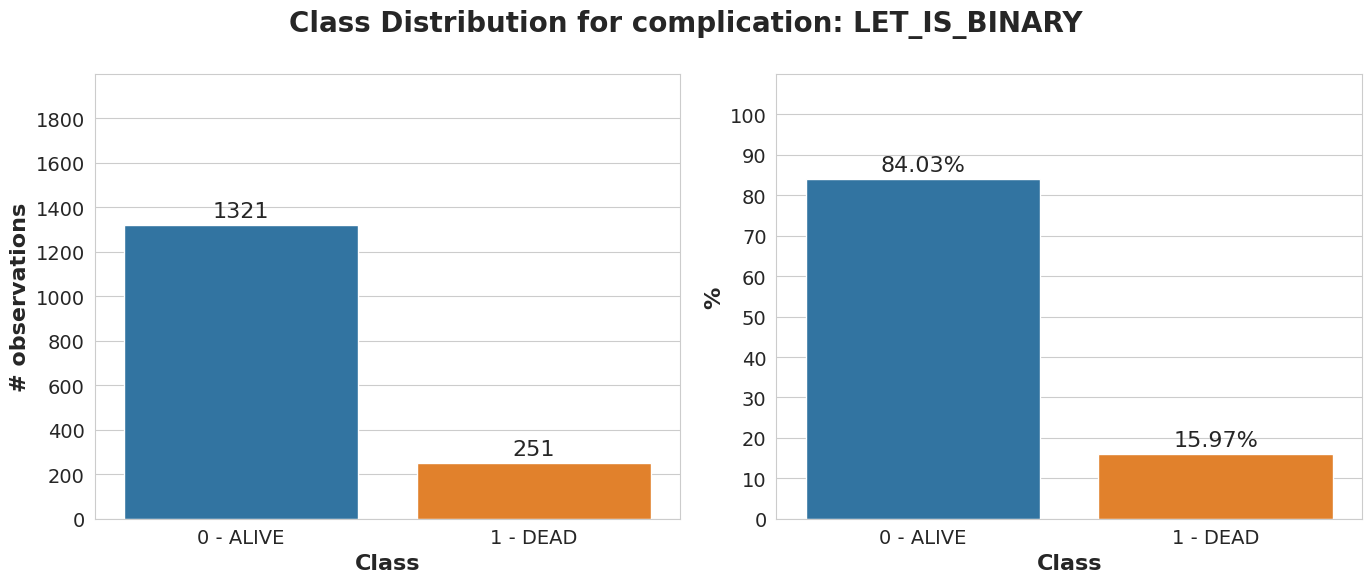

In [41]:
class_counts = df[target].value_counts().sort_index()
total = class_counts.sum()
class_percentages = class_counts / total * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ------- Subplot 1: Counting the observations per class
sns.countplot(ax=axes[0],
              data=df,
              x=target,
              hue=target,
              legend=False)
axes[0].set_xlabel("Class", fontweight="bold", fontsize=16)
axes[0].set_ylabel("# observations", fontweight="bold", fontsize=16)
axes[0].set_xticks(ticks=[0, 1], labels=["0 - ALIVE", "1 - DEAD"], fontsize=14)
axes[0].set_yticks(ticks=np.arange(0, 2000, 200),
                   labels=np.arange(0, 2000, 200),
                   fontsize=14)
axes[0].set_ylim(0, 2000)

for container in axes[0].containers:
    axes[0].bar_label(container, fmt="%.0f", padding=3)

axes[0].margins(y=0.1) # Avoid clipping labels at the top

# ------- Subplot 2: Percentage per class
sns.barplot(ax=axes[1],
            x=class_percentages.index.astype(str),
            y=class_percentages.values,
            hue=class_percentages.index.astype(str))
axes[1].set_xlabel("Class", fontweight="bold", fontsize=16)
axes[1].set_ylabel("%", fontweight="bold", fontsize=16)
axes[1].set_xticks(ticks=[0, 1], labels=["0 - ALIVE", "1 - DEAD"], fontsize=14)
axes[1].set_yticks(ticks=np.arange(0, 110, 10),
                   labels=np.arange(0, 110, 10),
                   fontsize=14)
axes[1].set_ylim(0, 110)

for container in axes[1].containers:
    axes[1].bar_label(container, fmt="%.2f%%", padding=3)

axes[1].margins(y=0.1)

# ------- General settings
plt.suptitle(f"Class Distribution for complication: {target}", fontsize=20, fontweight="bold")
plt.tight_layout()

class_distribution_path: Path = FIGURES_DATA_EXPLORATION_DIR / f"class_distribution_absolute_vs_percentage_{target}.png"
plt.savefig(class_distribution_path, dpi=300)
print(f"[SAVED] {class_distribution_path}")

plt.show()

##  Quantitative Variables Analysis

### Quantitative Discrete Variables Analysis

In [42]:
cols_int = [c for c in INT_FEATURES if c in df.columns]
missing_int = [c for c in INT_FEATURES if c not in df.columns]
print(f"INT present: {len(cols_int)} | missing: {len(missing_int)}")
if missing_int:
    print("Missing INT columns:", missing_int)

INT present: 3 | missing: 2
Missing INT columns: ['S_AD_KBRIG', 'D_AD_KBRIG']


In [43]:
df[cols_int].describe()

,AGE,S_AD_ORIT,D_AD_ORIT
count,1565.0,1323.0,1323.0
mean,61.61853,134.882842,83.080121
std,11.344784,29.960979,17.238943
min,26.0,0.0,0.0
25%,54.0,120.0,80.0
50%,62.0,130.0,80.0
75%,70.0,150.0,90.0
max,92.0,240.0,190.0


In [44]:
df[cols_int].skew()

AGE         -0.208875
S_AD_ORIT    -0.11761
D_AD_ORIT   -0.801307
dtype: Float64

[SAVED] /home/leonardosaccotelli/Desktop/UNIVERSITA/MACHINE-LEARNING/Cost-Sensitive-Learning-For-Myocardial-Infarction-Mortality-Prediction/reports/figures/DP_data_exploration_cleaned/hist_kde_qqplot_AGE.png


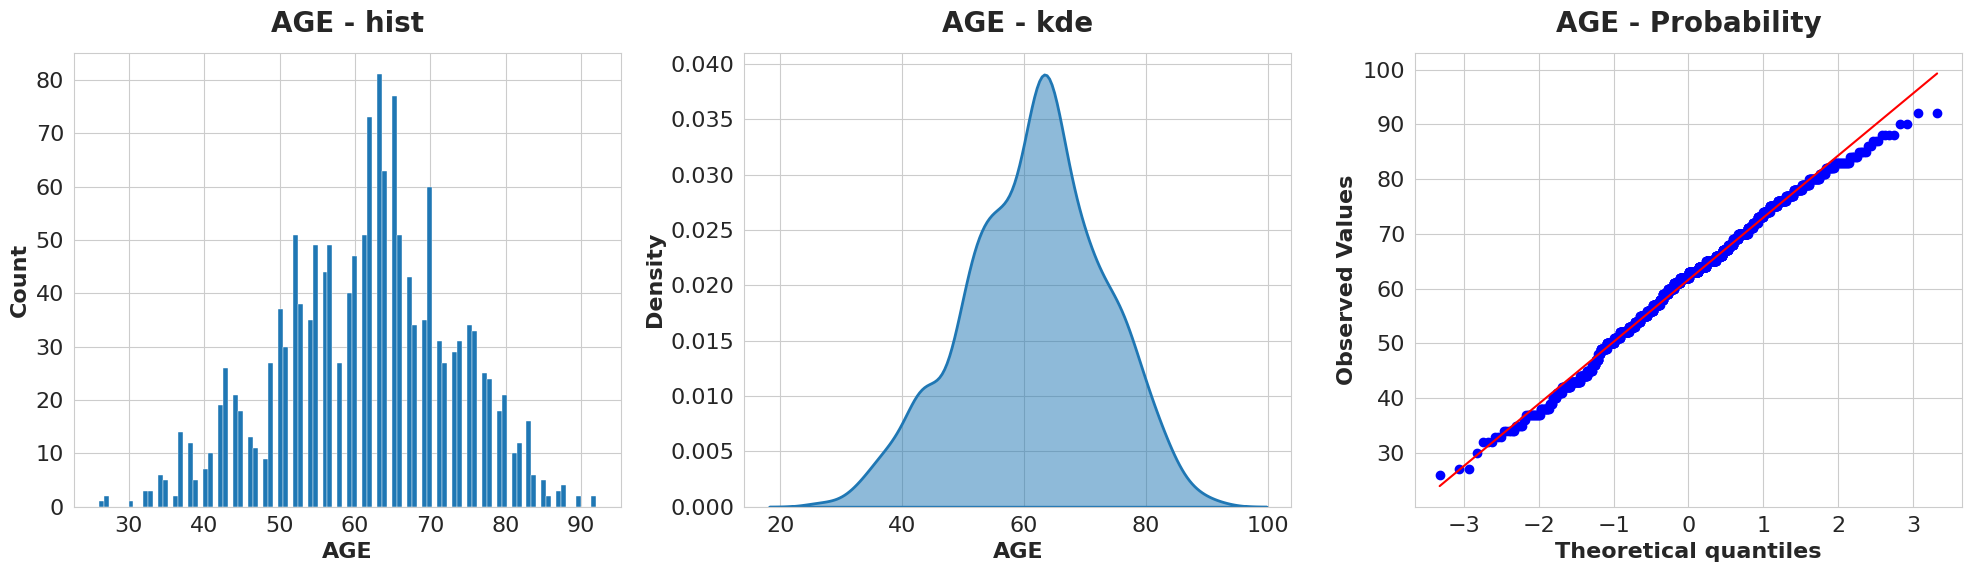

[SAVED] /home/leonardosaccotelli/Desktop/UNIVERSITA/MACHINE-LEARNING/Cost-Sensitive-Learning-For-Myocardial-Infarction-Mortality-Prediction/reports/figures/DP_data_exploration_cleaned/hist_kde_qqplot_S_AD_ORIT.png


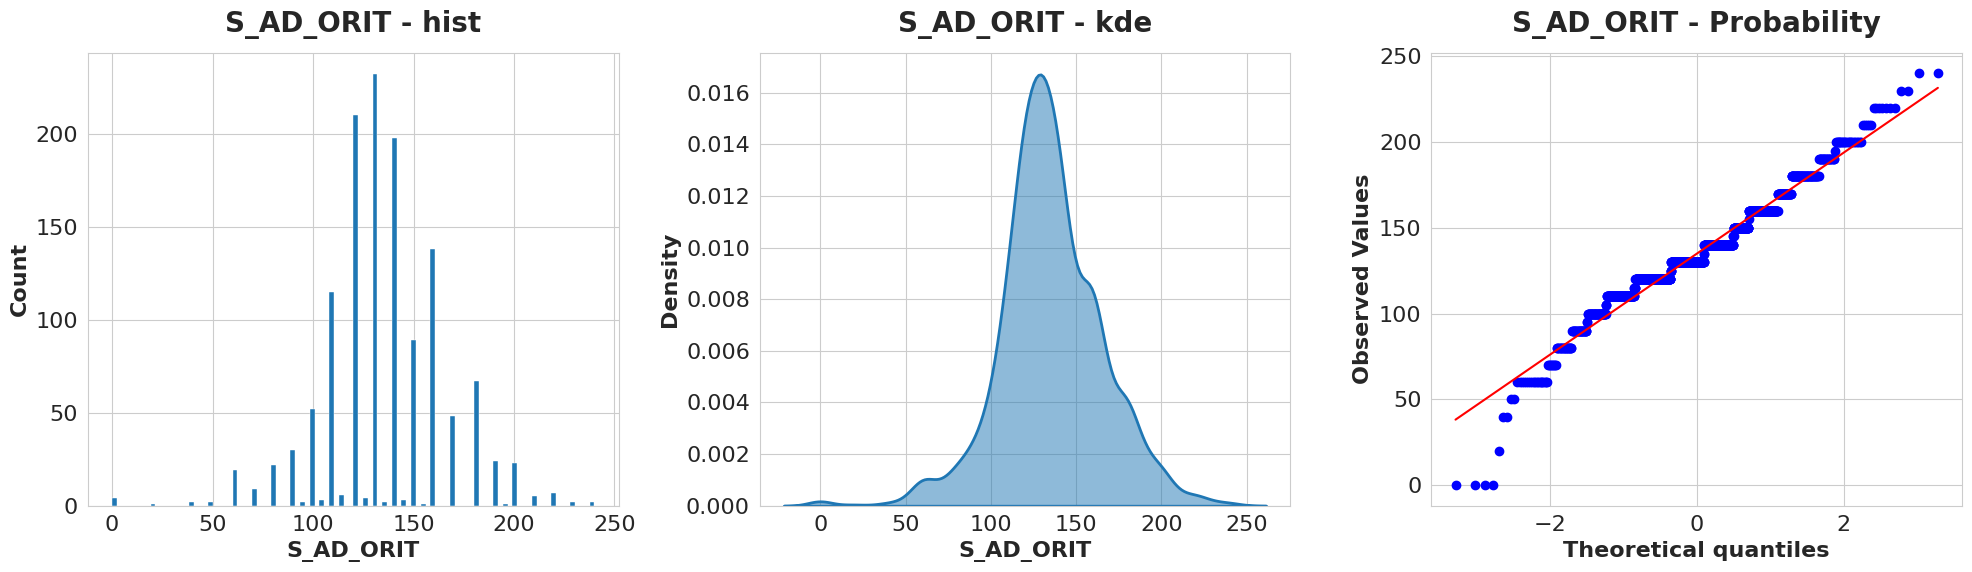

[SAVED] /home/leonardosaccotelli/Desktop/UNIVERSITA/MACHINE-LEARNING/Cost-Sensitive-Learning-For-Myocardial-Infarction-Mortality-Prediction/reports/figures/DP_data_exploration_cleaned/hist_kde_qqplot_D_AD_ORIT.png


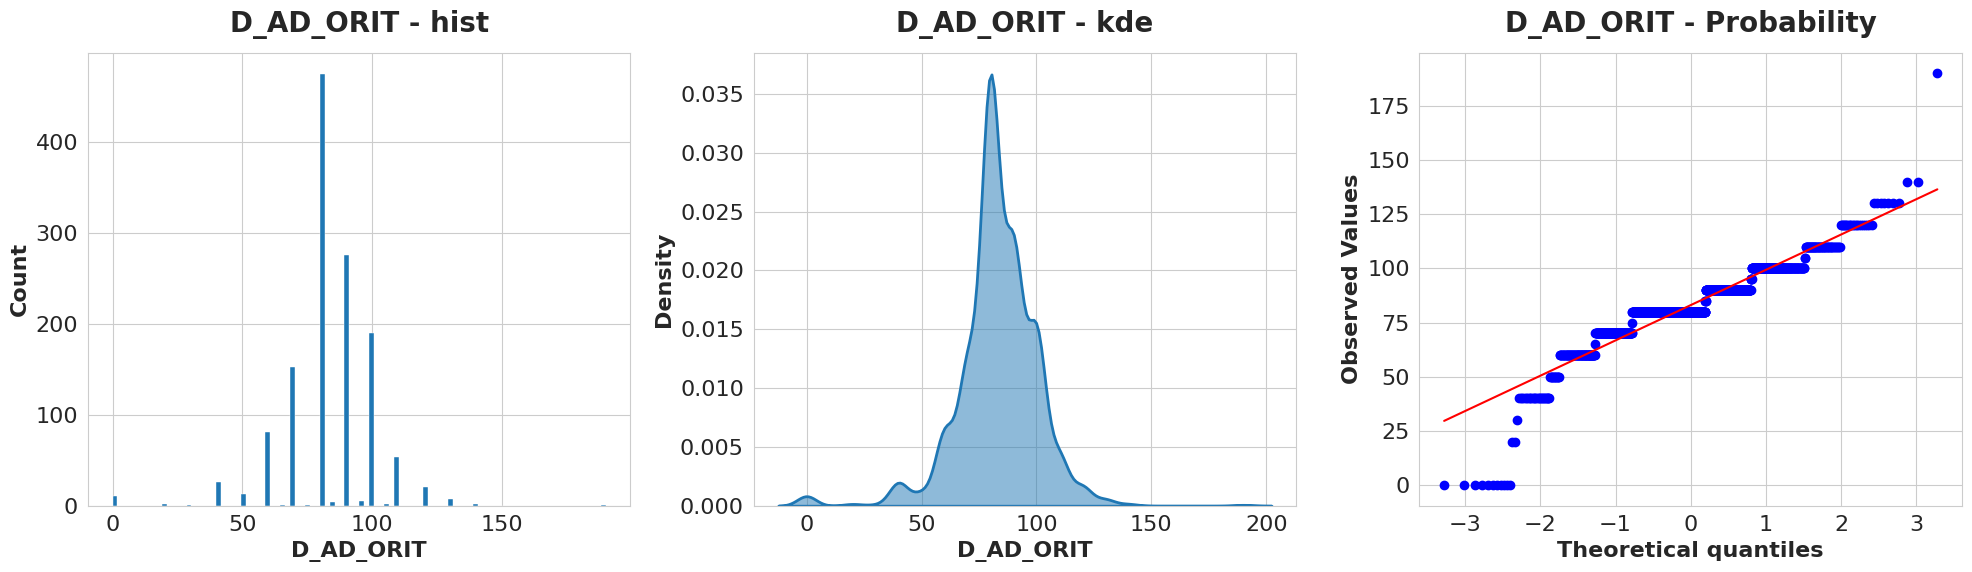

In [45]:
for num_variable in cols_int:
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))

    sns.histplot(ax=axes[0],
                 data=df,
                 x=num_variable,
                 bins=100,
                 stat="count",
                 kde=False,
                 color=sns.color_palette()[0],
                 alpha=1.0,
                 fill=True,)
    axes[0].set_xlabel(num_variable, fontweight="bold", fontsize=16)
    axes[0].set_ylabel("Count", fontweight="bold", fontsize=16)
    axes[0].set_title(f"{num_variable} - hist", fontsize=20, fontweight="bold", pad=15)

    sns.kdeplot(ax=axes[1],
                data=df,
                x=num_variable,
                fill=True,
                common_norm=False,
                alpha=0.5,
                linewidth=2.0,)
    axes[1].set_xlabel(num_variable, fontweight="bold", fontsize=16)
    axes[1].set_ylabel("Density", fontweight="bold", fontsize=16)
    axes[1].set_title(f"{num_variable} - kde", fontsize=20, fontweight="bold", pad=15)

    stats.probplot(plot=axes[2],
                   x=df[num_variable].replace([np.inf, -np.inf], np.nan).dropna().to_numpy(),
                   dist="norm",)
    axes[2].set_xlabel("Theoretical quantiles", fontweight="bold", fontsize=16)
    axes[2].set_ylabel("Observed Values", fontweight="bold", fontsize=16)
    axes[2].set_title(f"{num_variable} - Probability", fontsize=20, fontweight="bold", pad=15)

    # ------- General settings
    plt.tight_layout()

    int_features_hist_path: Path = FIGURES_DATA_EXPLORATION_DIR / f"hist_kde_qqplot_{num_variable}.png"
    plt.savefig(int_features_hist_path, dpi=300)
    print(f"[SAVED] {int_features_hist_path}")

    plt.show()

### Quantitative Continuous Variables Analysis


In [46]:
cols_float = [c for c in FLOAT_FEATURES if c in df.columns]
missing_float = [c for c in FLOAT_FEATURES if c not in df.columns]
print(f"FLOAT present: {len(cols_float)} | missing: {len(missing_float)}")
if missing_float:
    print("Missing FLOAT columns:", missing_float)

FLOAT present: 6 | missing: 1
Missing FLOAT columns: ['KFK_BLOOD']


In [47]:
df[cols_float].describe()

,K_BLOOD,NA_BLOOD,ALT_BLOOD,AST_BLOOD,L_BLOOD,ROE
count,1242.000000,1239.000000,1315.000000,1314.000000,1458.000000,1392.000000
mean,4.198148,136.505246,0.486015,0.266058,8.767620,13.479167
std,0.761517,6.541388,0.390900,0.204835,3.410375,11.477650
min,2.300000,117.000000,0.030000,0.040000,2.000000,1.000000
25%,3.700000,133.000000,0.230000,0.150000,6.400000,5.000000
50%,4.100000,136.000000,0.380000,0.220000,8.000000,10.000000
75%,4.600000,140.000000,0.610000,0.330000,10.400000,18.000000
max,8.200000,169.000000,3.000000,2.150000,27.900000,140.000000


In [48]:
df[cols_float].skew()

K_BLOOD      0.963945
NA_BLOOD     0.149380
ALT_BLOOD    2.266341
AST_BLOOD    2.558408
L_BLOOD      1.350217
ROE          2.312538
dtype: float64

[SAVED] /home/leonardosaccotelli/Desktop/UNIVERSITA/MACHINE-LEARNING/Cost-Sensitive-Learning-For-Myocardial-Infarction-Mortality-Prediction/reports/figures/DP_data_exploration_cleaned/hist_kde_qqplot_K_BLOOD.png


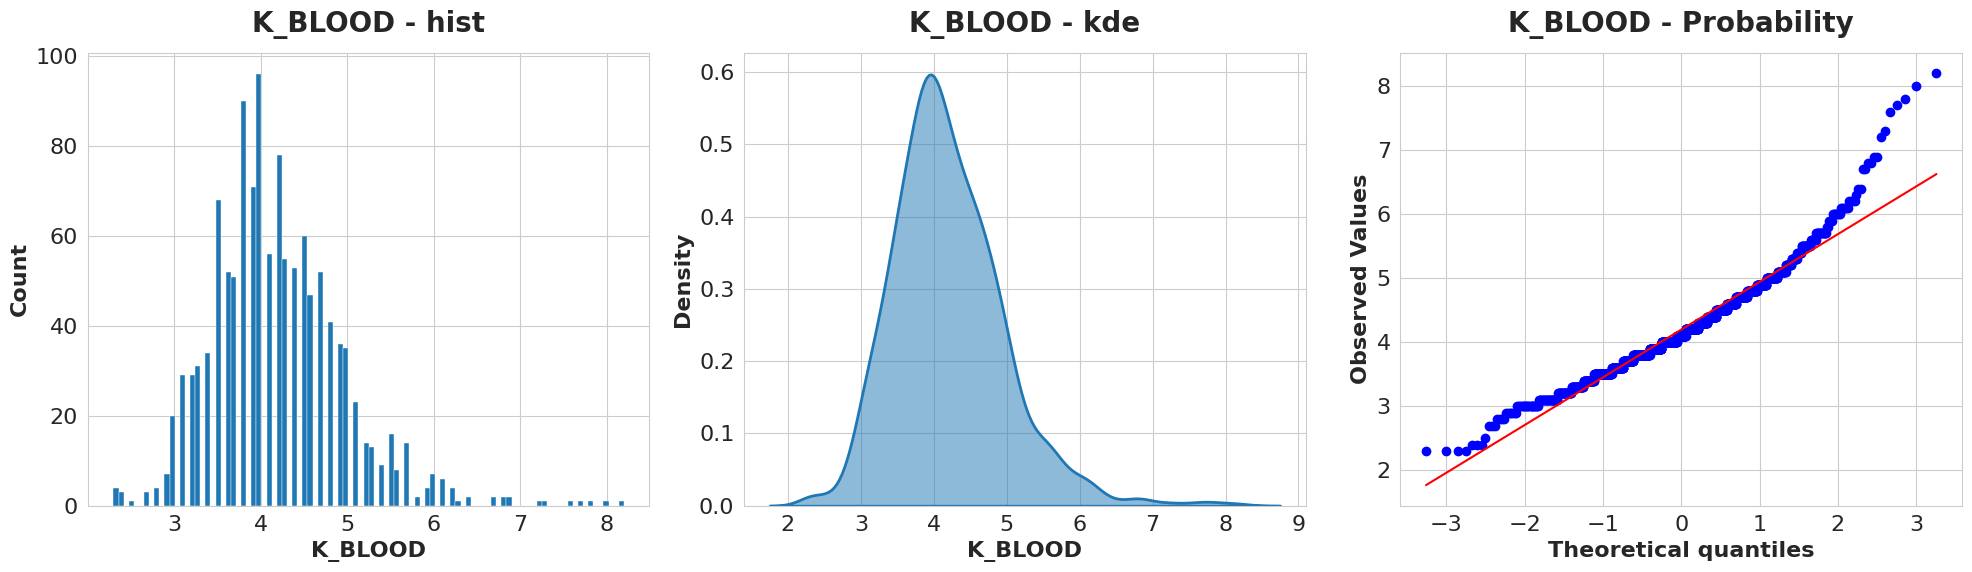

[SAVED] /home/leonardosaccotelli/Desktop/UNIVERSITA/MACHINE-LEARNING/Cost-Sensitive-Learning-For-Myocardial-Infarction-Mortality-Prediction/reports/figures/DP_data_exploration_cleaned/hist_kde_qqplot_NA_BLOOD.png


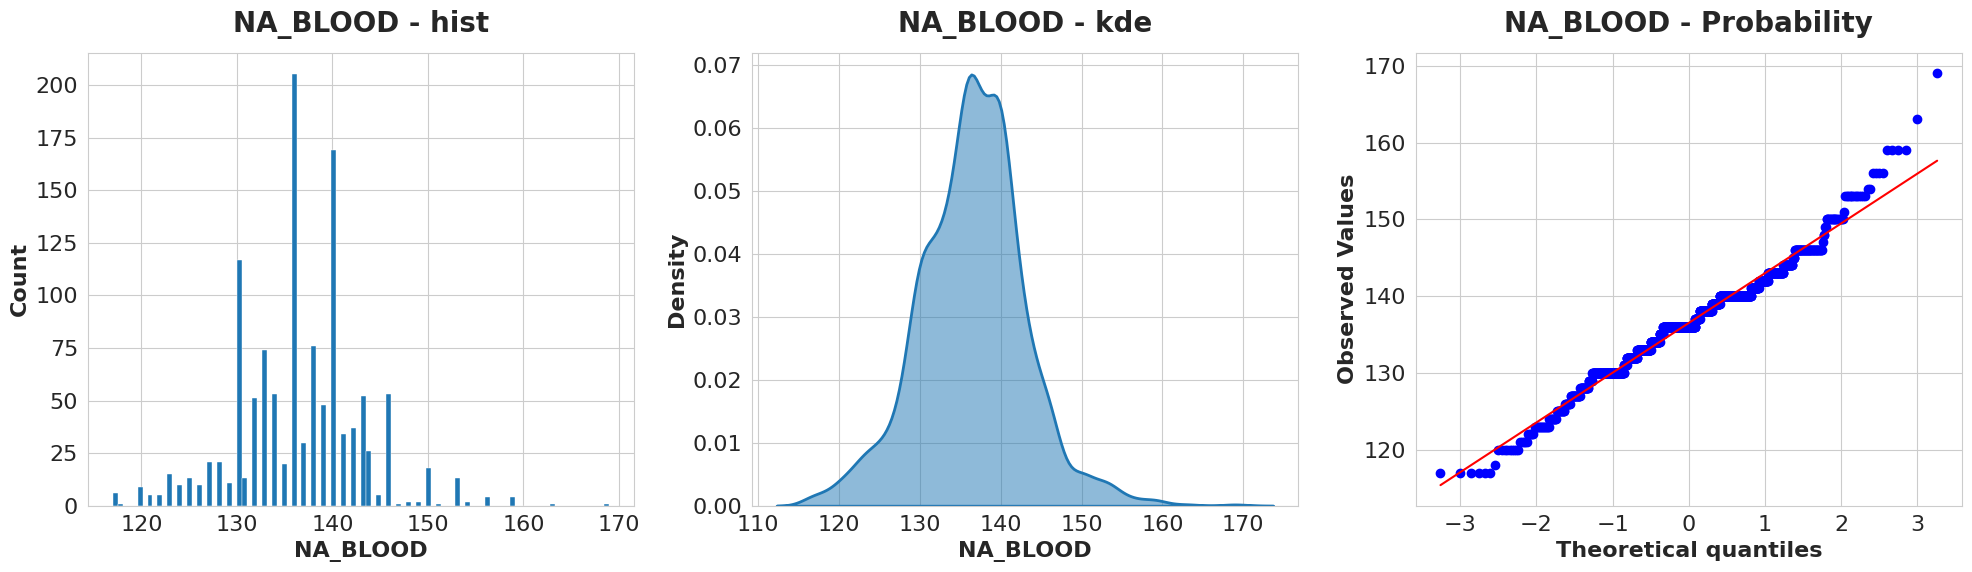

[SAVED] /home/leonardosaccotelli/Desktop/UNIVERSITA/MACHINE-LEARNING/Cost-Sensitive-Learning-For-Myocardial-Infarction-Mortality-Prediction/reports/figures/DP_data_exploration_cleaned/hist_kde_qqplot_ALT_BLOOD.png


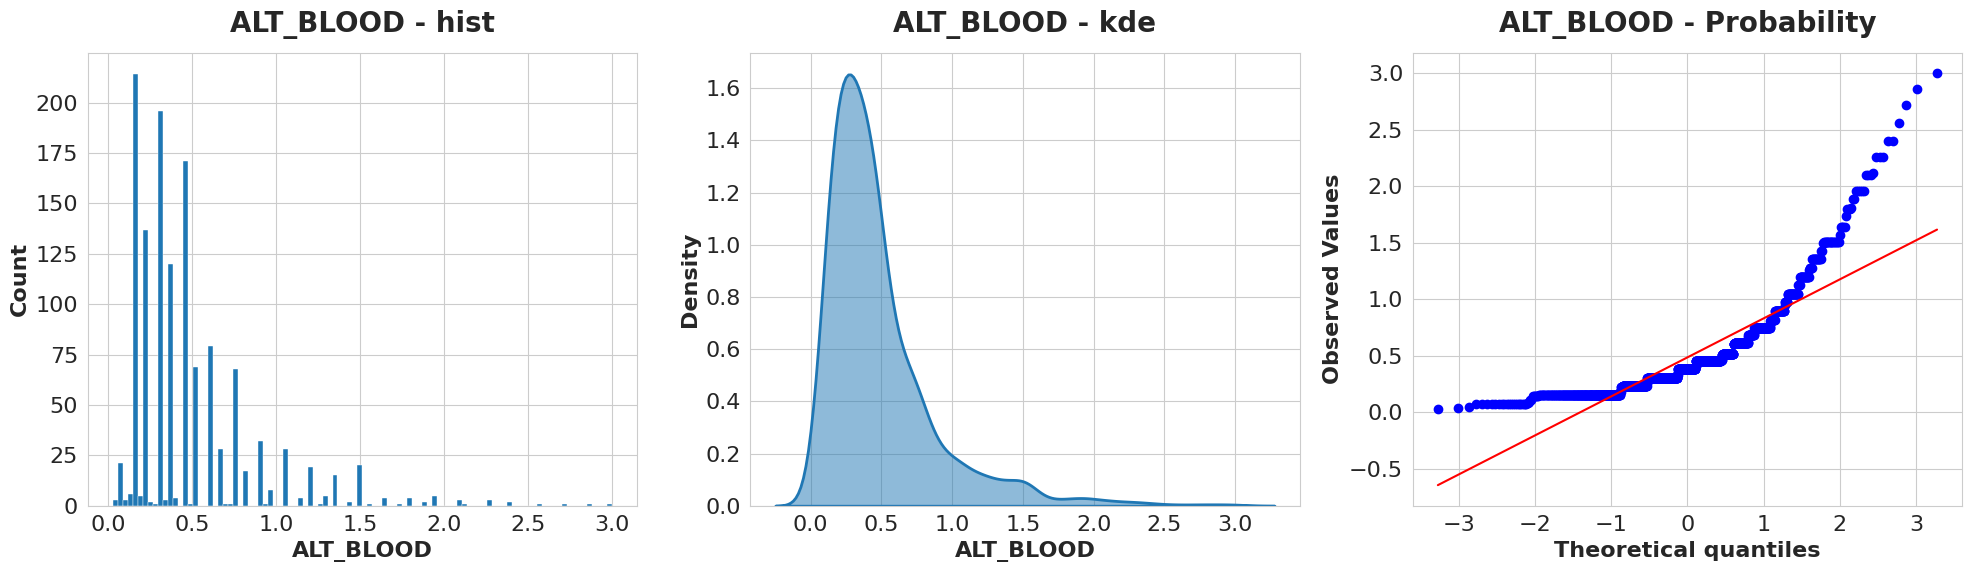

[SAVED] /home/leonardosaccotelli/Desktop/UNIVERSITA/MACHINE-LEARNING/Cost-Sensitive-Learning-For-Myocardial-Infarction-Mortality-Prediction/reports/figures/DP_data_exploration_cleaned/hist_kde_qqplot_AST_BLOOD.png


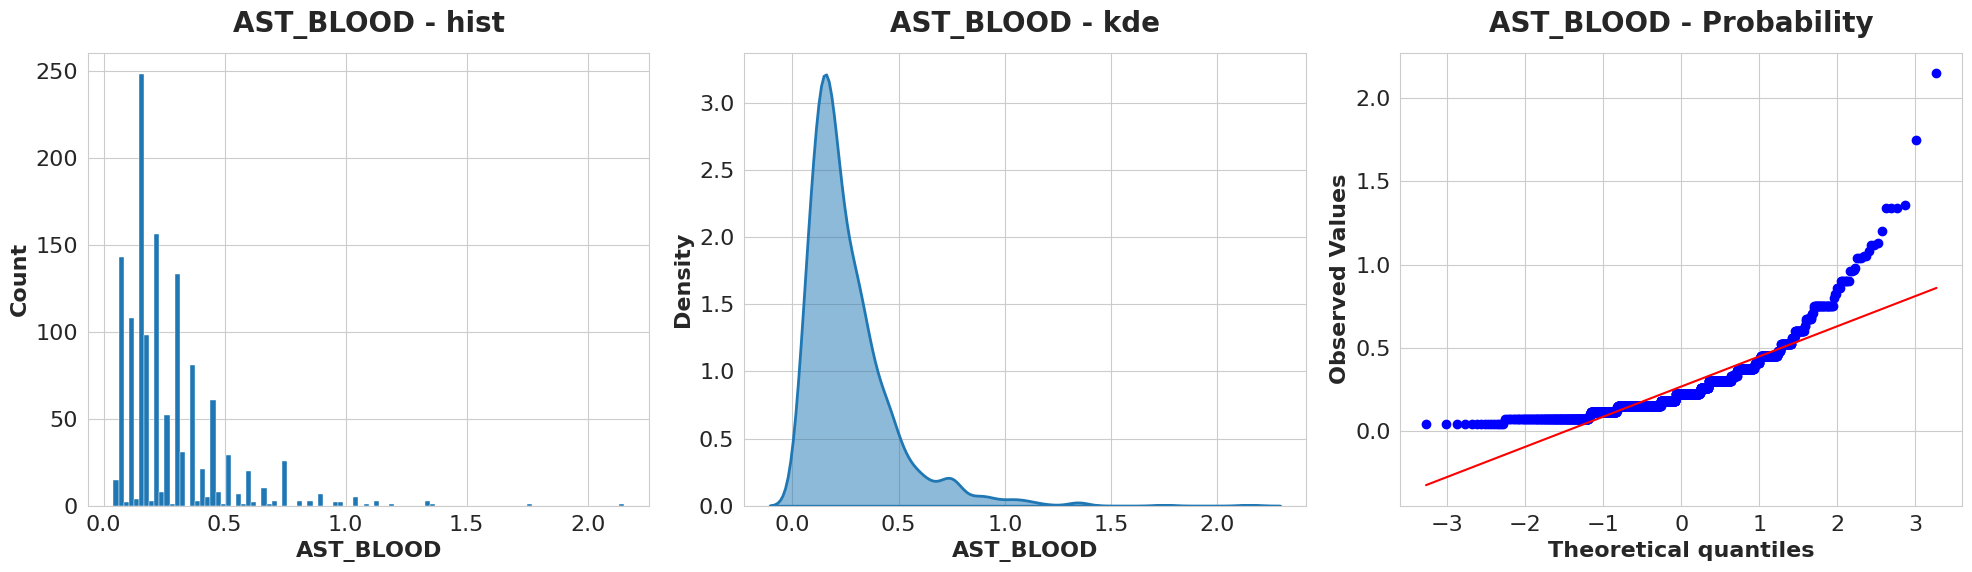

[SAVED] /home/leonardosaccotelli/Desktop/UNIVERSITA/MACHINE-LEARNING/Cost-Sensitive-Learning-For-Myocardial-Infarction-Mortality-Prediction/reports/figures/DP_data_exploration_cleaned/hist_kde_qqplot_L_BLOOD.png


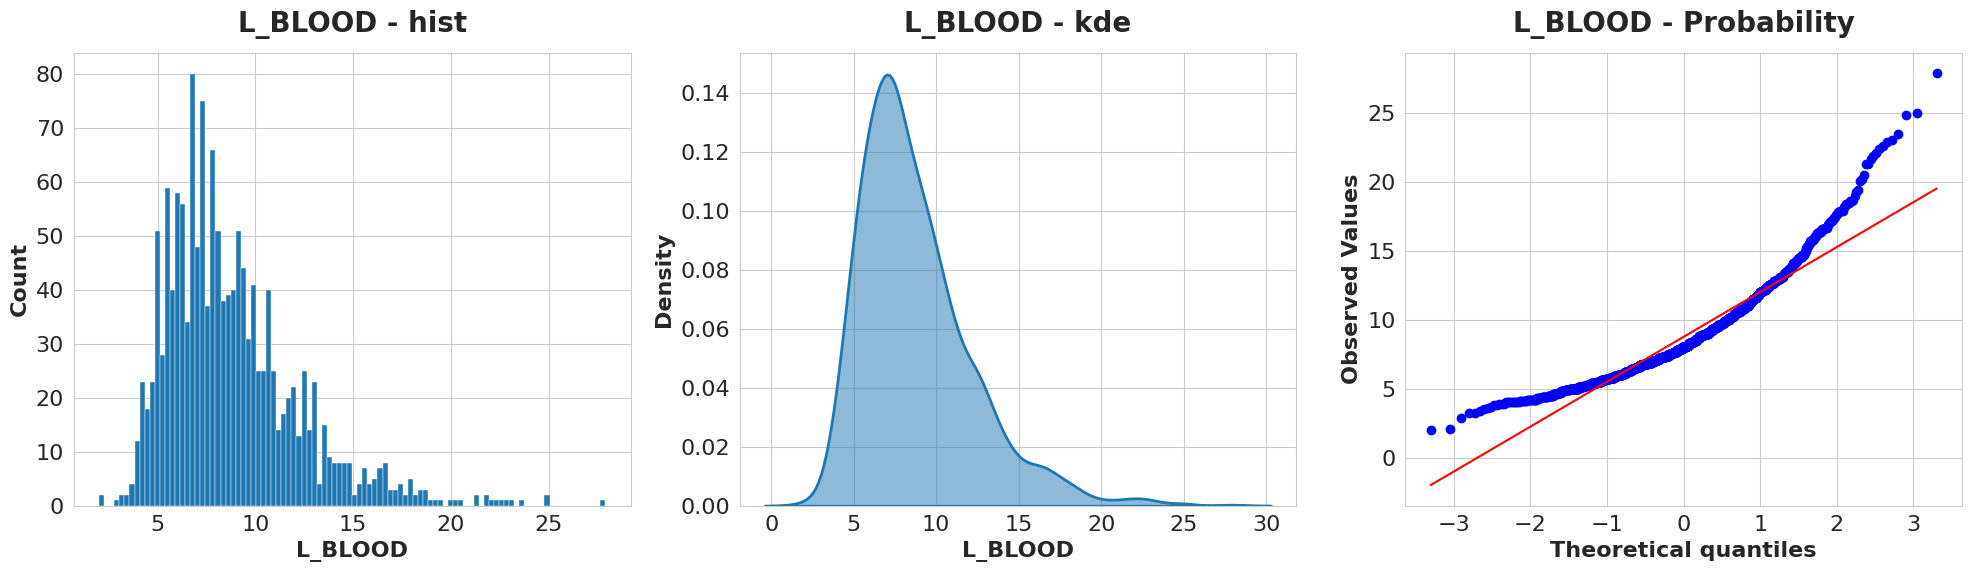

[SAVED] /home/leonardosaccotelli/Desktop/UNIVERSITA/MACHINE-LEARNING/Cost-Sensitive-Learning-For-Myocardial-Infarction-Mortality-Prediction/reports/figures/DP_data_exploration_cleaned/hist_kde_qqplot_ROE.png


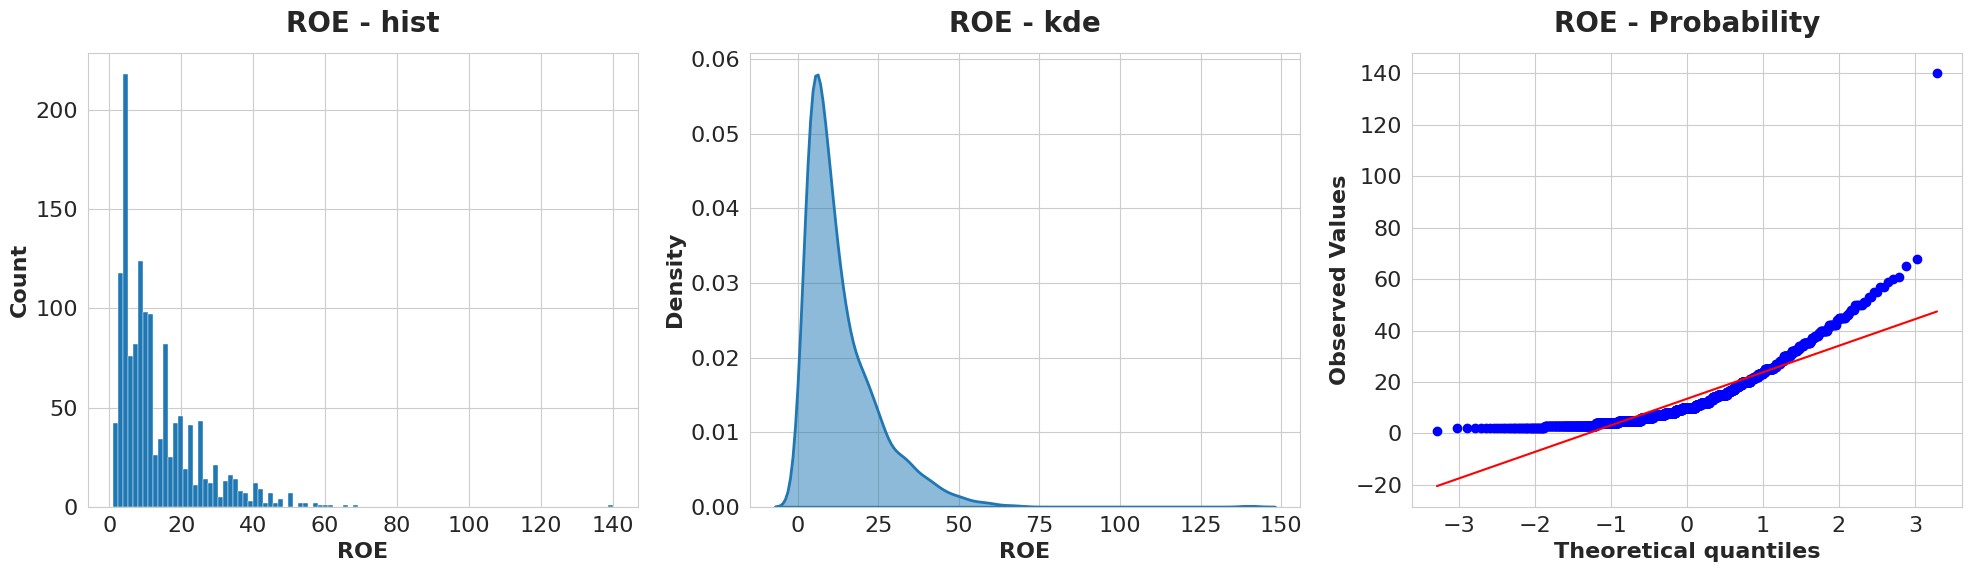

In [49]:
for num_variable in cols_float:
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))

    sns.histplot(ax=axes[0],
                 data=df,
                 x=num_variable,
                 bins=100,
                 stat="count",
                 kde=False,
                 color=sns.color_palette()[0],
                 alpha=1.0,
                 fill=True,)
    axes[0].set_xlabel(num_variable, fontweight="bold", fontsize=16)
    axes[0].set_ylabel("Count", fontweight="bold", fontsize=16)
    axes[0].set_title(f"{num_variable} - hist", fontsize=20, fontweight="bold", pad=15)

    sns.kdeplot(ax=axes[1],
                data=df,
                x=num_variable,
                fill=True,
                common_norm=False,
                alpha=0.5,
                linewidth=2.0,)
    axes[1].set_xlabel(num_variable, fontweight="bold", fontsize=16)
    axes[1].set_ylabel("Density", fontweight="bold", fontsize=16)
    axes[1].set_title(f"{num_variable} - kde", fontsize=20, fontweight="bold", pad=15)

    stats.probplot(plot=axes[2],
                   x=df[num_variable].replace([np.inf, -np.inf], np.nan).dropna().to_numpy(),
                   dist="norm",)
    axes[2].set_xlabel("Theoretical quantiles", fontweight="bold", fontsize=16)
    axes[2].set_ylabel("Observed Values", fontweight="bold", fontsize=16)
    axes[2].set_title(f"{num_variable} - Probability", fontsize=20, fontweight="bold", pad=15)

    # ------- General settings
    plt.tight_layout()

    int_features_hist_path: Path = FIGURES_DATA_EXPLORATION_DIR / f"hist_kde_qqplot_{num_variable}.png"
    plt.savefig(int_features_hist_path, dpi=300)
    print(f"[SAVED] {int_features_hist_path}")

    plt.show()

### Correlation Matrix of Quantitative Variables

[SAVED] /home/leonardosaccotelli/Desktop/UNIVERSITA/MACHINE-LEARNING/Cost-Sensitive-Learning-For-Myocardial-Infarction-Mortality-Prediction/reports/figures/DP_data_exploration_cleaned/correlation_matrix.png


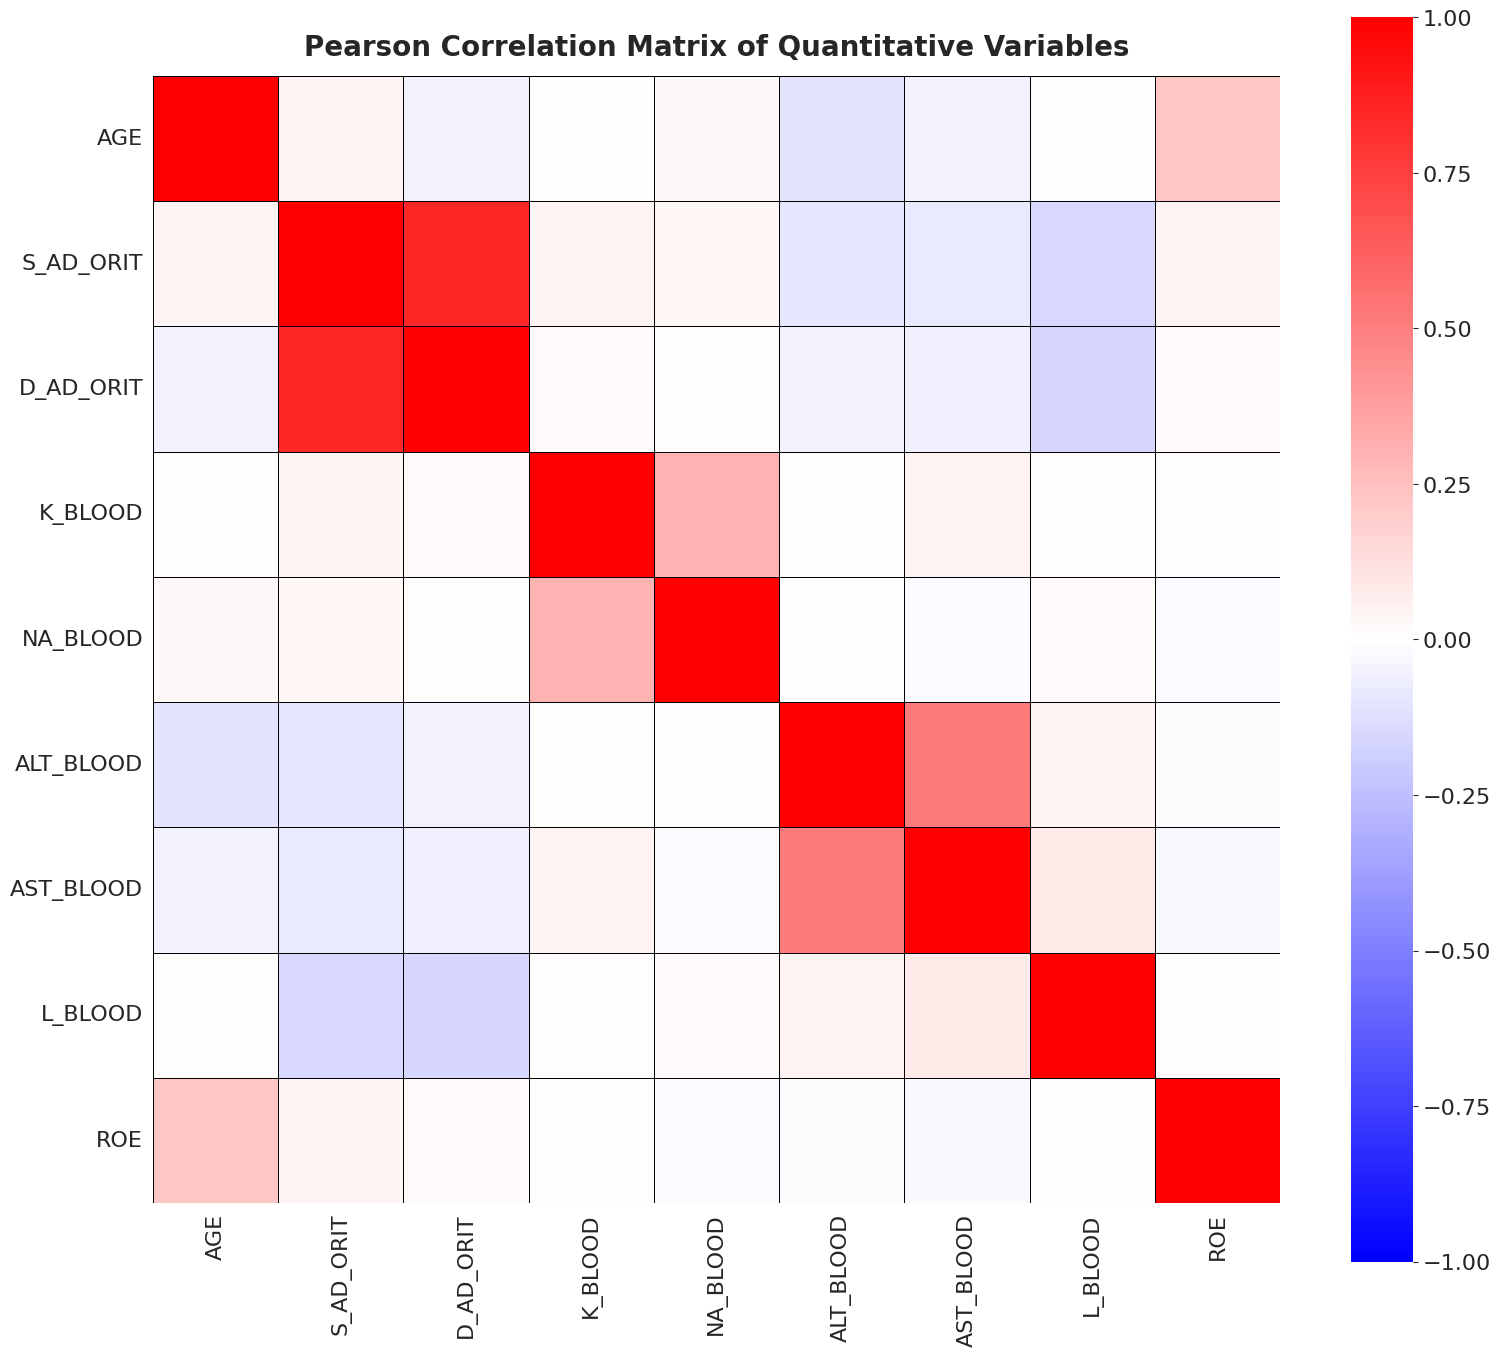

In [50]:
corr = df.loc[:, cols_int + cols_float].corr()

plt.figure(figsize=(16, 14))
sns.heatmap(
    data=corr,
    cmap="bwr",
    vmin=-1,
    vmax=1,
    center=0,
    square=True,
    annot=False,
    linecolor="k",
    linewidths=0.5,
)

plt.tick_params(labelsize=16)
plt.title("Pearson Correlation Matrix of Quantitative Variables",
          fontsize=20,
          fontweight="bold",
          pad=15)

# ------- General settings
plt.tight_layout()

int_float_corr_path: Path = FIGURES_DATA_EXPLORATION_DIR / "correlation_matrix.png"
plt.savefig(int_float_corr_path, dpi=300)
print(f"[SAVED] {int_float_corr_path}")

plt.show()

## Categorical Variables Analysis

In [51]:
all_categorical = CATEGORICAL_ORDINAL_FEATURES + CATEGORICAL_NOMINAL_FEATURES
cols_cat = [c for c in all_categorical if c in df.columns]
missing_cat = [c for c in all_categorical if c not in df.columns]
print(f"CAT present: {len(cols_cat)} | missing: {len(missing_cat)}")
if missing_cat:
    print("Missing CAT columns:", missing_cat)

CAT present: 87 | missing: 37
Missing CAT columns: ['R_AB_1_n', 'R_AB_2_n', 'R_AB_3_n', 'NA_R_1_n', 'NA_R_2_n', 'NA_R_3_n', 'NOT_NA_1_n', 'NOT_NA_2_n', 'NOT_NA_3_n', 'IBS_NASL', 'NA_KB', 'NOT_NA_KB', 'LID_KB', 'FIBR_PREDS', 'PREDS_TAH', 'JELUD_TAH', 'FIBR_JELUD', 'A_V_BLOK', 'OTEK_LANC', 'RAZRIV', 'DRESSLER', 'ZSN', 'REC_IM', 'P_IM_STEN', 'FIBR_PREDS', 'PREDS_TAH', 'JELUD_TAH', 'FIBR_JELUD', 'A_V_BLOK', 'OTEK_LANC', 'RAZRIV', 'DRESSLER', 'ZSN', 'REC_IM', 'P_IM_STEN', 'LET_IS', 'CLASS']


[SAVED] /home/leonardosaccotelli/Desktop/UNIVERSITA/MACHINE-LEARNING/Cost-Sensitive-Learning-For-Myocardial-Infarction-Mortality-Prediction/reports/figures/DP_data_exploration_cleaned/class_distribution_absolute_vs_percentage_INF_ANAM.png


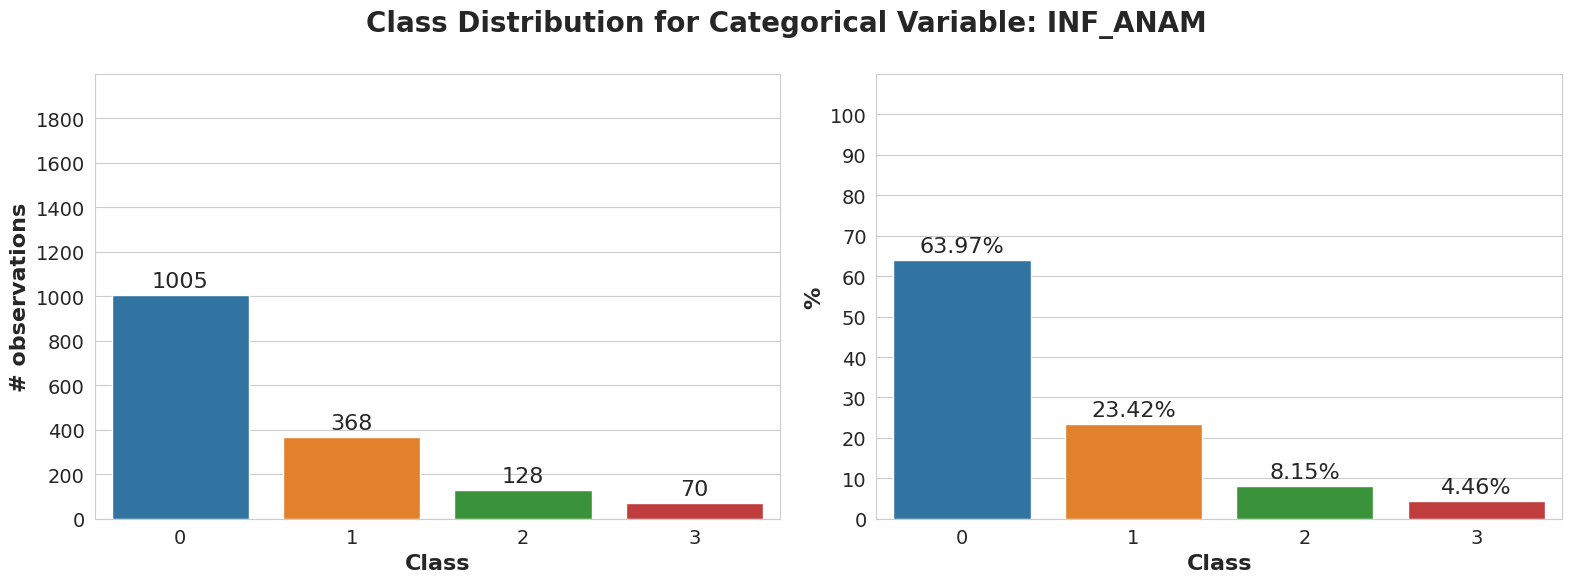

[SAVED] /home/leonardosaccotelli/Desktop/UNIVERSITA/MACHINE-LEARNING/Cost-Sensitive-Learning-For-Myocardial-Infarction-Mortality-Prediction/reports/figures/DP_data_exploration_cleaned/class_distribution_absolute_vs_percentage_STENOK_AN.png


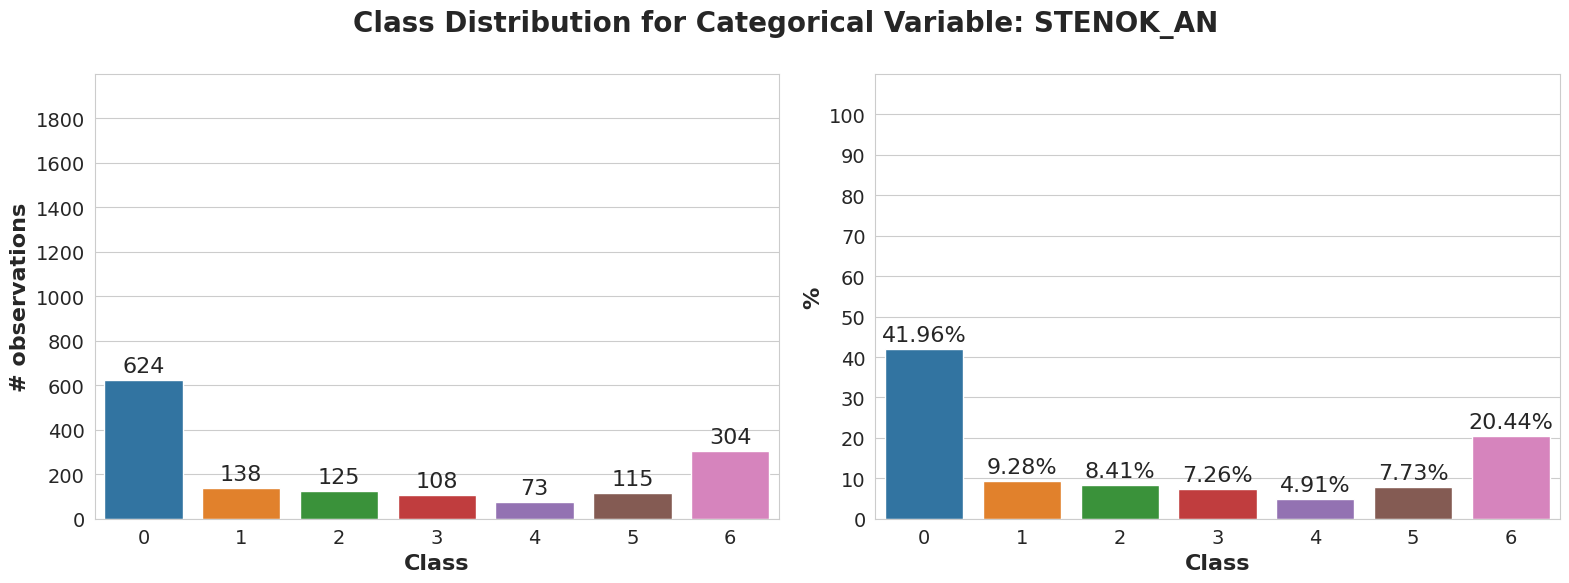

[SAVED] /home/leonardosaccotelli/Desktop/UNIVERSITA/MACHINE-LEARNING/Cost-Sensitive-Learning-For-Myocardial-Infarction-Mortality-Prediction/reports/figures/DP_data_exploration_cleaned/class_distribution_absolute_vs_percentage_FK_STENOK.png


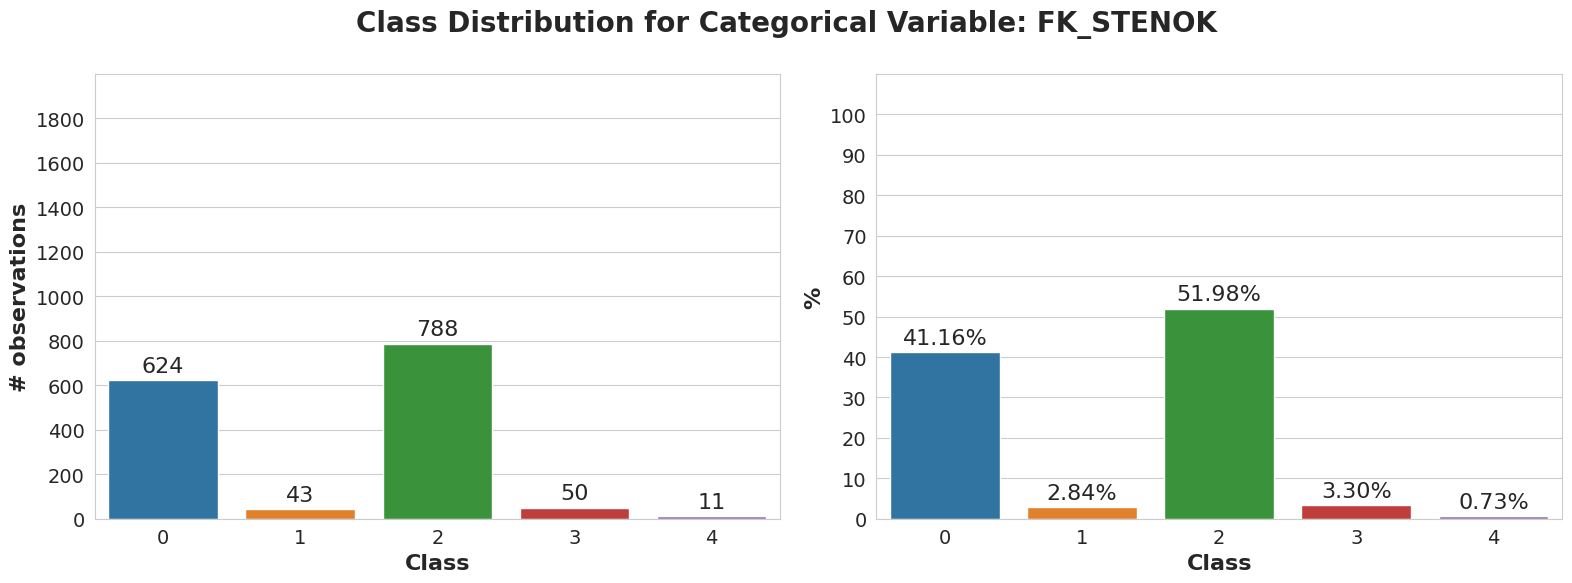

[SAVED] /home/leonardosaccotelli/Desktop/UNIVERSITA/MACHINE-LEARNING/Cost-Sensitive-Learning-For-Myocardial-Infarction-Mortality-Prediction/reports/figures/DP_data_exploration_cleaned/class_distribution_absolute_vs_percentage_GB.png


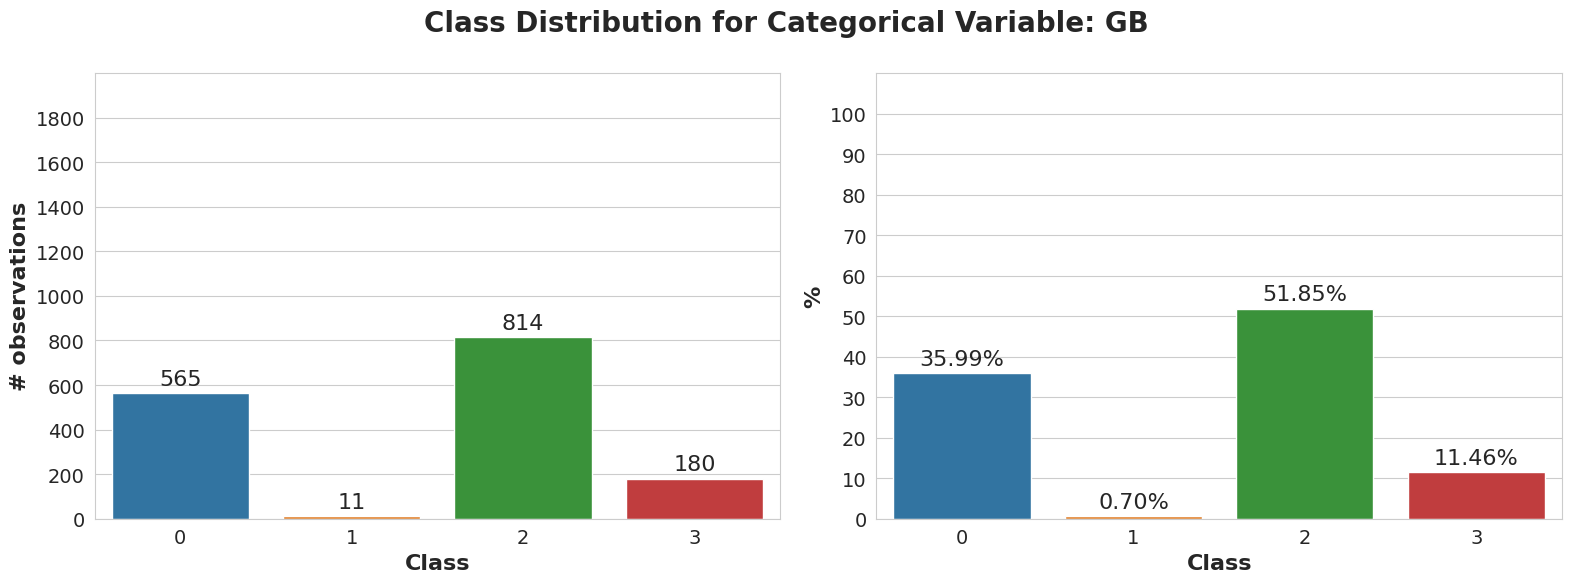

[SAVED] /home/leonardosaccotelli/Desktop/UNIVERSITA/MACHINE-LEARNING/Cost-Sensitive-Learning-For-Myocardial-Infarction-Mortality-Prediction/reports/figures/DP_data_exploration_cleaned/class_distribution_absolute_vs_percentage_DLIT_AG.png


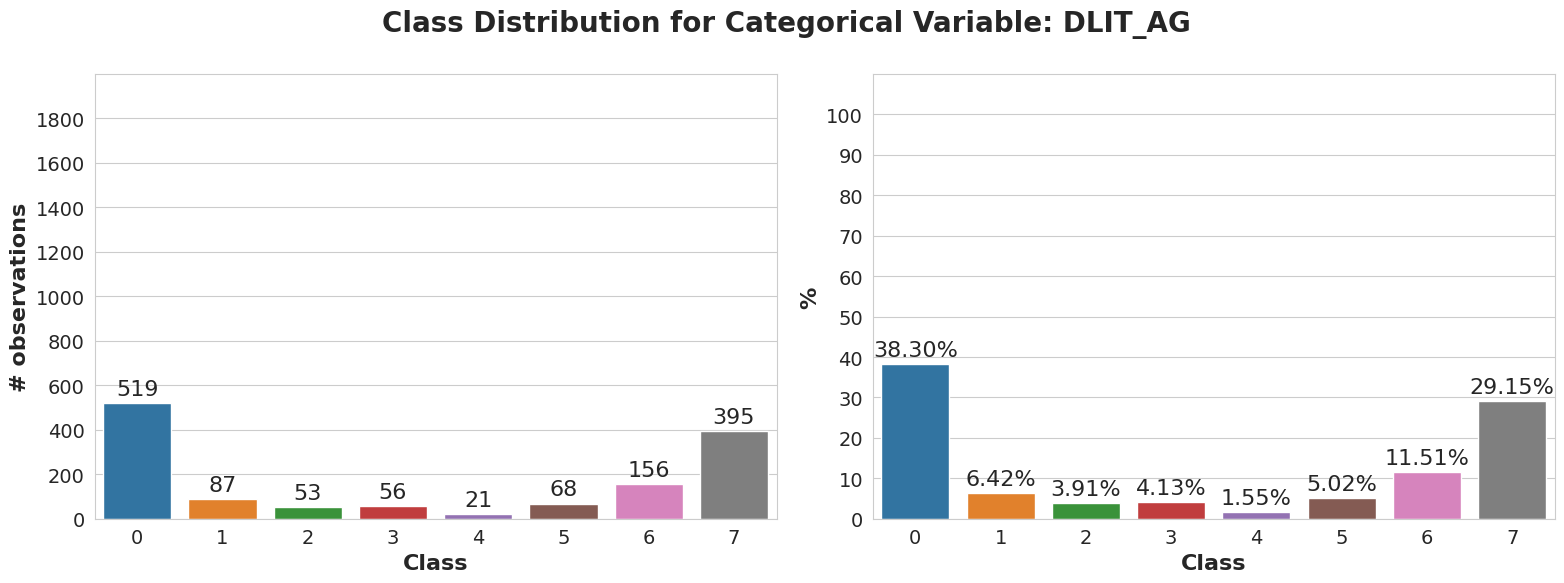

[SAVED] /home/leonardosaccotelli/Desktop/UNIVERSITA/MACHINE-LEARNING/Cost-Sensitive-Learning-For-Myocardial-Infarction-Mortality-Prediction/reports/figures/DP_data_exploration_cleaned/class_distribution_absolute_vs_percentage_ZSN_A.png


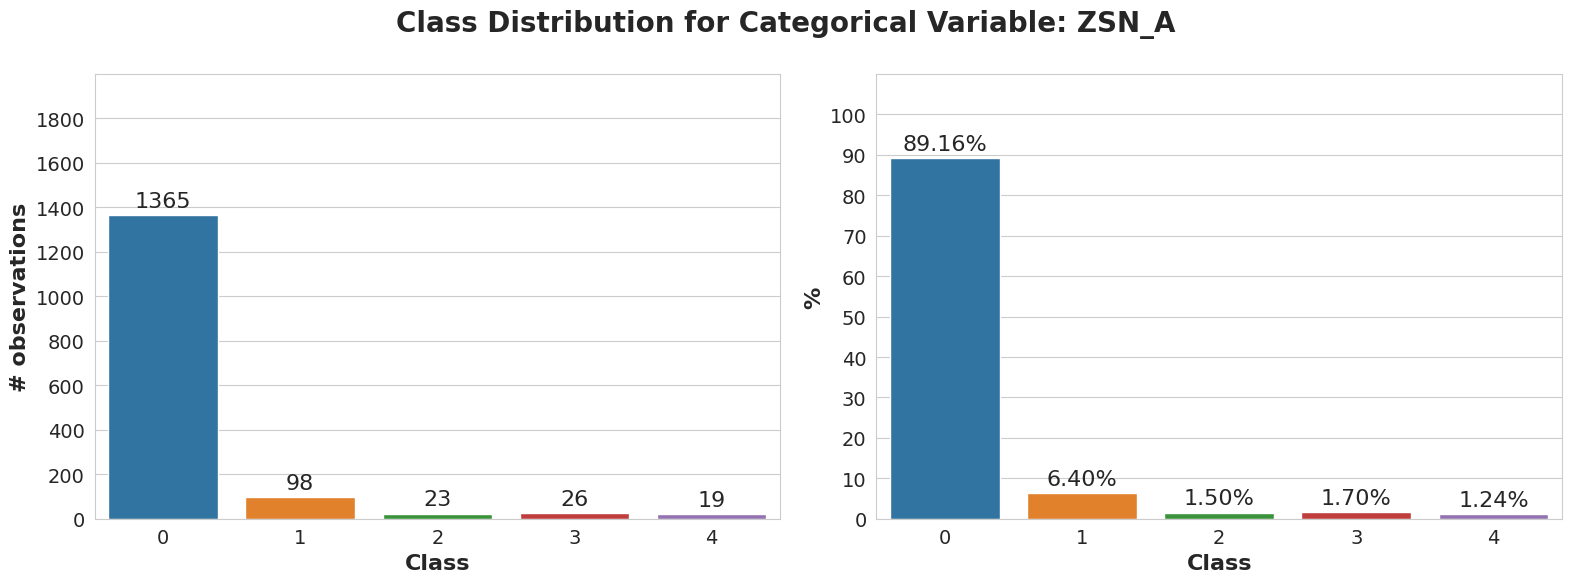

[SAVED] /home/leonardosaccotelli/Desktop/UNIVERSITA/MACHINE-LEARNING/Cost-Sensitive-Learning-For-Myocardial-Infarction-Mortality-Prediction/reports/figures/DP_data_exploration_cleaned/class_distribution_absolute_vs_percentage_TIME_B_S.png


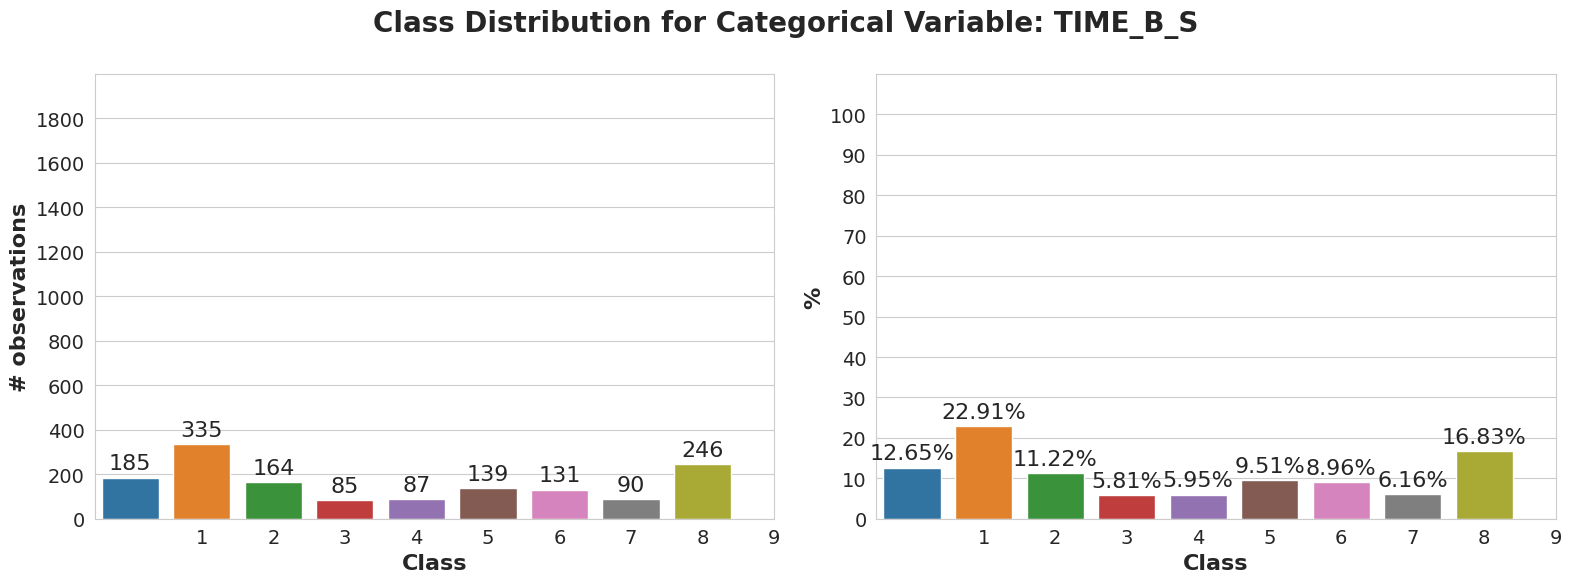

[SAVED] /home/leonardosaccotelli/Desktop/UNIVERSITA/MACHINE-LEARNING/Cost-Sensitive-Learning-For-Myocardial-Infarction-Mortality-Prediction/reports/figures/DP_data_exploration_cleaned/class_distribution_absolute_vs_percentage_ant_im.png


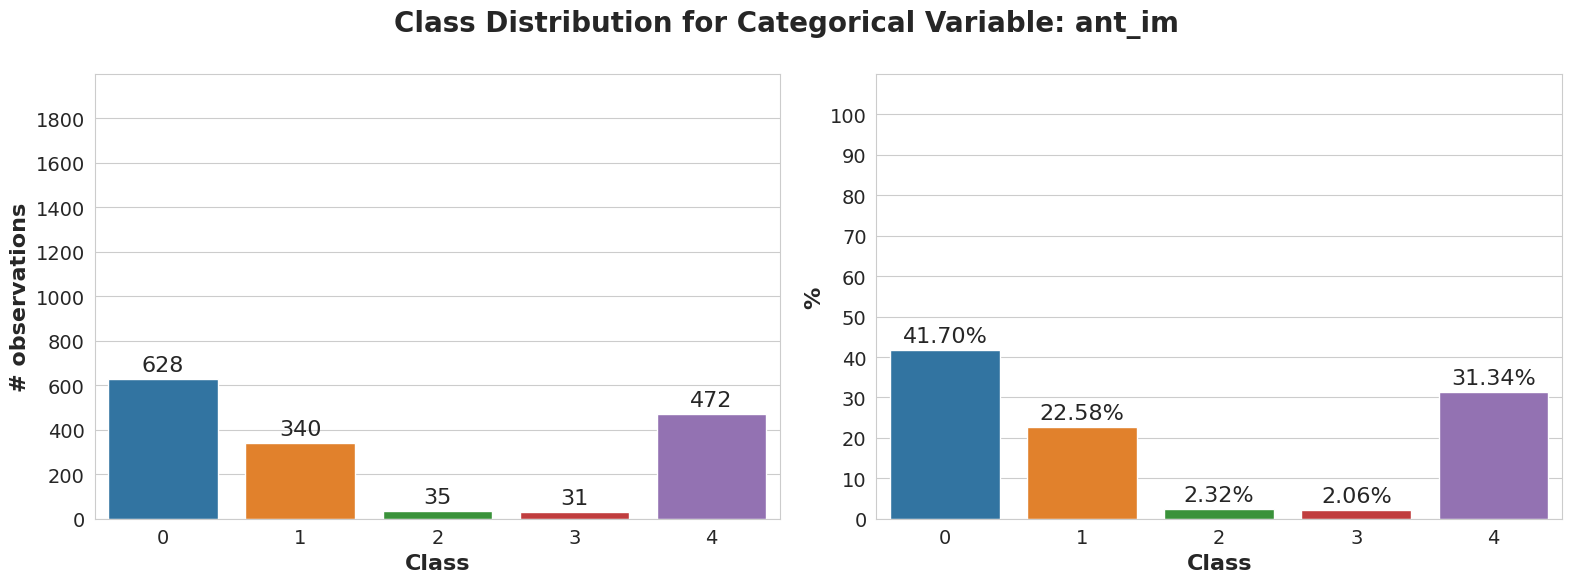

[SAVED] /home/leonardosaccotelli/Desktop/UNIVERSITA/MACHINE-LEARNING/Cost-Sensitive-Learning-For-Myocardial-Infarction-Mortality-Prediction/reports/figures/DP_data_exploration_cleaned/class_distribution_absolute_vs_percentage_lat_im.png


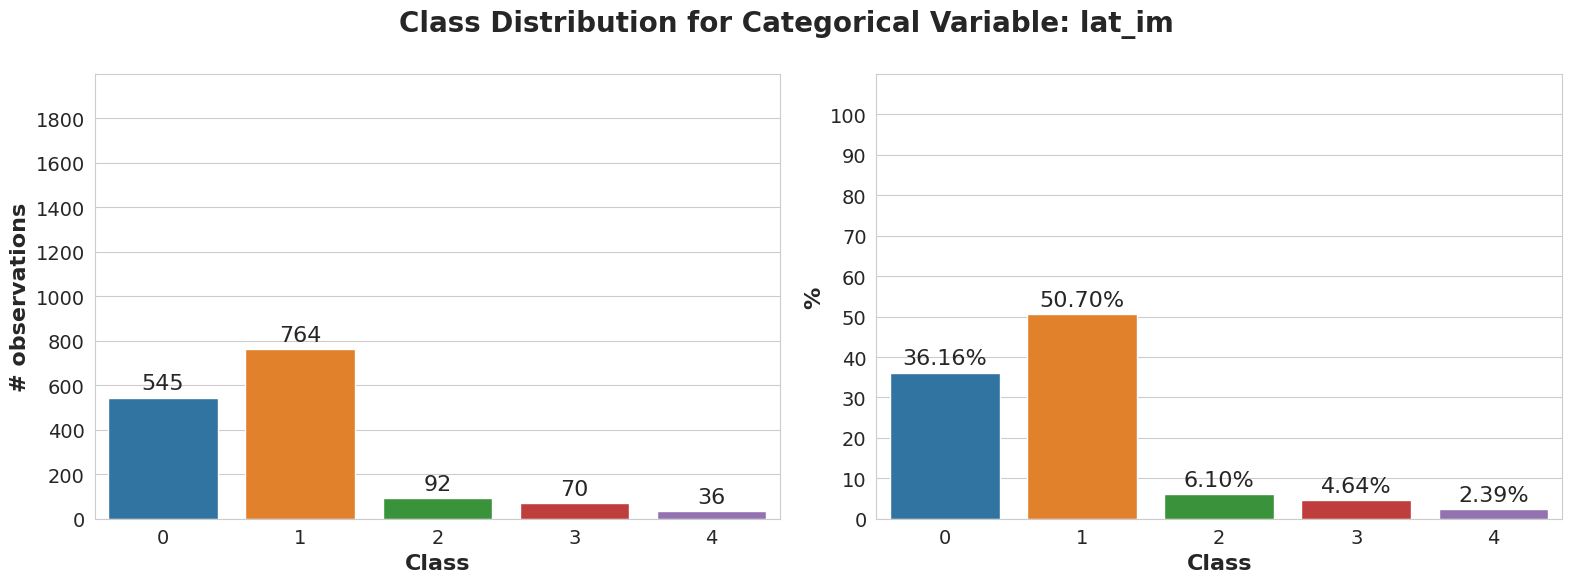

[SAVED] /home/leonardosaccotelli/Desktop/UNIVERSITA/MACHINE-LEARNING/Cost-Sensitive-Learning-For-Myocardial-Infarction-Mortality-Prediction/reports/figures/DP_data_exploration_cleaned/class_distribution_absolute_vs_percentage_inf_im.png


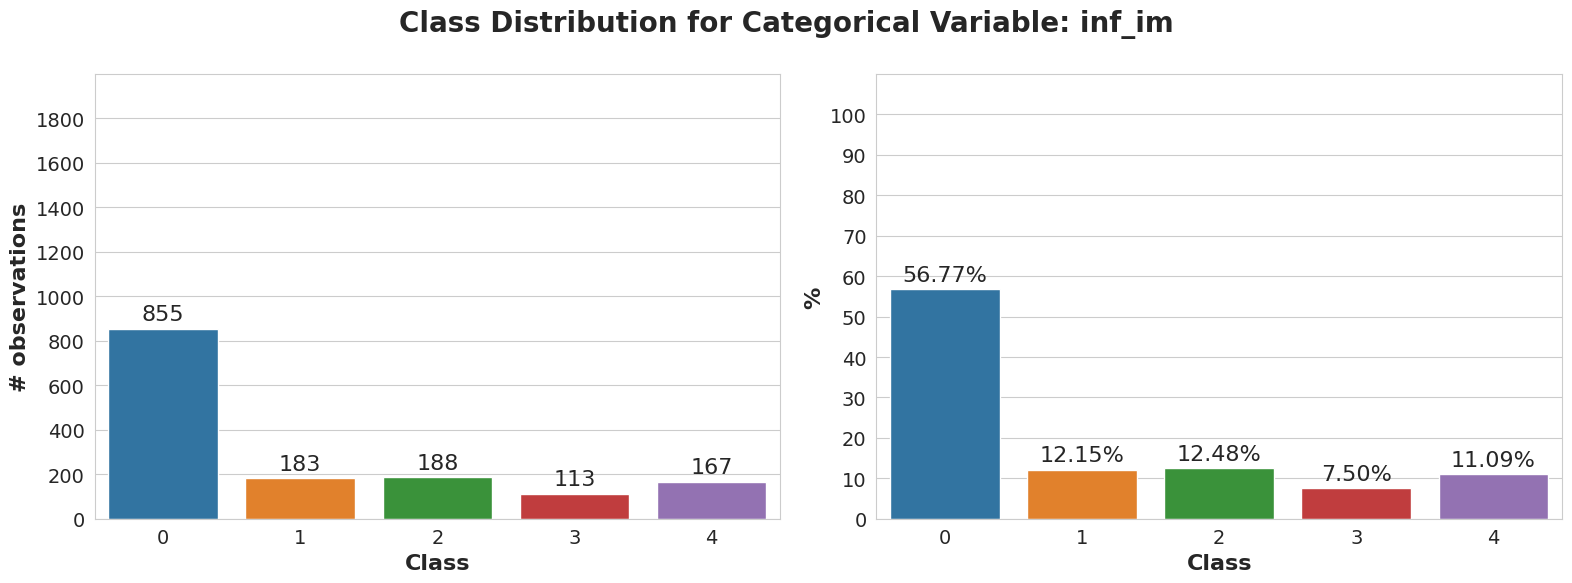

[SAVED] /home/leonardosaccotelli/Desktop/UNIVERSITA/MACHINE-LEARNING/Cost-Sensitive-Learning-For-Myocardial-Infarction-Mortality-Prediction/reports/figures/DP_data_exploration_cleaned/class_distribution_absolute_vs_percentage_post_im.png


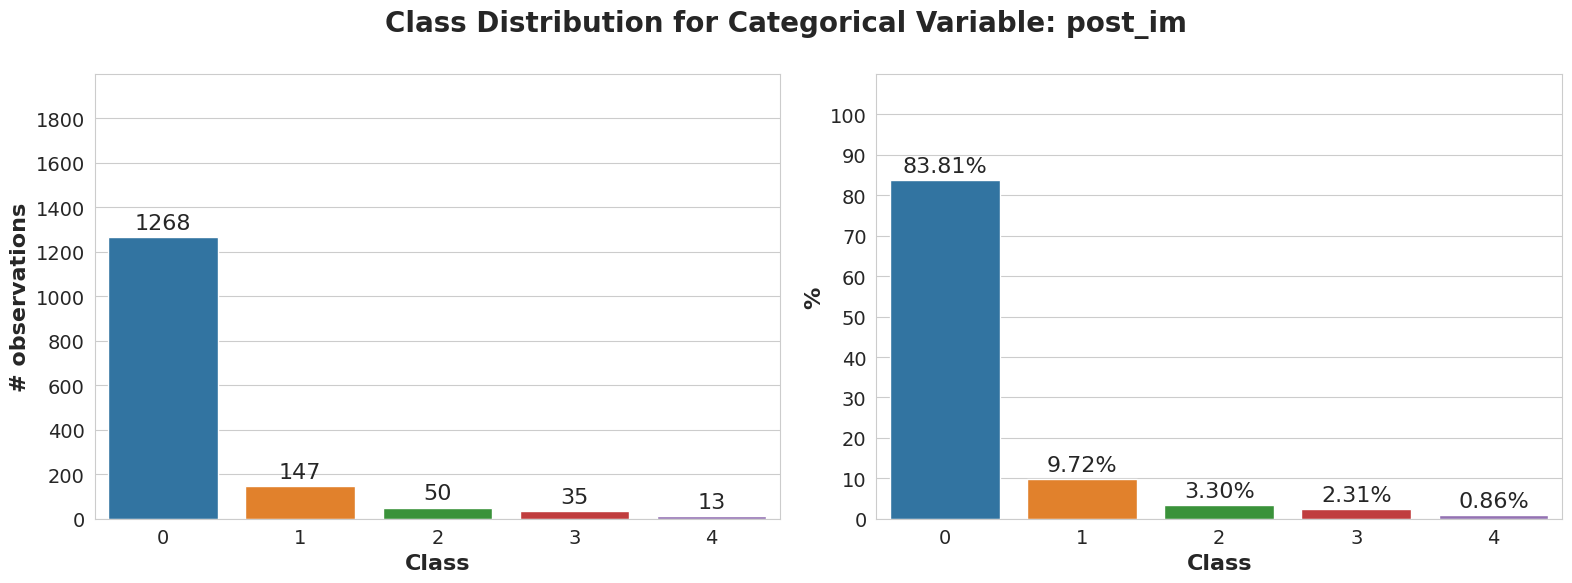

[SAVED] /home/leonardosaccotelli/Desktop/UNIVERSITA/MACHINE-LEARNING/Cost-Sensitive-Learning-For-Myocardial-Infarction-Mortality-Prediction/reports/figures/DP_data_exploration_cleaned/class_distribution_absolute_vs_percentage_SEX.png


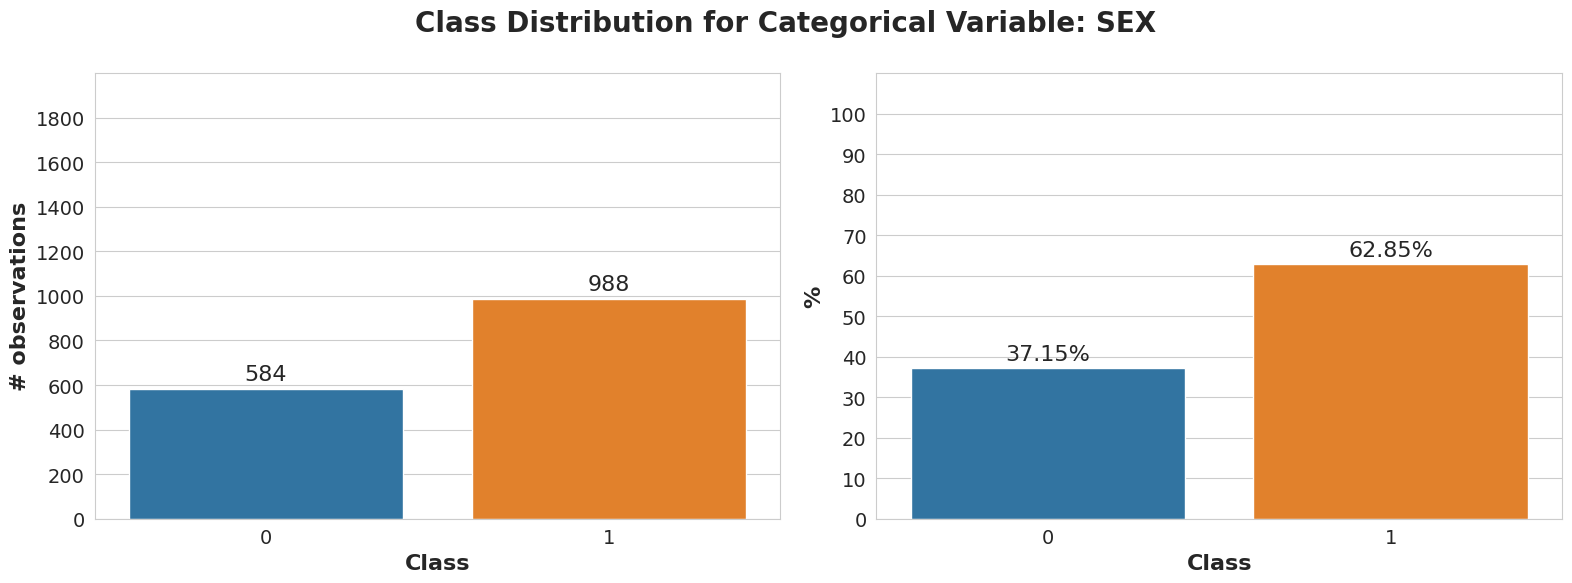

[SAVED] /home/leonardosaccotelli/Desktop/UNIVERSITA/MACHINE-LEARNING/Cost-Sensitive-Learning-For-Myocardial-Infarction-Mortality-Prediction/reports/figures/DP_data_exploration_cleaned/class_distribution_absolute_vs_percentage_SIM_GIPERT.png


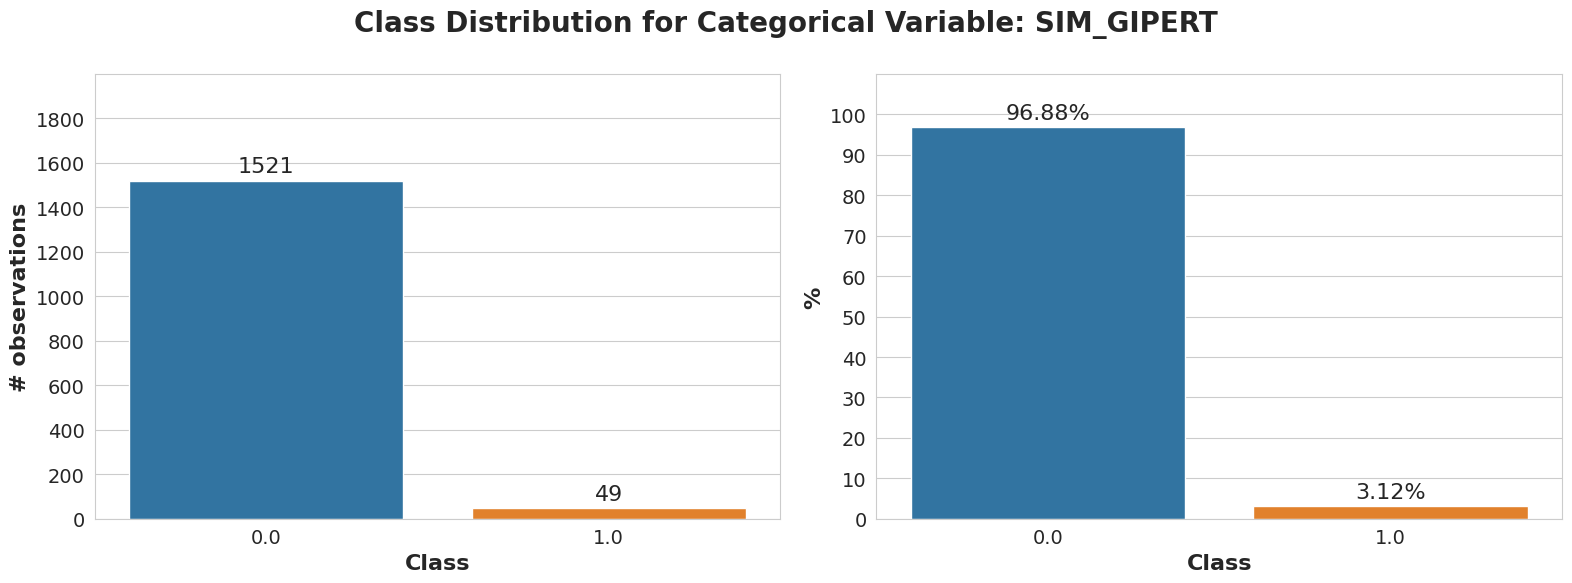

[SAVED] /home/leonardosaccotelli/Desktop/UNIVERSITA/MACHINE-LEARNING/Cost-Sensitive-Learning-For-Myocardial-Infarction-Mortality-Prediction/reports/figures/DP_data_exploration_cleaned/class_distribution_absolute_vs_percentage_nr_11.png


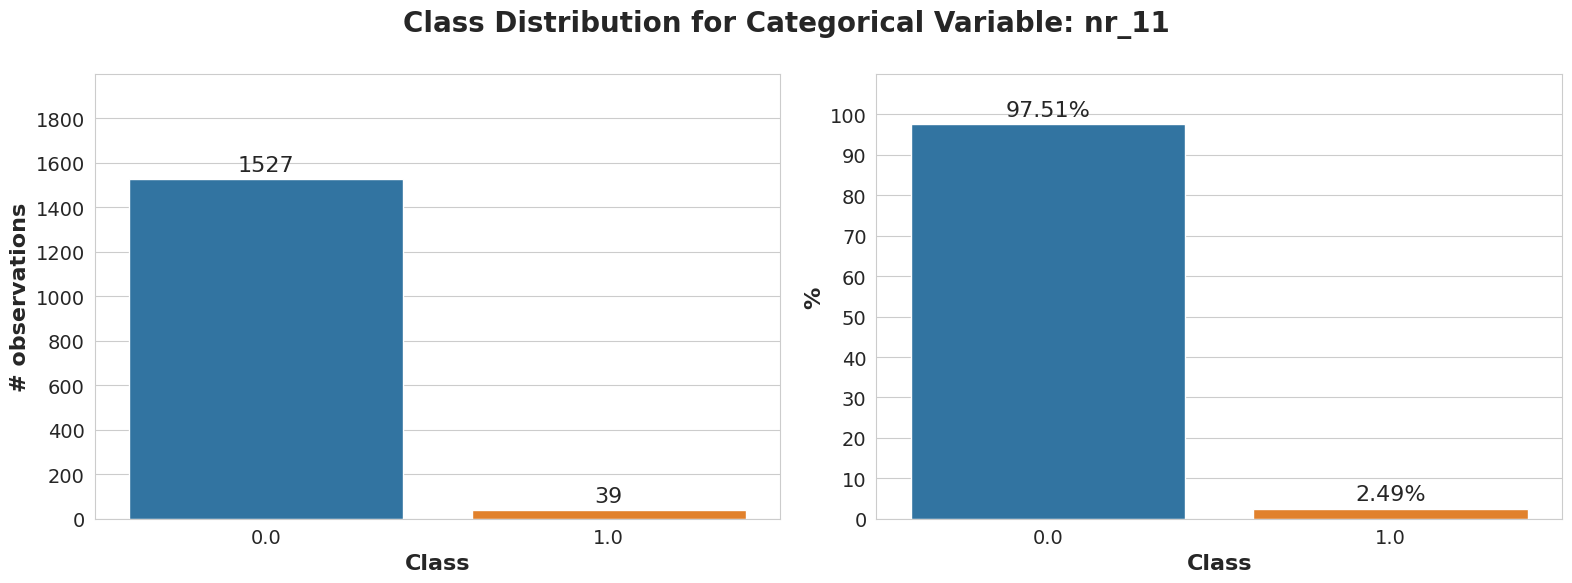

[SAVED] /home/leonardosaccotelli/Desktop/UNIVERSITA/MACHINE-LEARNING/Cost-Sensitive-Learning-For-Myocardial-Infarction-Mortality-Prediction/reports/figures/DP_data_exploration_cleaned/class_distribution_absolute_vs_percentage_nr_01.png


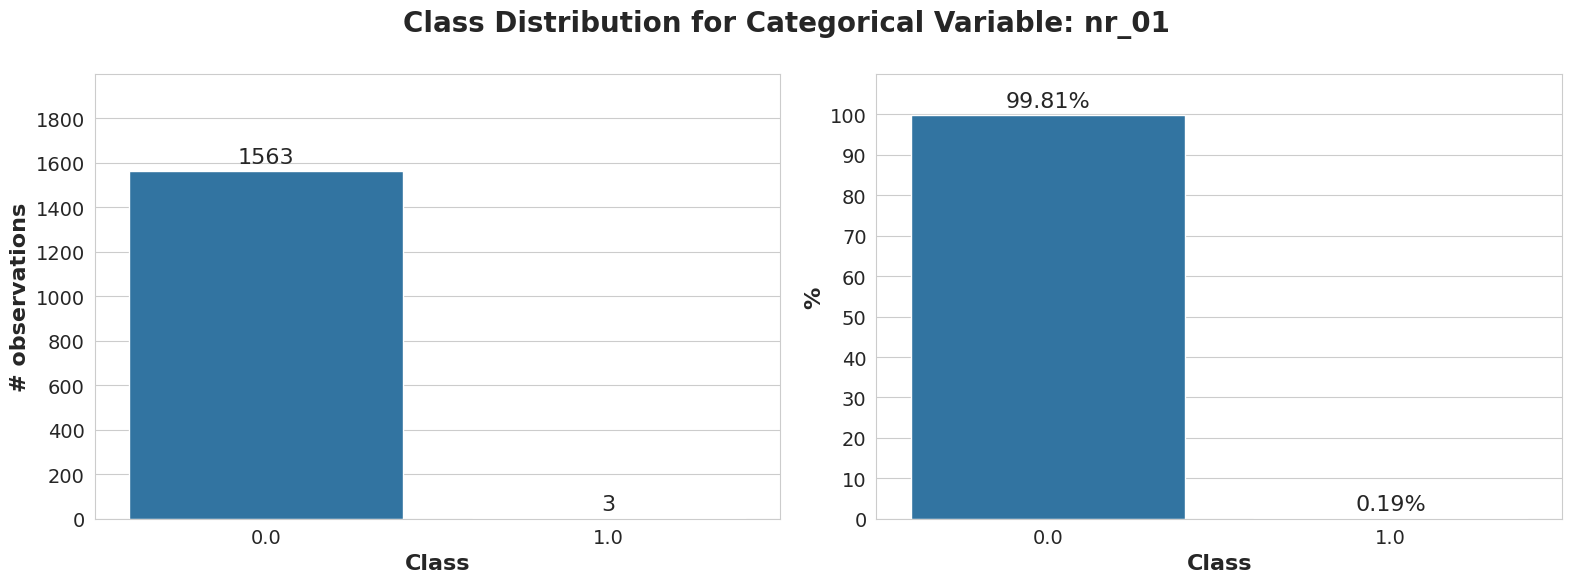

[SAVED] /home/leonardosaccotelli/Desktop/UNIVERSITA/MACHINE-LEARNING/Cost-Sensitive-Learning-For-Myocardial-Infarction-Mortality-Prediction/reports/figures/DP_data_exploration_cleaned/class_distribution_absolute_vs_percentage_nr_02.png


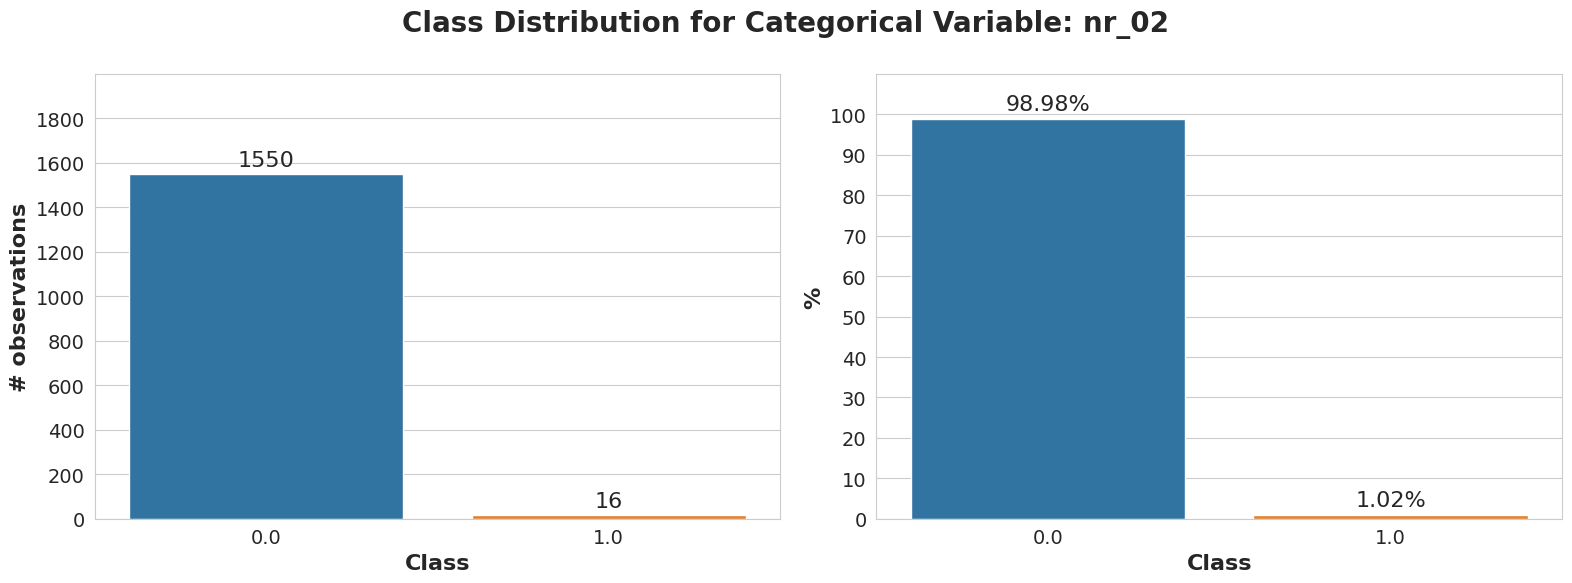

[SAVED] /home/leonardosaccotelli/Desktop/UNIVERSITA/MACHINE-LEARNING/Cost-Sensitive-Learning-For-Myocardial-Infarction-Mortality-Prediction/reports/figures/DP_data_exploration_cleaned/class_distribution_absolute_vs_percentage_nr_03.png


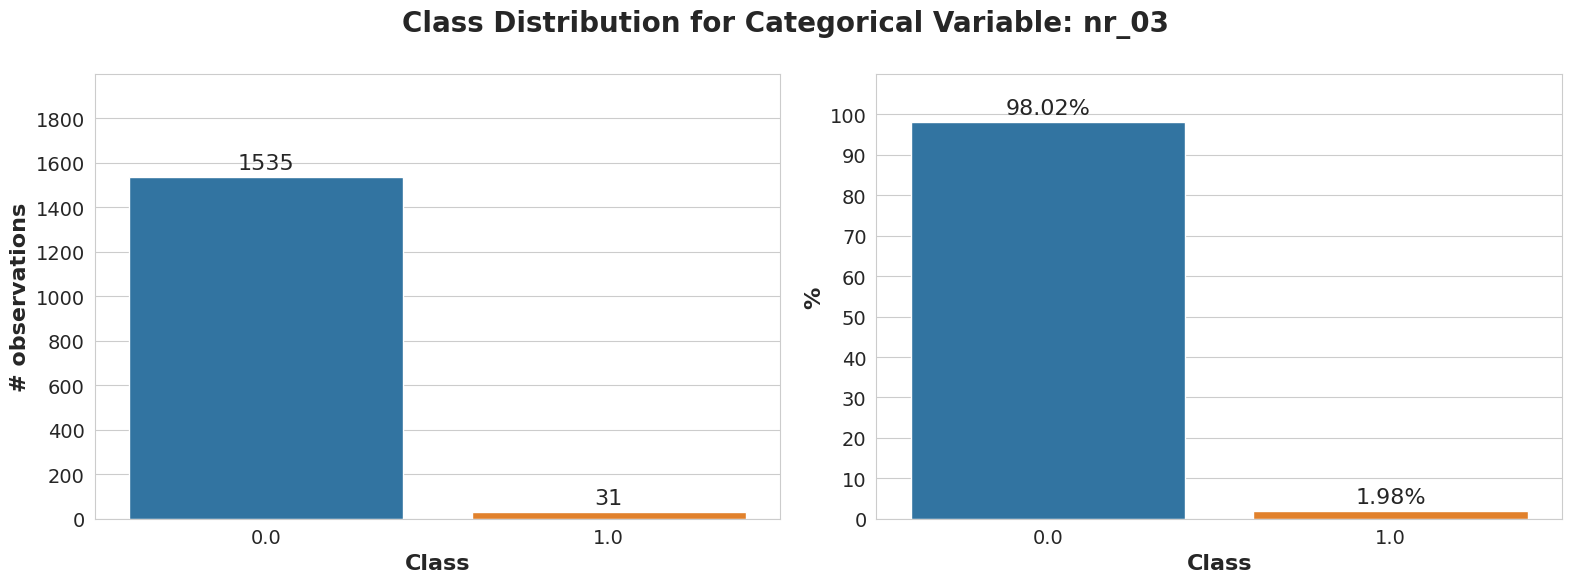

[SAVED] /home/leonardosaccotelli/Desktop/UNIVERSITA/MACHINE-LEARNING/Cost-Sensitive-Learning-For-Myocardial-Infarction-Mortality-Prediction/reports/figures/DP_data_exploration_cleaned/class_distribution_absolute_vs_percentage_nr_04.png


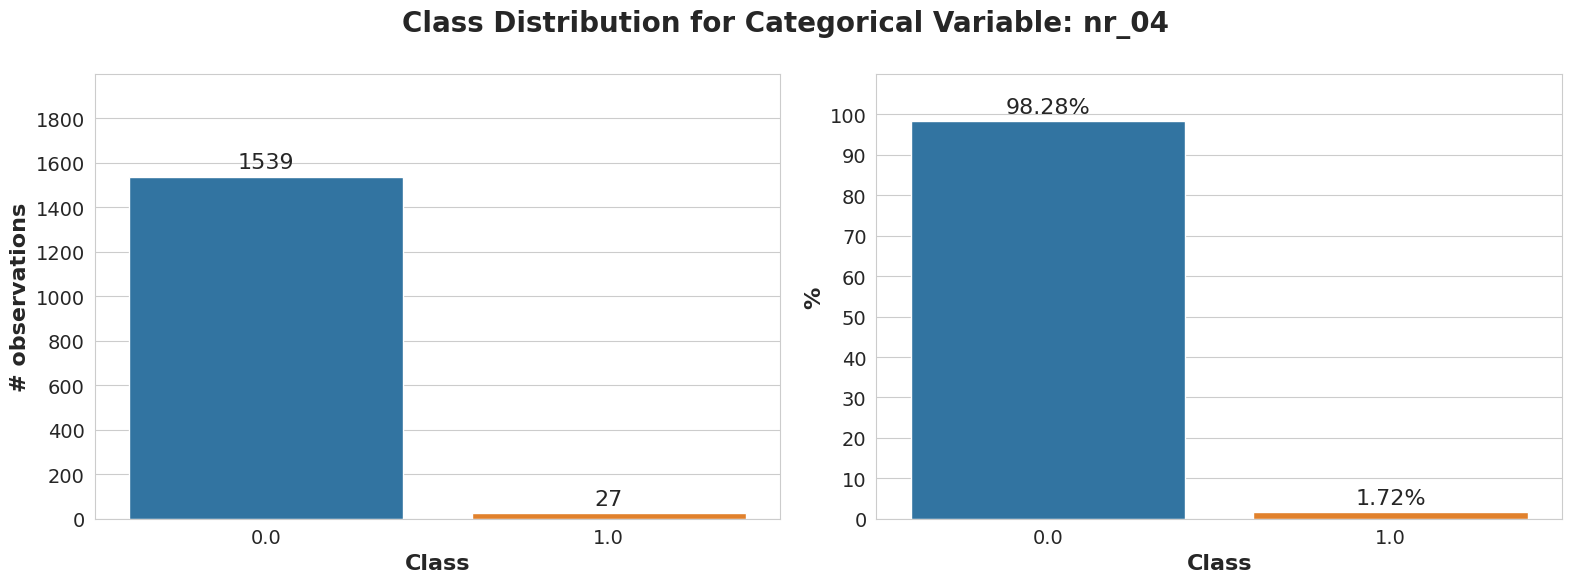

[SAVED] /home/leonardosaccotelli/Desktop/UNIVERSITA/MACHINE-LEARNING/Cost-Sensitive-Learning-For-Myocardial-Infarction-Mortality-Prediction/reports/figures/DP_data_exploration_cleaned/class_distribution_absolute_vs_percentage_nr_07.png


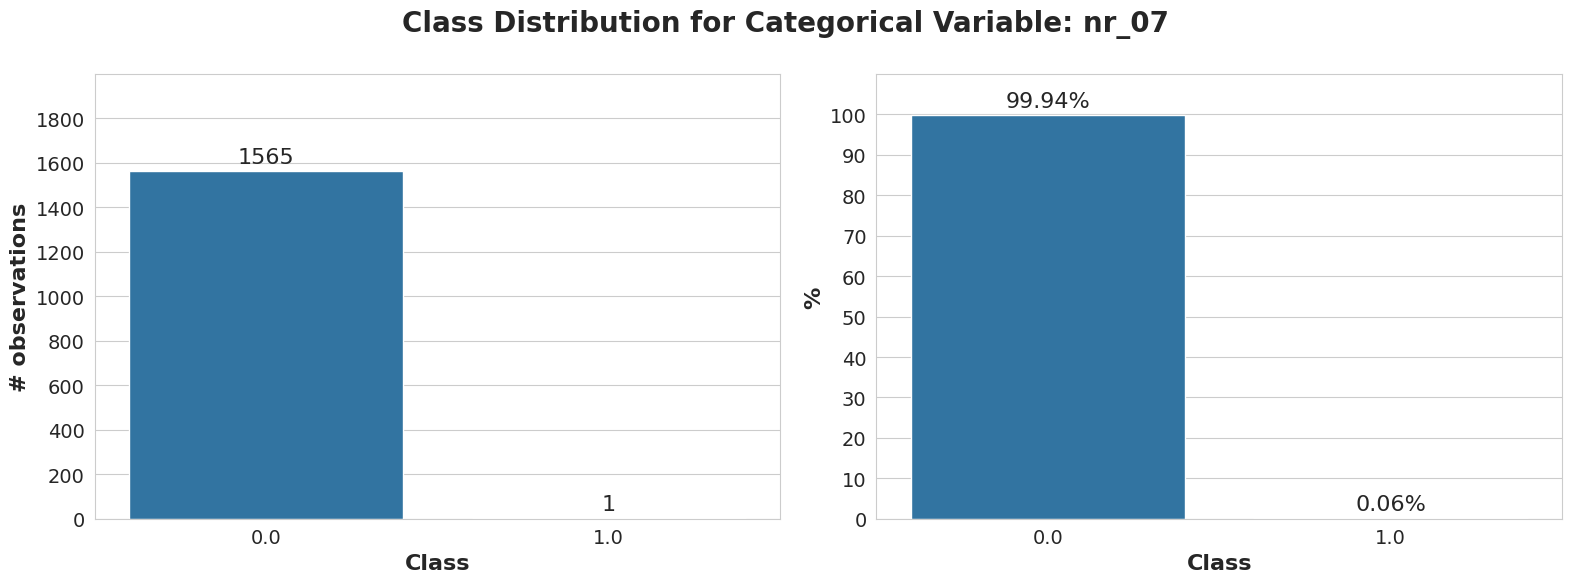

[SAVED] /home/leonardosaccotelli/Desktop/UNIVERSITA/MACHINE-LEARNING/Cost-Sensitive-Learning-For-Myocardial-Infarction-Mortality-Prediction/reports/figures/DP_data_exploration_cleaned/class_distribution_absolute_vs_percentage_nr_08.png


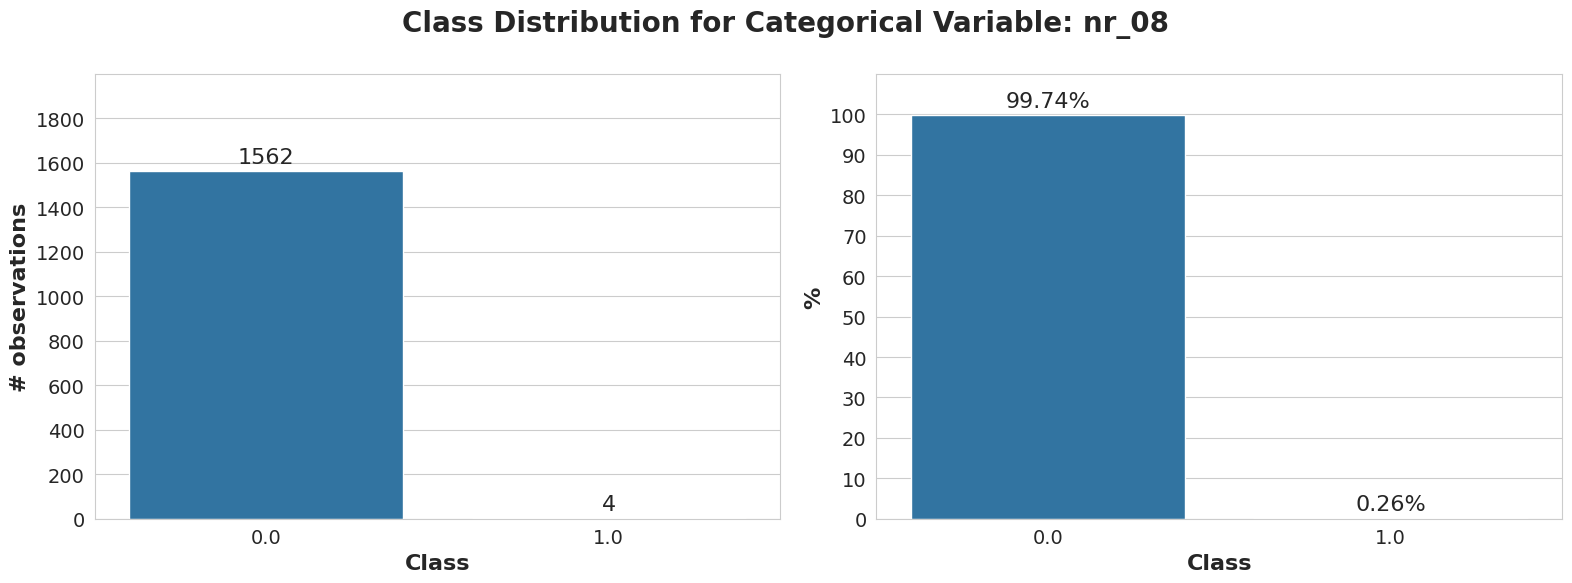

[SAVED] /home/leonardosaccotelli/Desktop/UNIVERSITA/MACHINE-LEARNING/Cost-Sensitive-Learning-For-Myocardial-Infarction-Mortality-Prediction/reports/figures/DP_data_exploration_cleaned/class_distribution_absolute_vs_percentage_np_01.png


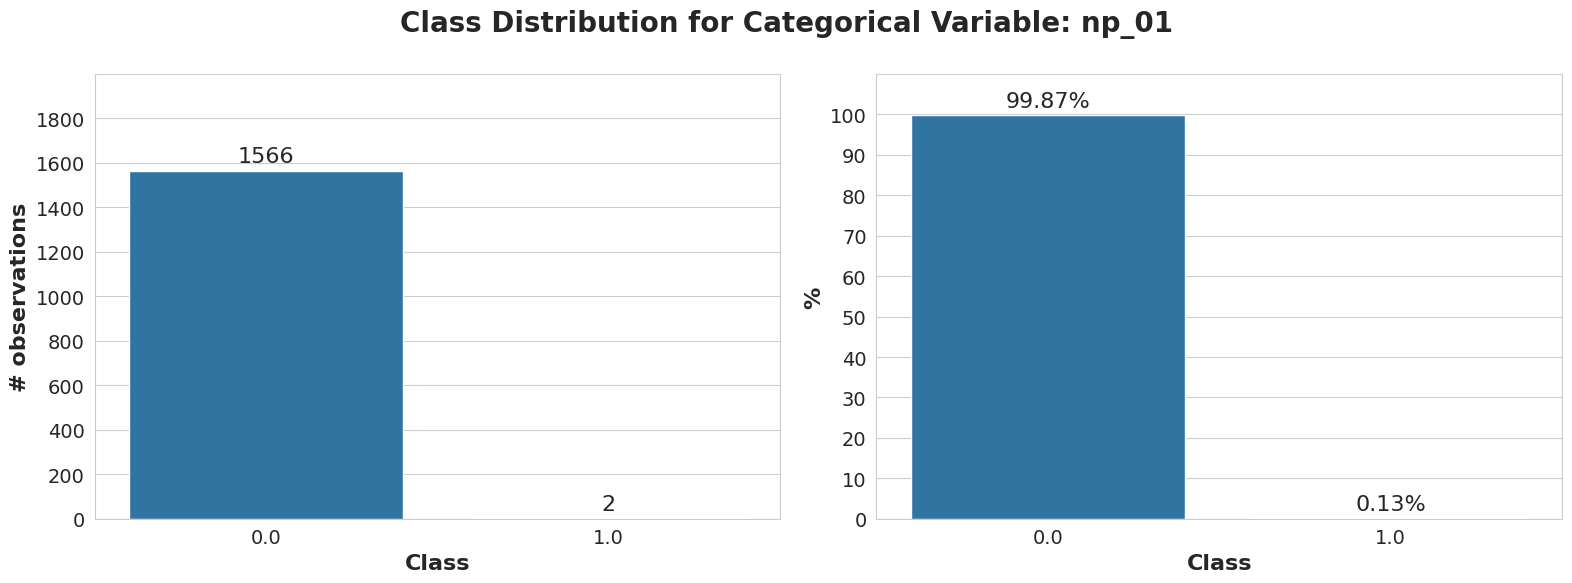

[SAVED] /home/leonardosaccotelli/Desktop/UNIVERSITA/MACHINE-LEARNING/Cost-Sensitive-Learning-For-Myocardial-Infarction-Mortality-Prediction/reports/figures/DP_data_exploration_cleaned/class_distribution_absolute_vs_percentage_np_04.png


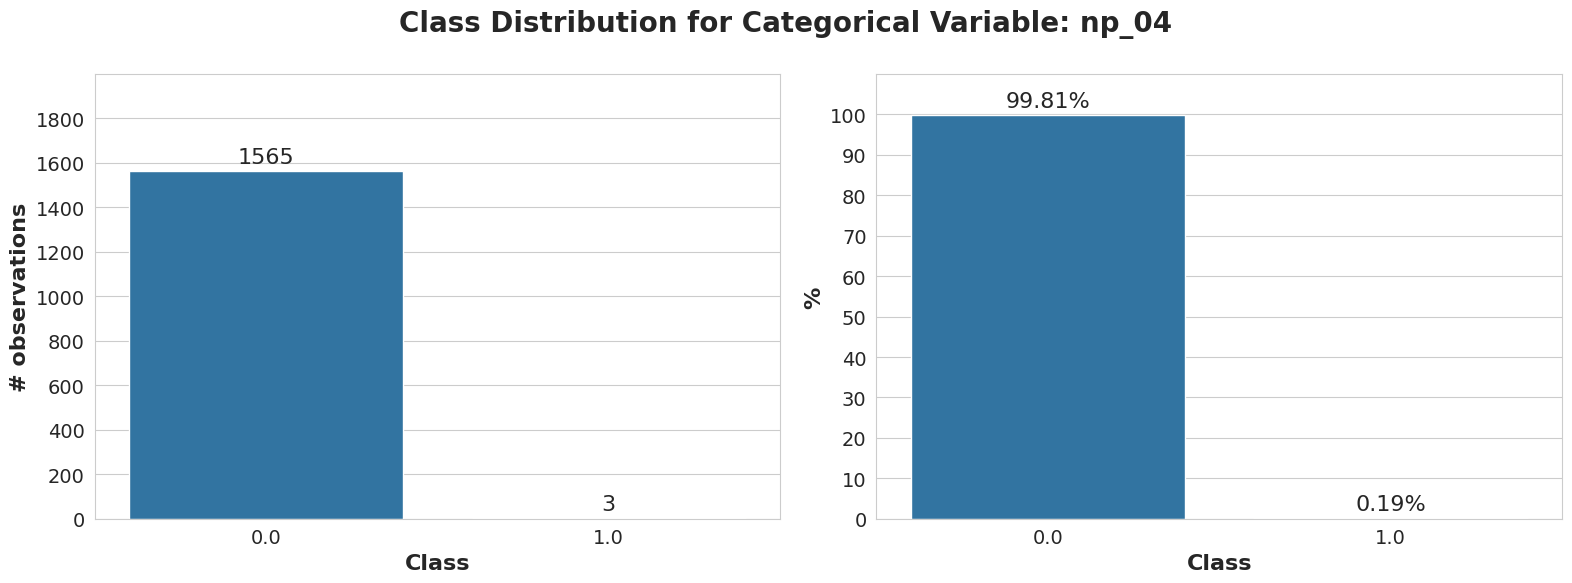

[SAVED] /home/leonardosaccotelli/Desktop/UNIVERSITA/MACHINE-LEARNING/Cost-Sensitive-Learning-For-Myocardial-Infarction-Mortality-Prediction/reports/figures/DP_data_exploration_cleaned/class_distribution_absolute_vs_percentage_np_05.png


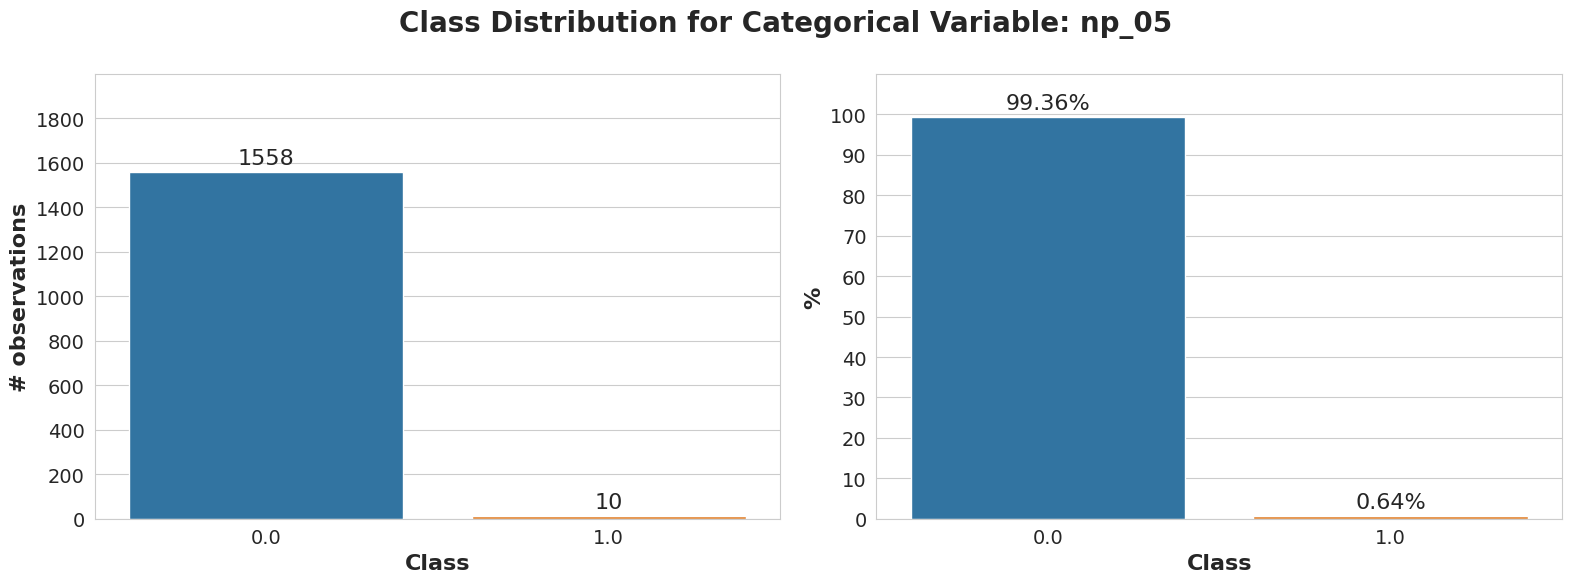

[SAVED] /home/leonardosaccotelli/Desktop/UNIVERSITA/MACHINE-LEARNING/Cost-Sensitive-Learning-For-Myocardial-Infarction-Mortality-Prediction/reports/figures/DP_data_exploration_cleaned/class_distribution_absolute_vs_percentage_np_07.png


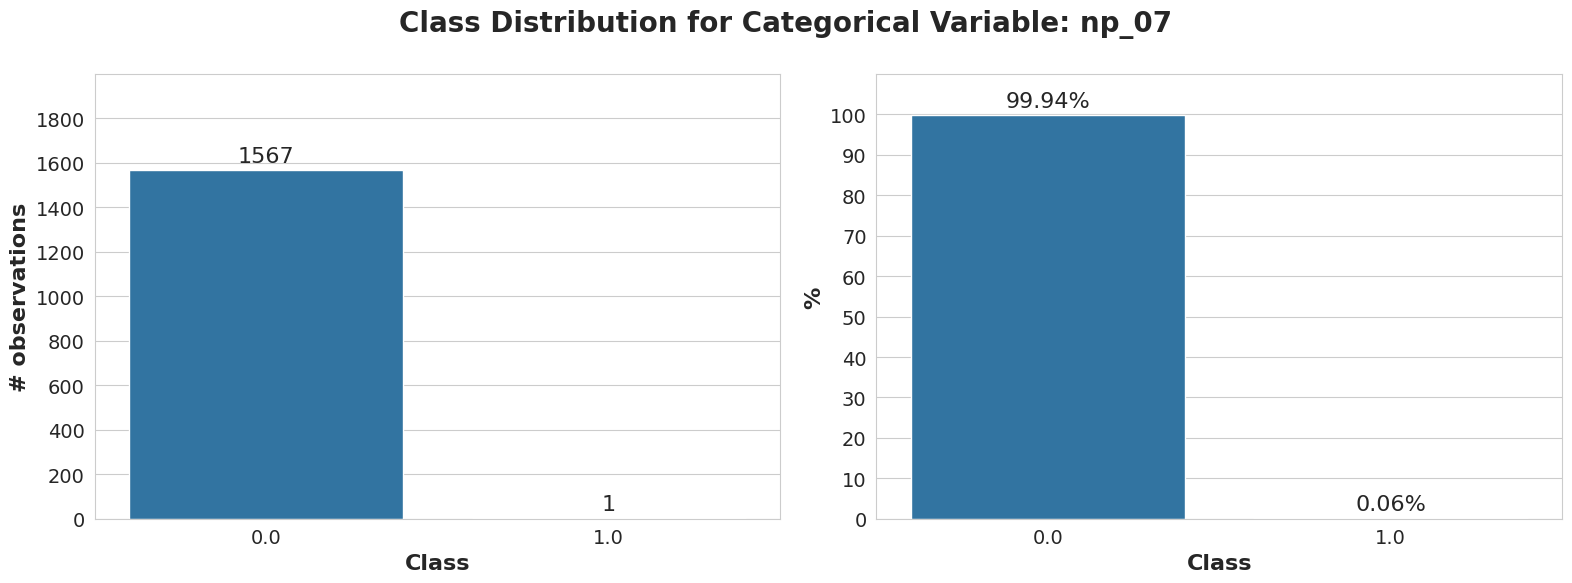

[SAVED] /home/leonardosaccotelli/Desktop/UNIVERSITA/MACHINE-LEARNING/Cost-Sensitive-Learning-For-Myocardial-Infarction-Mortality-Prediction/reports/figures/DP_data_exploration_cleaned/class_distribution_absolute_vs_percentage_np_08.png


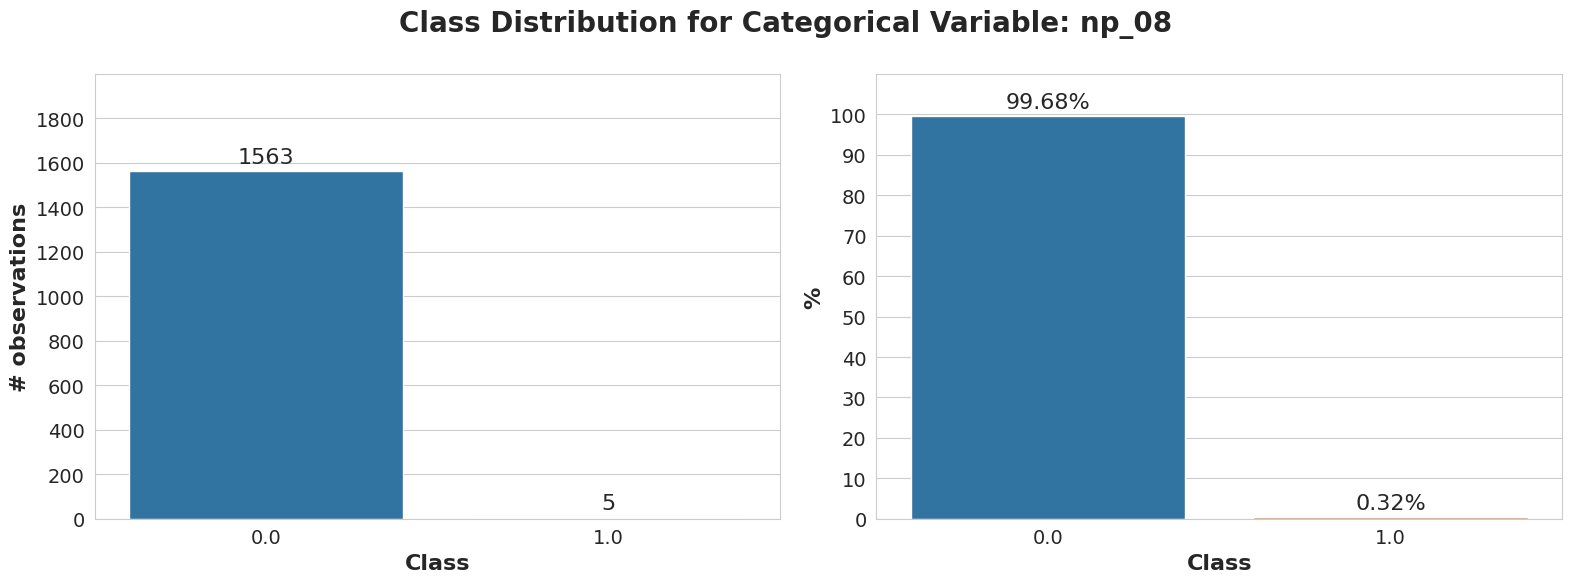

[SAVED] /home/leonardosaccotelli/Desktop/UNIVERSITA/MACHINE-LEARNING/Cost-Sensitive-Learning-For-Myocardial-Infarction-Mortality-Prediction/reports/figures/DP_data_exploration_cleaned/class_distribution_absolute_vs_percentage_np_09.png


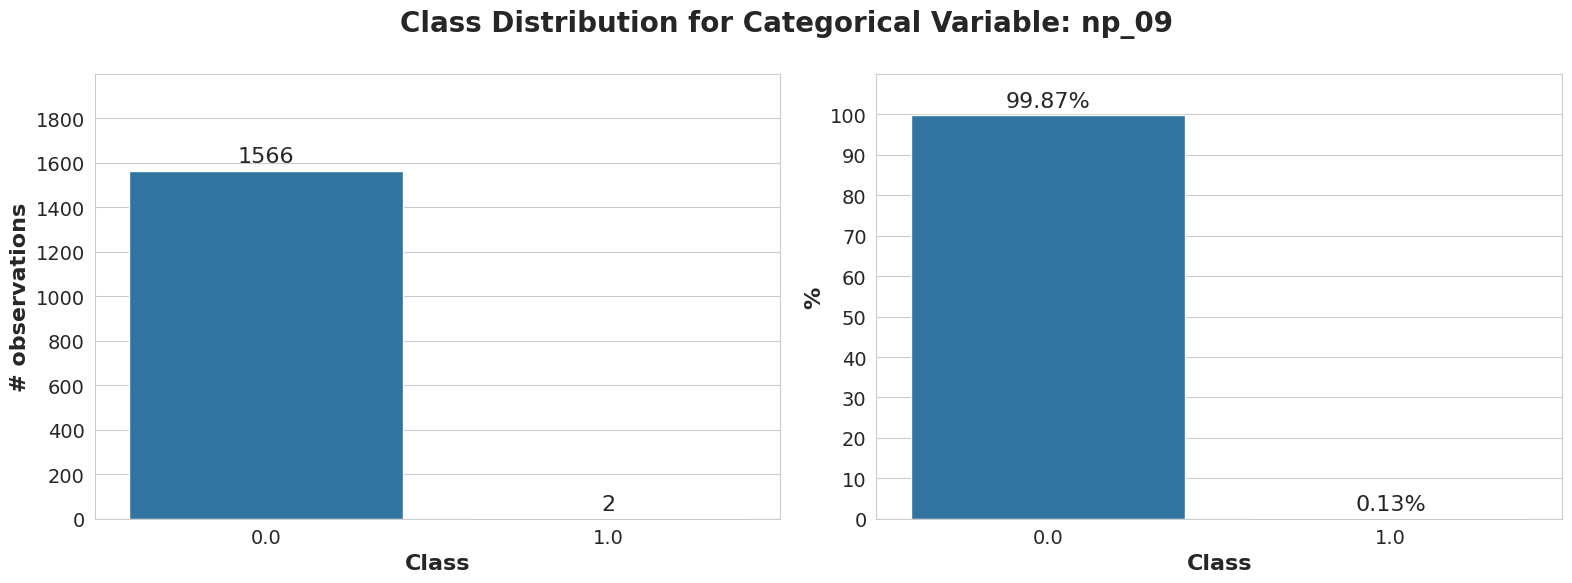

[SAVED] /home/leonardosaccotelli/Desktop/UNIVERSITA/MACHINE-LEARNING/Cost-Sensitive-Learning-For-Myocardial-Infarction-Mortality-Prediction/reports/figures/DP_data_exploration_cleaned/class_distribution_absolute_vs_percentage_np_10.png


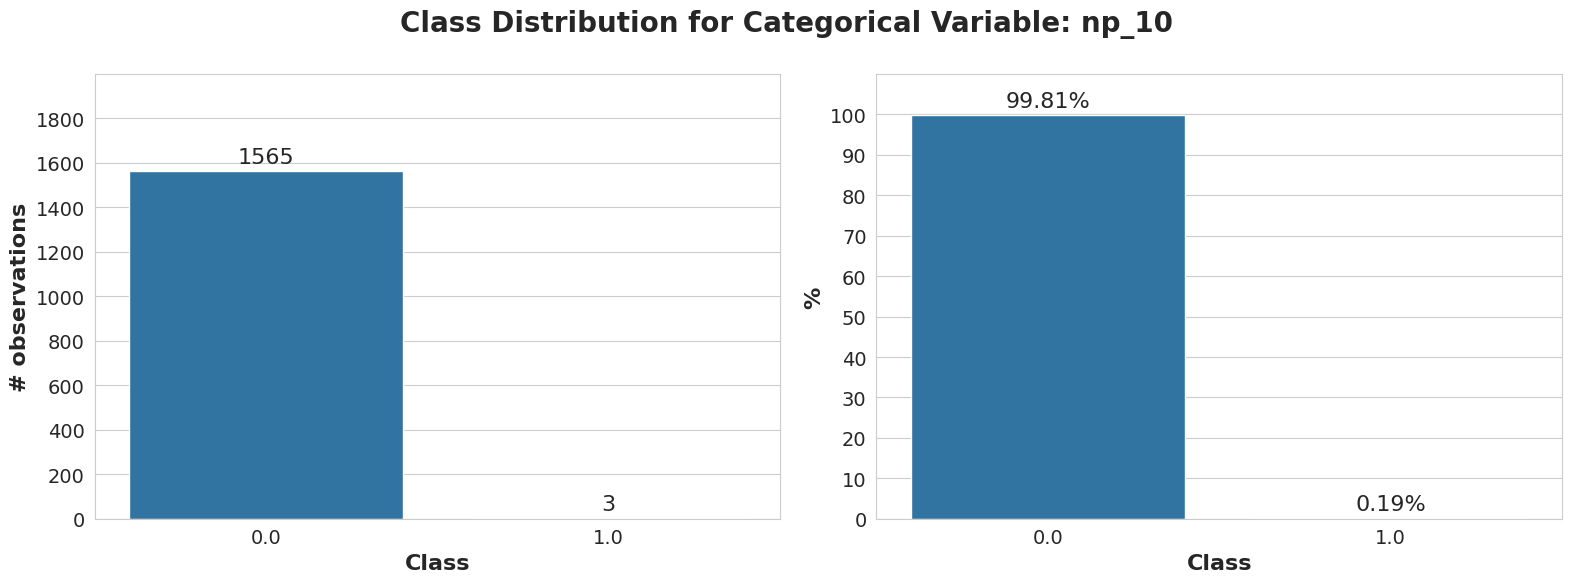

[SAVED] /home/leonardosaccotelli/Desktop/UNIVERSITA/MACHINE-LEARNING/Cost-Sensitive-Learning-For-Myocardial-Infarction-Mortality-Prediction/reports/figures/DP_data_exploration_cleaned/class_distribution_absolute_vs_percentage_endocr_01.png


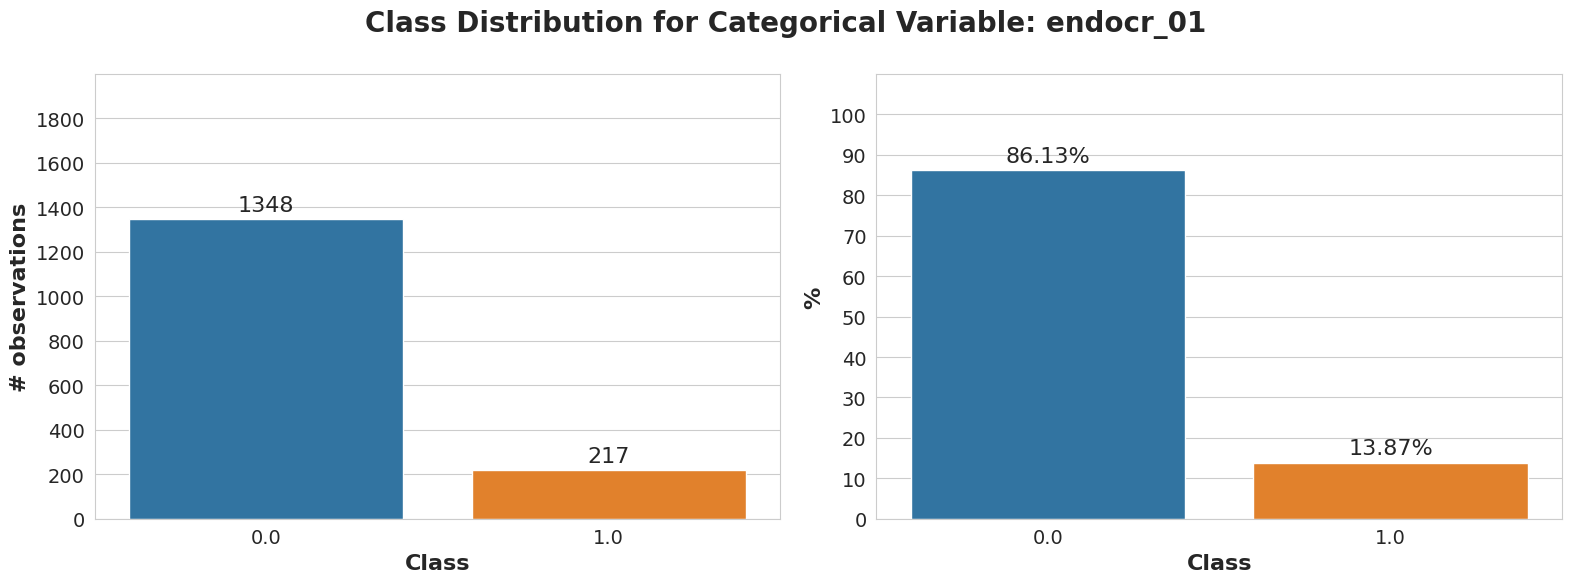

[SAVED] /home/leonardosaccotelli/Desktop/UNIVERSITA/MACHINE-LEARNING/Cost-Sensitive-Learning-For-Myocardial-Infarction-Mortality-Prediction/reports/figures/DP_data_exploration_cleaned/class_distribution_absolute_vs_percentage_endocr_02.png


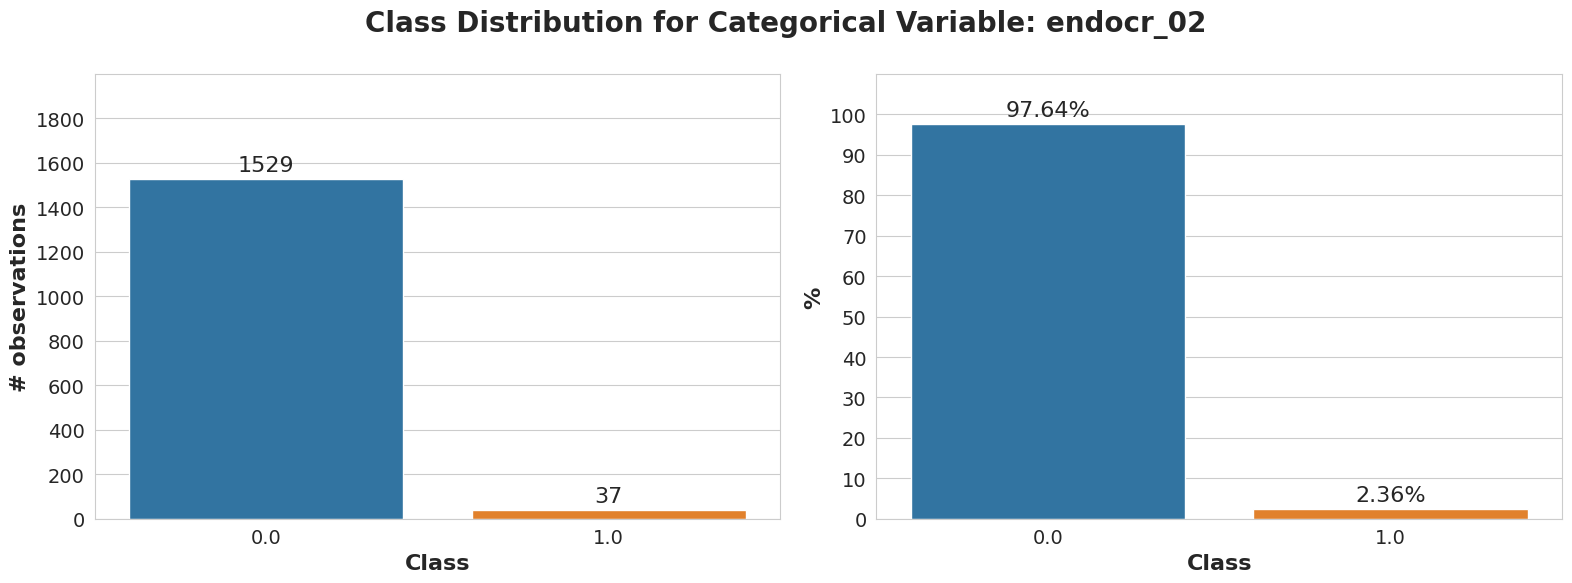

[SAVED] /home/leonardosaccotelli/Desktop/UNIVERSITA/MACHINE-LEARNING/Cost-Sensitive-Learning-For-Myocardial-Infarction-Mortality-Prediction/reports/figures/DP_data_exploration_cleaned/class_distribution_absolute_vs_percentage_endocr_03.png


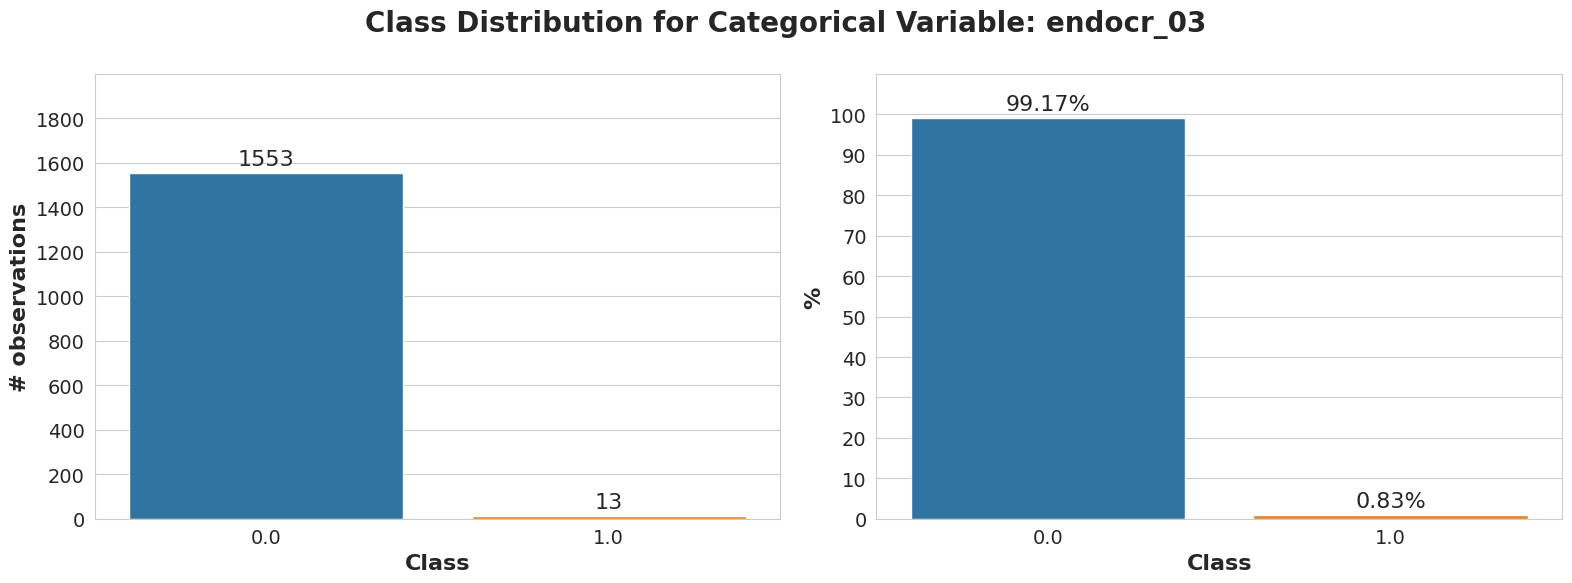

[SAVED] /home/leonardosaccotelli/Desktop/UNIVERSITA/MACHINE-LEARNING/Cost-Sensitive-Learning-For-Myocardial-Infarction-Mortality-Prediction/reports/figures/DP_data_exploration_cleaned/class_distribution_absolute_vs_percentage_zab_leg_01.png


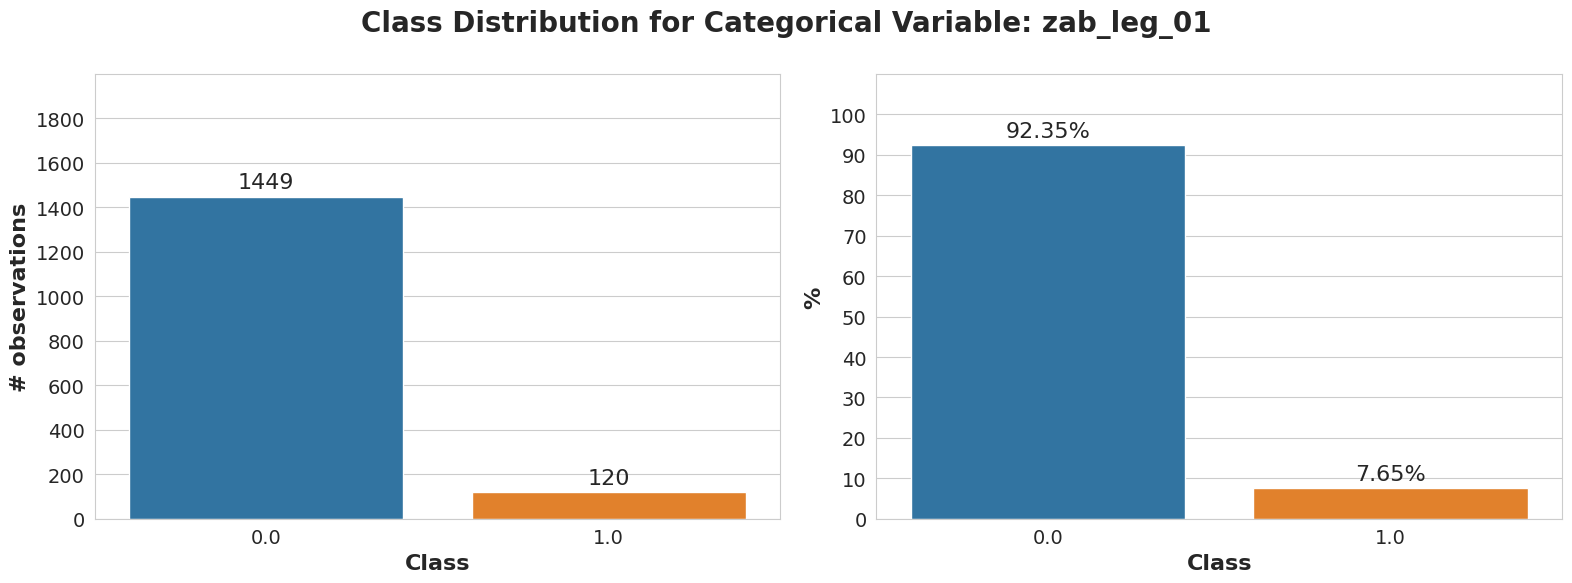

[SAVED] /home/leonardosaccotelli/Desktop/UNIVERSITA/MACHINE-LEARNING/Cost-Sensitive-Learning-For-Myocardial-Infarction-Mortality-Prediction/reports/figures/DP_data_exploration_cleaned/class_distribution_absolute_vs_percentage_zab_leg_02.png


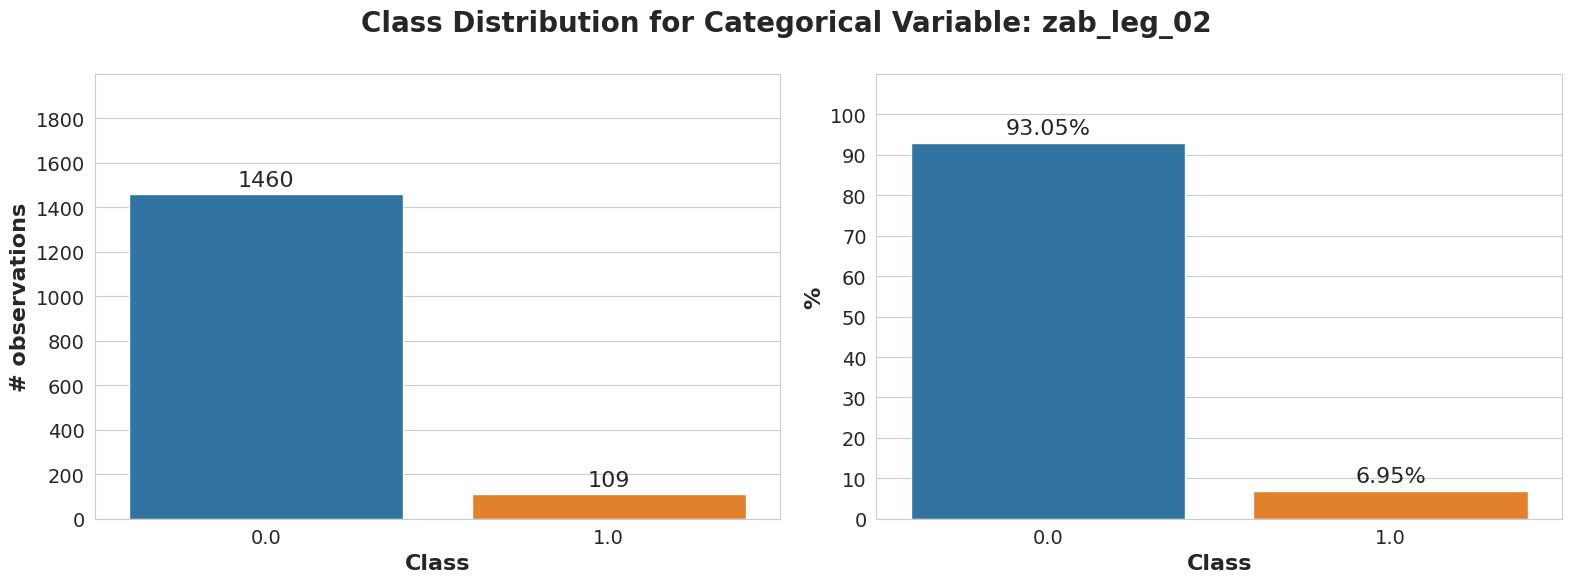

[SAVED] /home/leonardosaccotelli/Desktop/UNIVERSITA/MACHINE-LEARNING/Cost-Sensitive-Learning-For-Myocardial-Infarction-Mortality-Prediction/reports/figures/DP_data_exploration_cleaned/class_distribution_absolute_vs_percentage_zab_leg_03.png


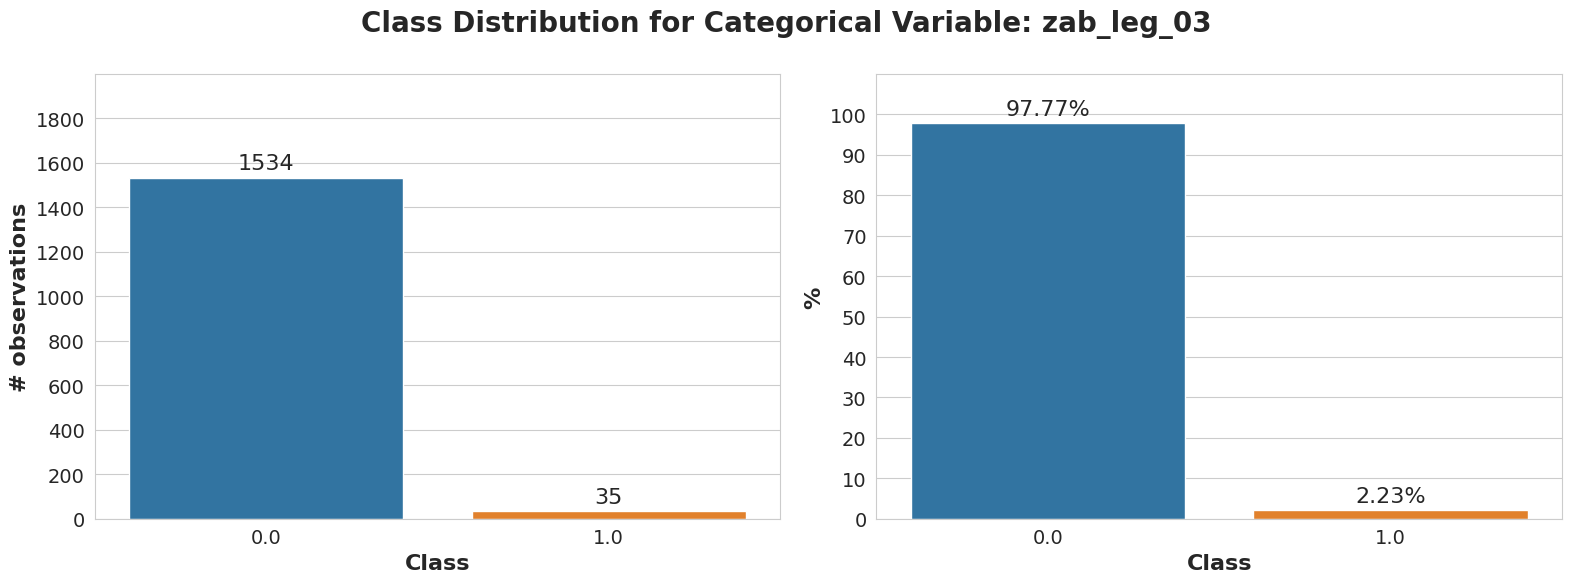

[SAVED] /home/leonardosaccotelli/Desktop/UNIVERSITA/MACHINE-LEARNING/Cost-Sensitive-Learning-For-Myocardial-Infarction-Mortality-Prediction/reports/figures/DP_data_exploration_cleaned/class_distribution_absolute_vs_percentage_zab_leg_04.png


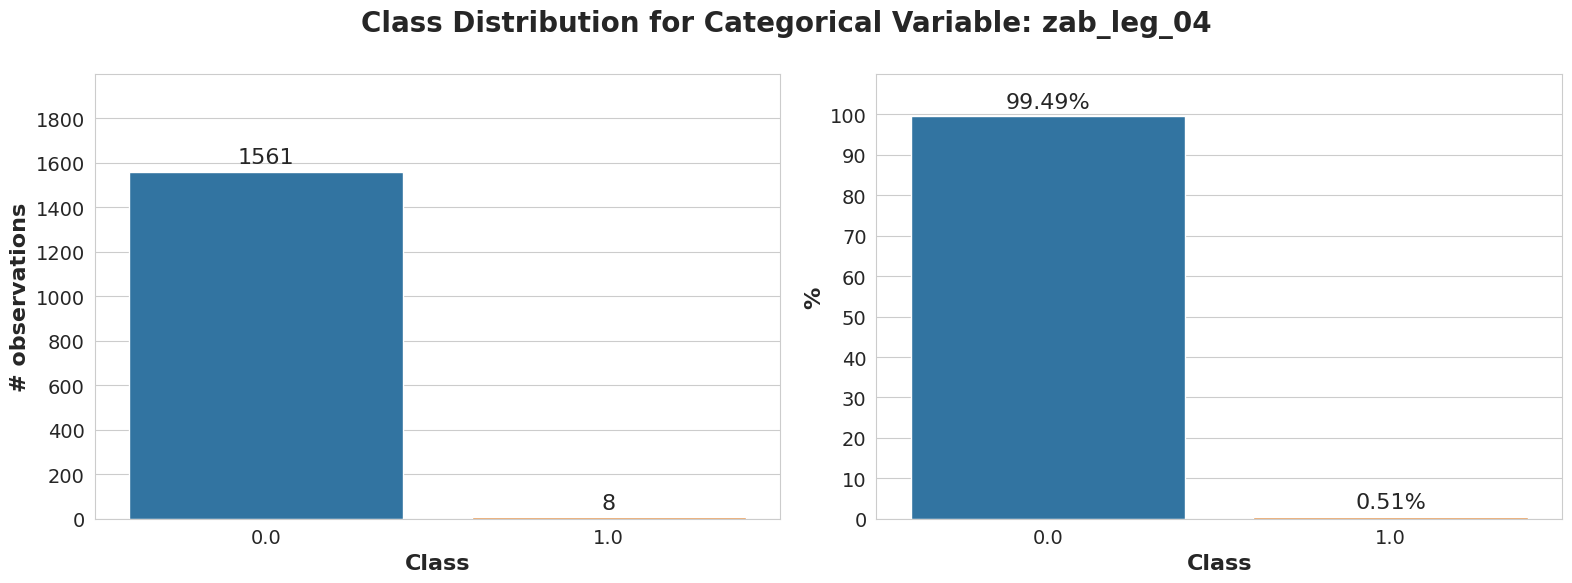

[SAVED] /home/leonardosaccotelli/Desktop/UNIVERSITA/MACHINE-LEARNING/Cost-Sensitive-Learning-For-Myocardial-Infarction-Mortality-Prediction/reports/figures/DP_data_exploration_cleaned/class_distribution_absolute_vs_percentage_zab_leg_06.png


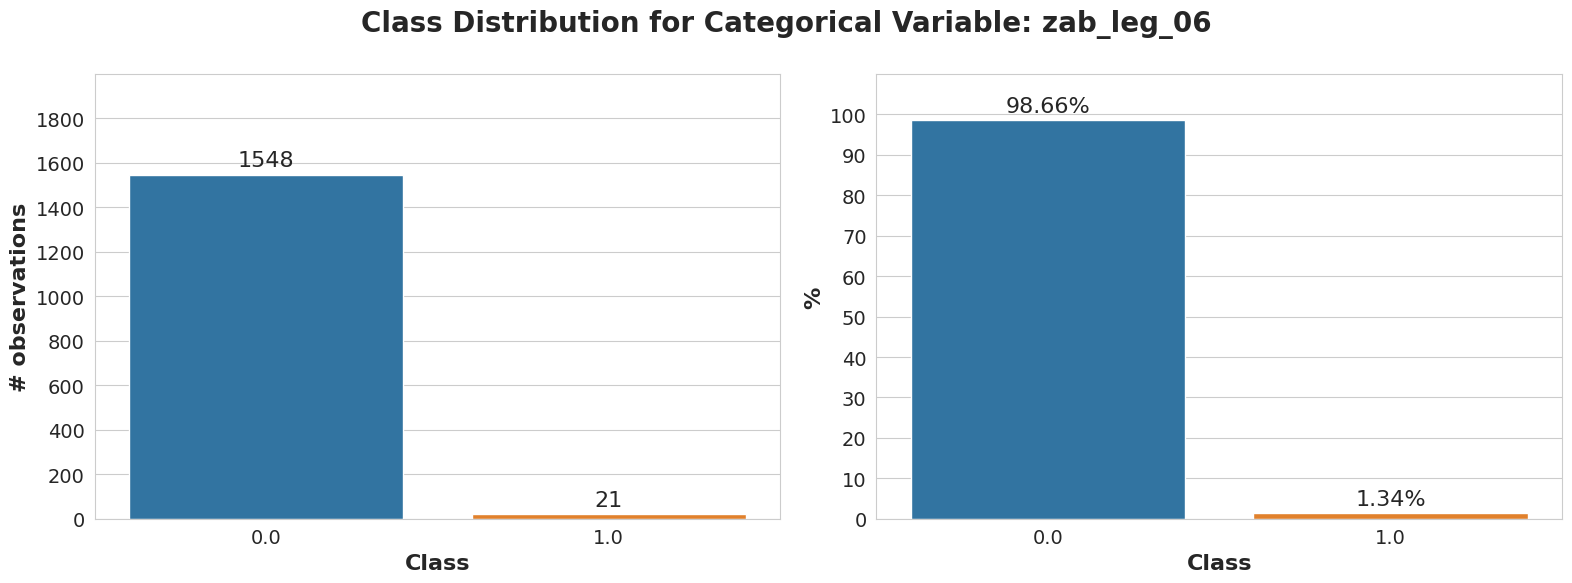

[SAVED] /home/leonardosaccotelli/Desktop/UNIVERSITA/MACHINE-LEARNING/Cost-Sensitive-Learning-For-Myocardial-Infarction-Mortality-Prediction/reports/figures/DP_data_exploration_cleaned/class_distribution_absolute_vs_percentage_O_L_POST.png


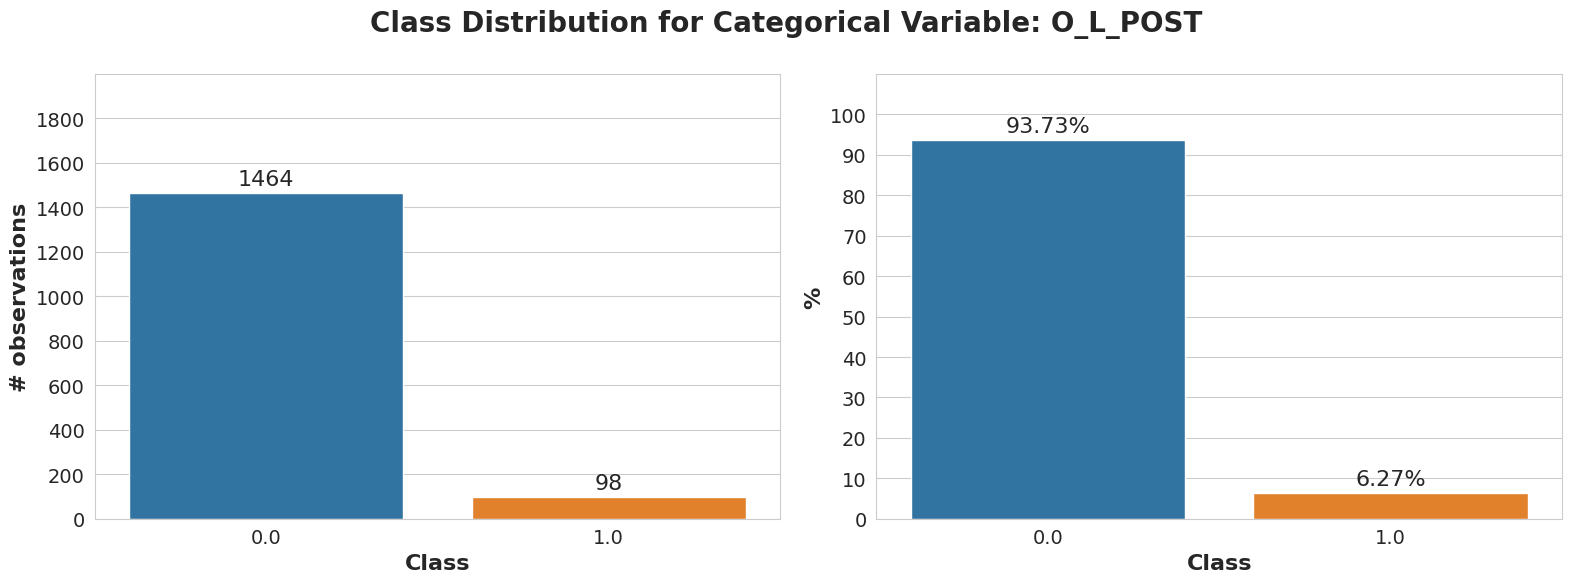

[SAVED] /home/leonardosaccotelli/Desktop/UNIVERSITA/MACHINE-LEARNING/Cost-Sensitive-Learning-For-Myocardial-Infarction-Mortality-Prediction/reports/figures/DP_data_exploration_cleaned/class_distribution_absolute_vs_percentage_K_SH_POST.png


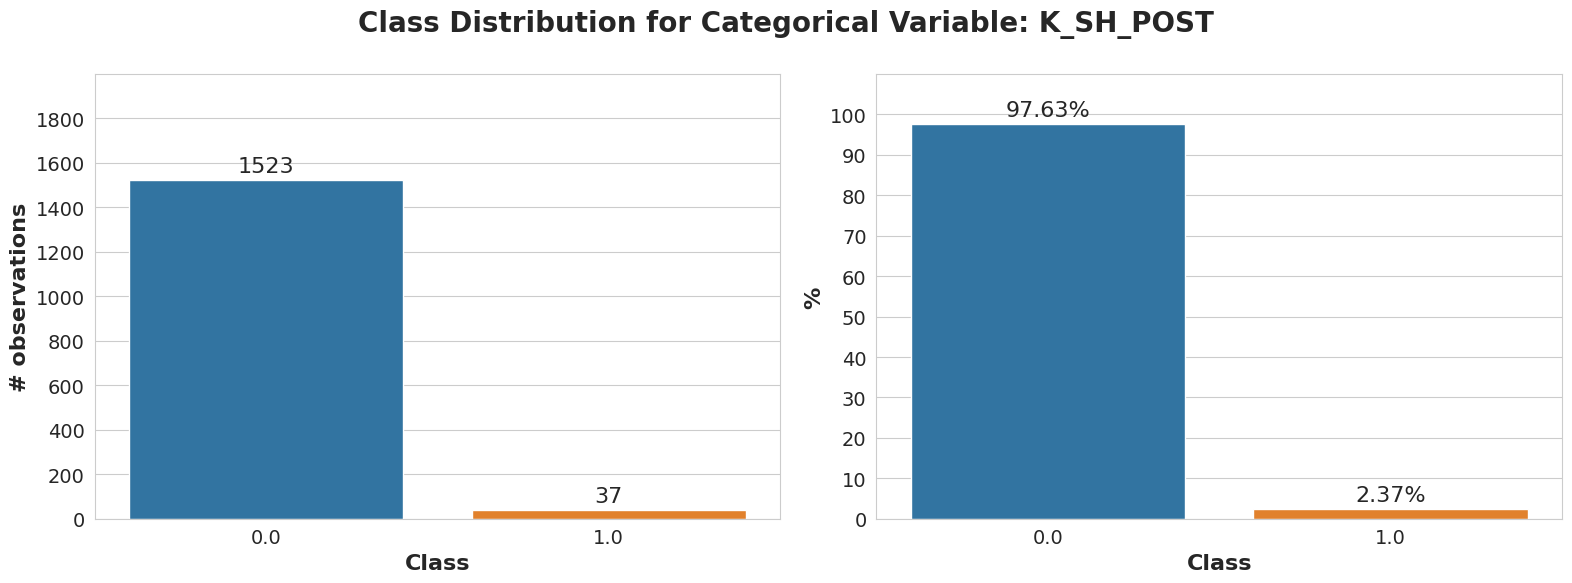

[SAVED] /home/leonardosaccotelli/Desktop/UNIVERSITA/MACHINE-LEARNING/Cost-Sensitive-Learning-For-Myocardial-Infarction-Mortality-Prediction/reports/figures/DP_data_exploration_cleaned/class_distribution_absolute_vs_percentage_MP_TP_POST.png


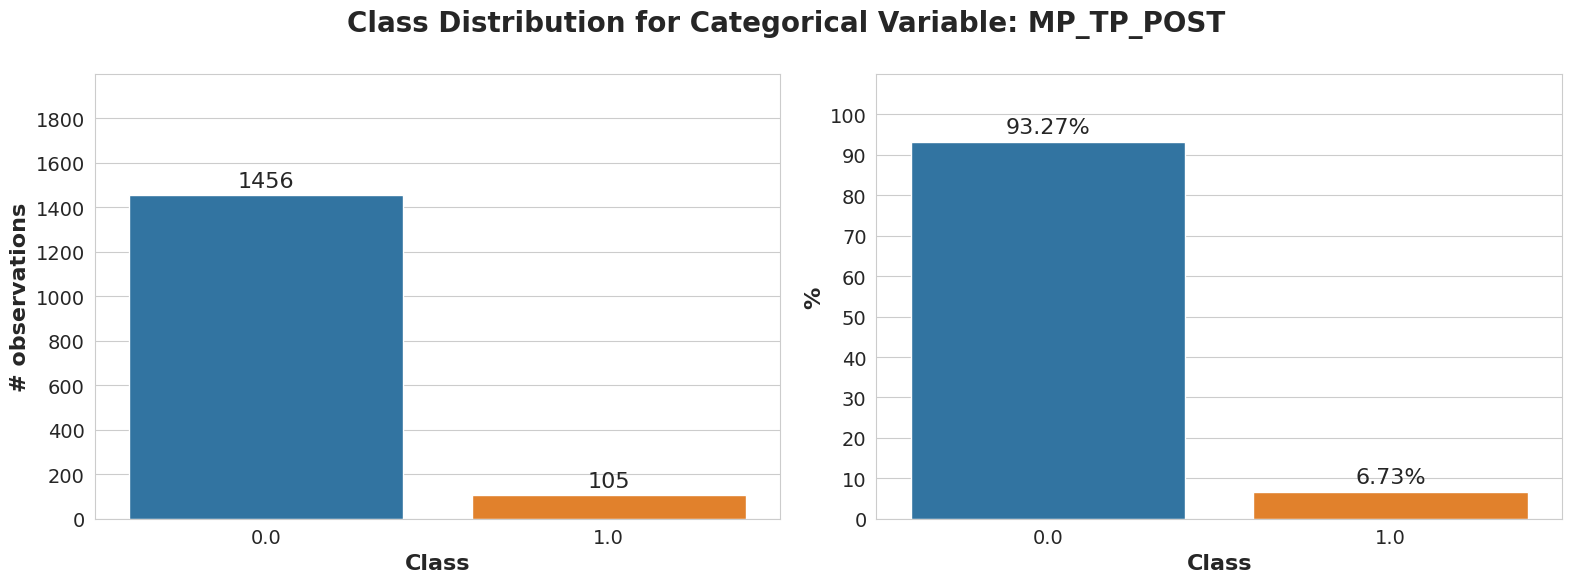

[SAVED] /home/leonardosaccotelli/Desktop/UNIVERSITA/MACHINE-LEARNING/Cost-Sensitive-Learning-For-Myocardial-Infarction-Mortality-Prediction/reports/figures/DP_data_exploration_cleaned/class_distribution_absolute_vs_percentage_SVT_POST.png


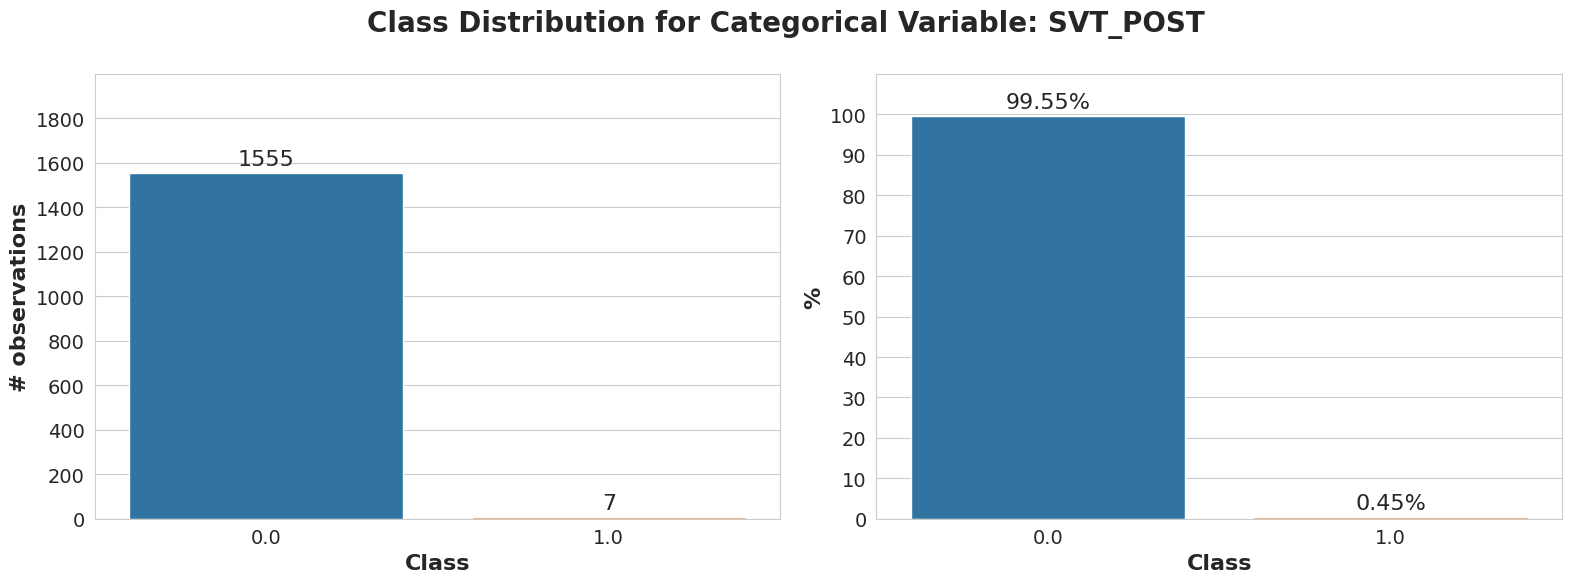

[SAVED] /home/leonardosaccotelli/Desktop/UNIVERSITA/MACHINE-LEARNING/Cost-Sensitive-Learning-For-Myocardial-Infarction-Mortality-Prediction/reports/figures/DP_data_exploration_cleaned/class_distribution_absolute_vs_percentage_GT_POST.png


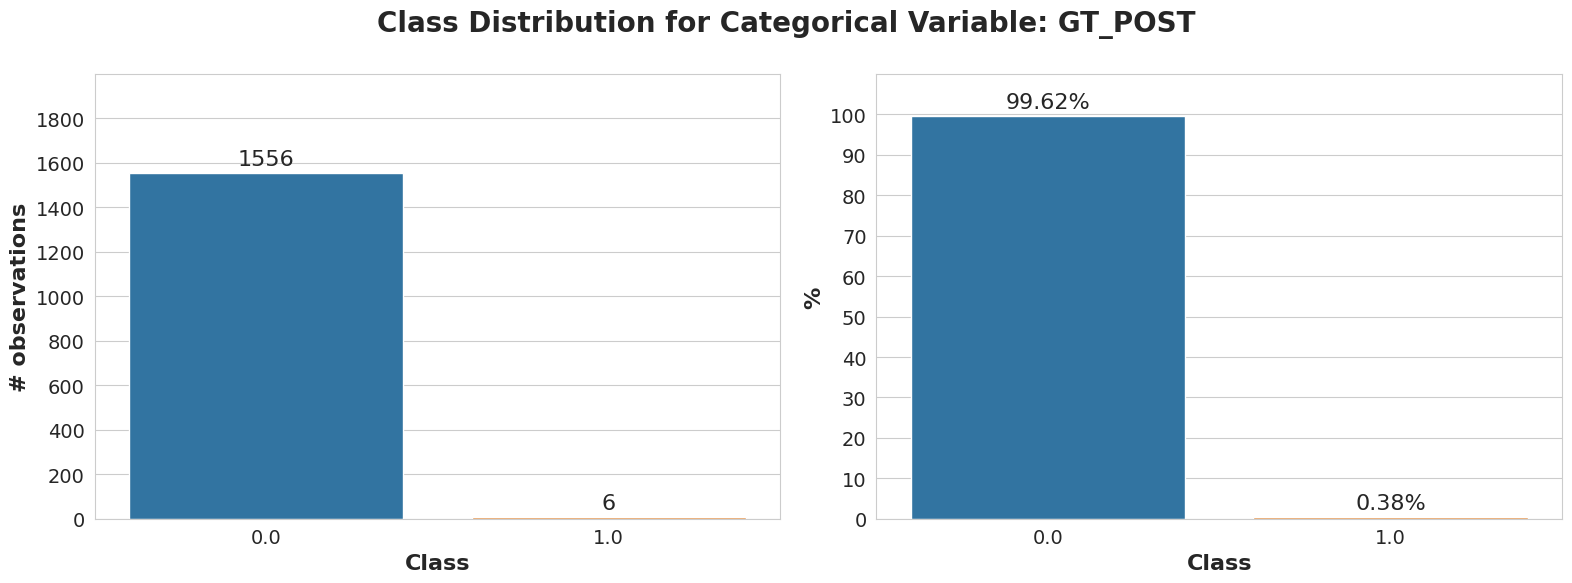

[SAVED] /home/leonardosaccotelli/Desktop/UNIVERSITA/MACHINE-LEARNING/Cost-Sensitive-Learning-For-Myocardial-Infarction-Mortality-Prediction/reports/figures/DP_data_exploration_cleaned/class_distribution_absolute_vs_percentage_FIB_G_POST.png


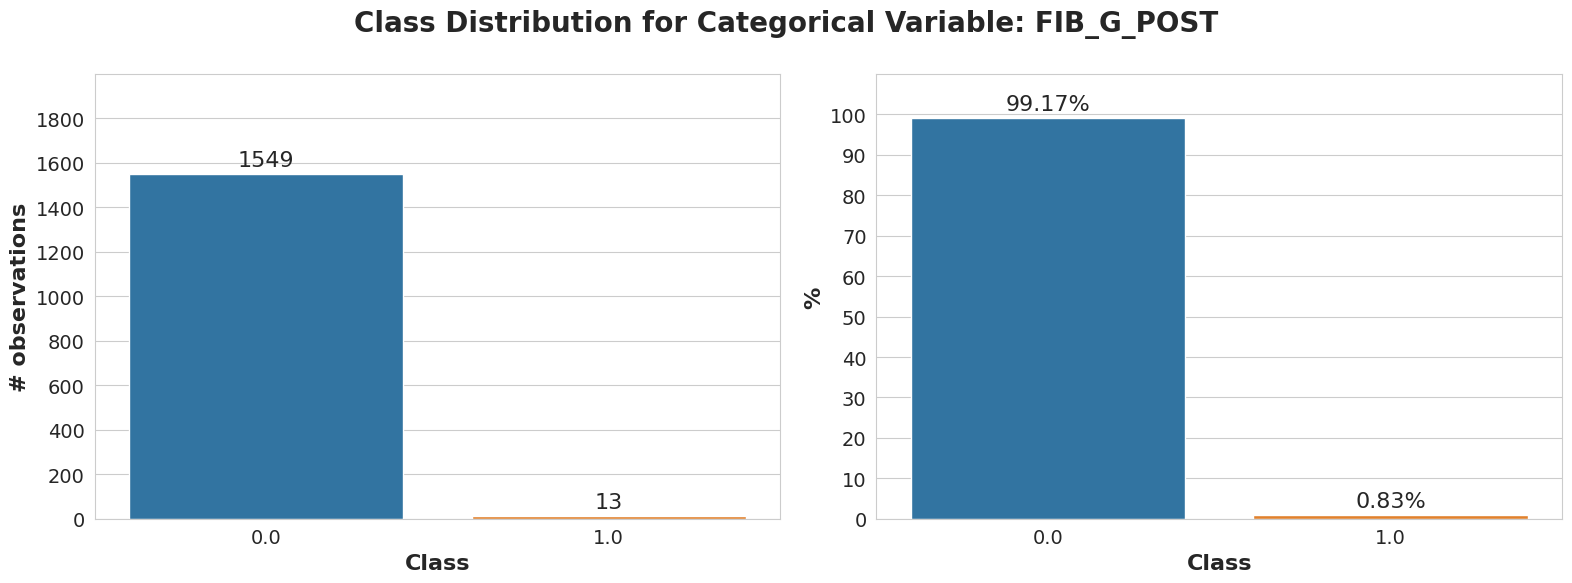

[SAVED] /home/leonardosaccotelli/Desktop/UNIVERSITA/MACHINE-LEARNING/Cost-Sensitive-Learning-For-Myocardial-Infarction-Mortality-Prediction/reports/figures/DP_data_exploration_cleaned/class_distribution_absolute_vs_percentage_IM_PG_P.png


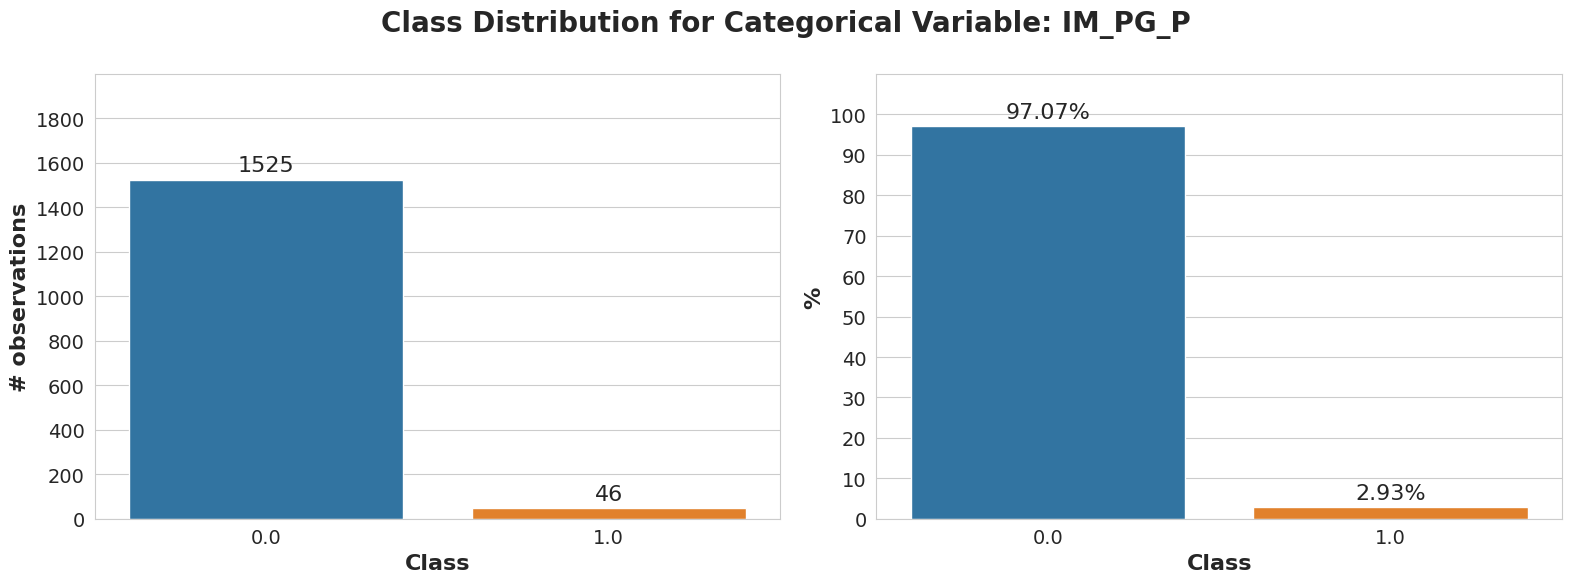

[SAVED] /home/leonardosaccotelli/Desktop/UNIVERSITA/MACHINE-LEARNING/Cost-Sensitive-Learning-For-Myocardial-Infarction-Mortality-Prediction/reports/figures/DP_data_exploration_cleaned/class_distribution_absolute_vs_percentage_ritm_ecg_p_01.png


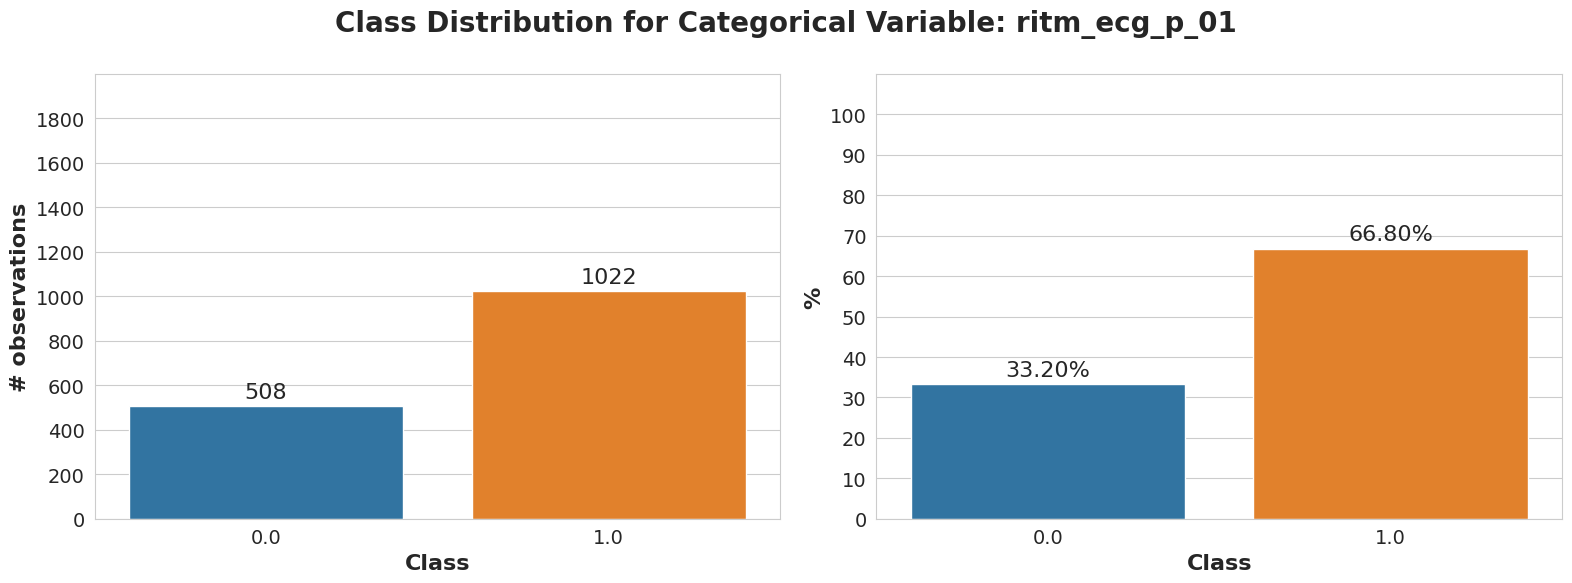

[SAVED] /home/leonardosaccotelli/Desktop/UNIVERSITA/MACHINE-LEARNING/Cost-Sensitive-Learning-For-Myocardial-Infarction-Mortality-Prediction/reports/figures/DP_data_exploration_cleaned/class_distribution_absolute_vs_percentage_ritm_ecg_p_02.png


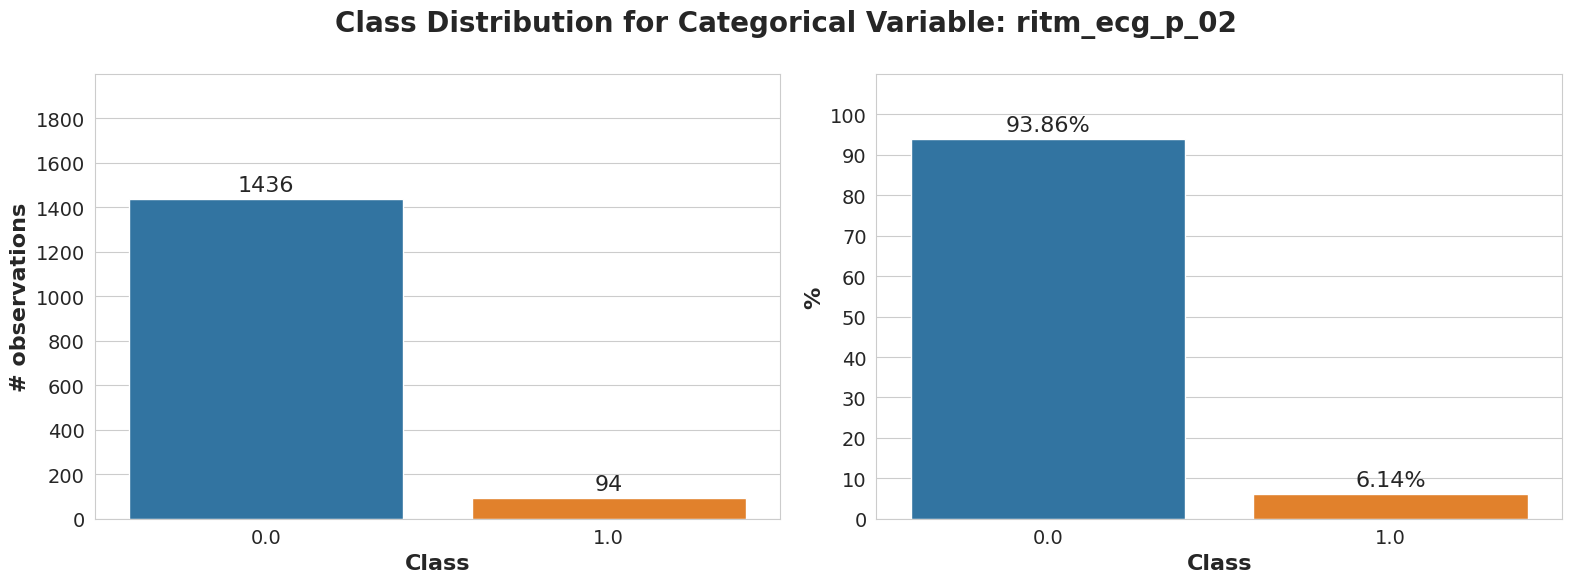

[SAVED] /home/leonardosaccotelli/Desktop/UNIVERSITA/MACHINE-LEARNING/Cost-Sensitive-Learning-For-Myocardial-Infarction-Mortality-Prediction/reports/figures/DP_data_exploration_cleaned/class_distribution_absolute_vs_percentage_ritm_ecg_p_04.png


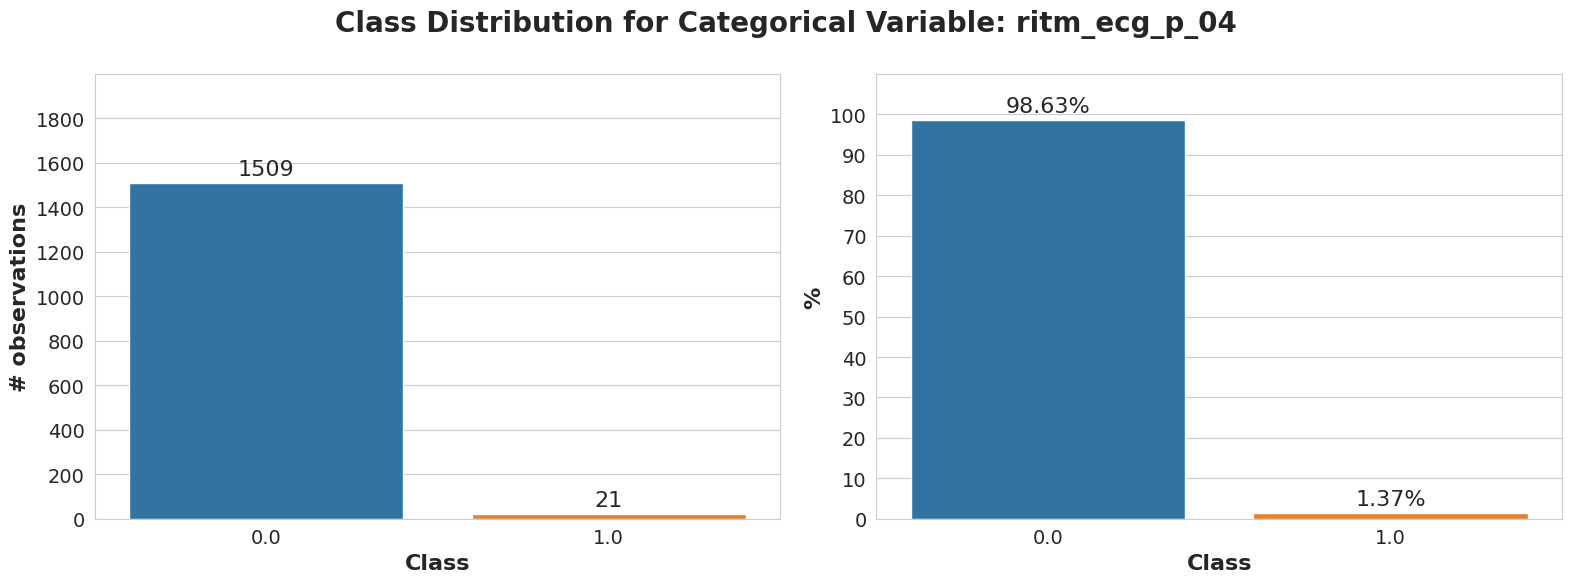

[SAVED] /home/leonardosaccotelli/Desktop/UNIVERSITA/MACHINE-LEARNING/Cost-Sensitive-Learning-For-Myocardial-Infarction-Mortality-Prediction/reports/figures/DP_data_exploration_cleaned/class_distribution_absolute_vs_percentage_ritm_ecg_p_06.png


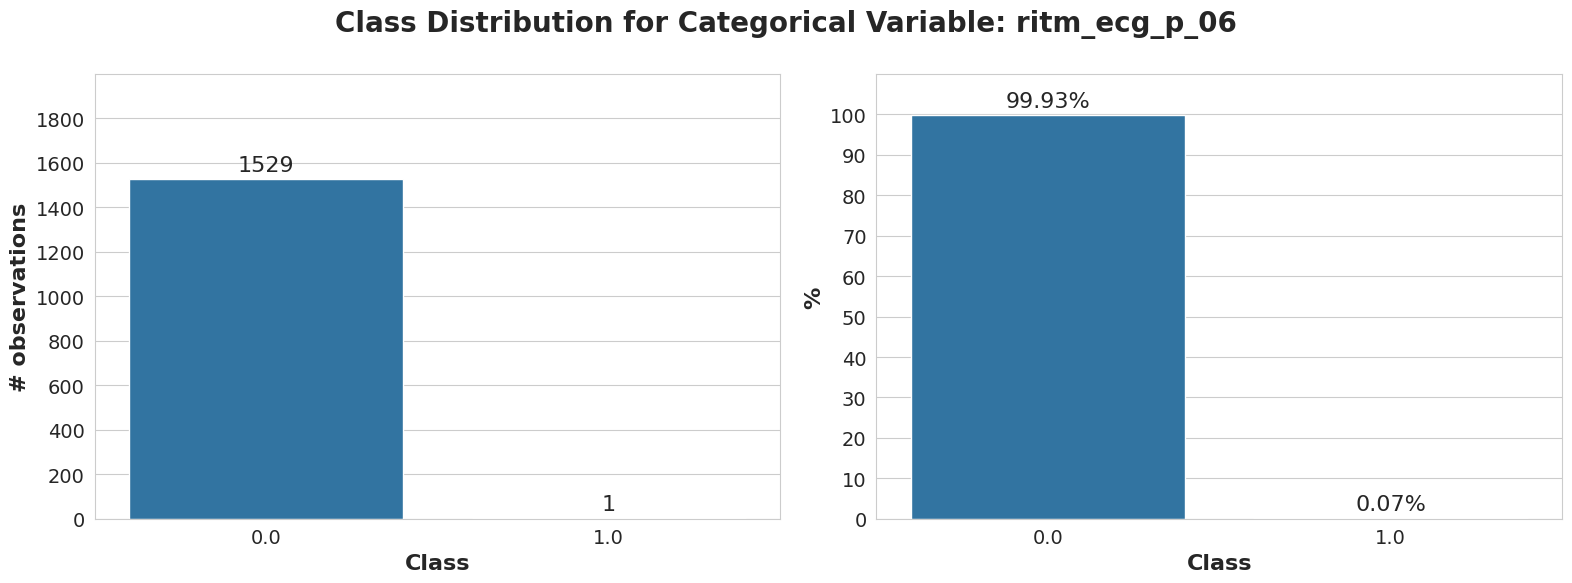

[SAVED] /home/leonardosaccotelli/Desktop/UNIVERSITA/MACHINE-LEARNING/Cost-Sensitive-Learning-For-Myocardial-Infarction-Mortality-Prediction/reports/figures/DP_data_exploration_cleaned/class_distribution_absolute_vs_percentage_ritm_ecg_p_07.png


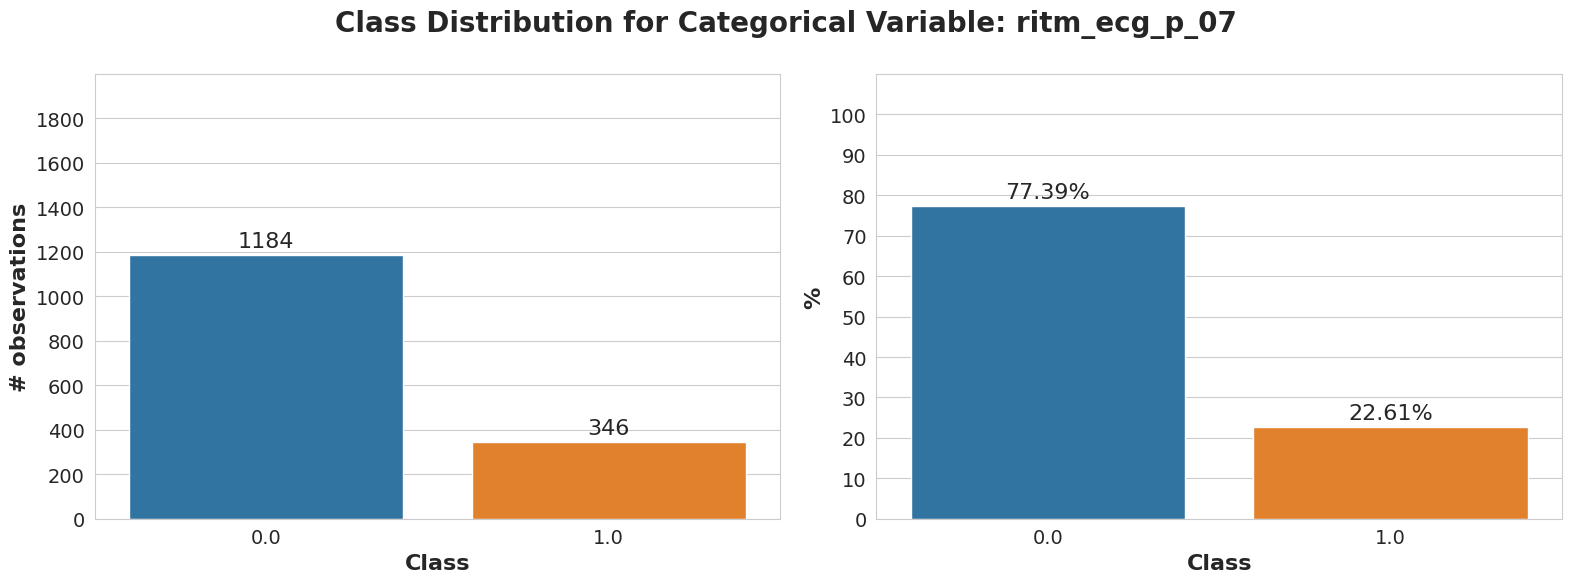

[SAVED] /home/leonardosaccotelli/Desktop/UNIVERSITA/MACHINE-LEARNING/Cost-Sensitive-Learning-For-Myocardial-Infarction-Mortality-Prediction/reports/figures/DP_data_exploration_cleaned/class_distribution_absolute_vs_percentage_ritm_ecg_p_08.png


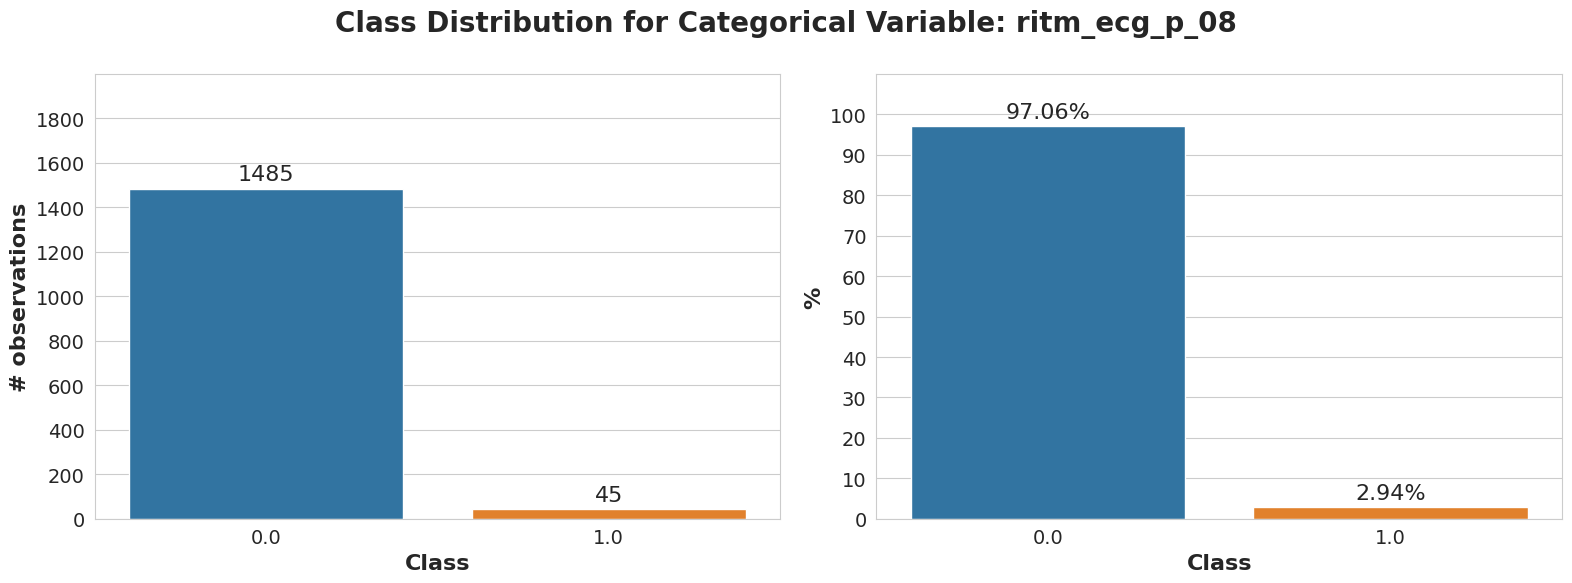

[SAVED] /home/leonardosaccotelli/Desktop/UNIVERSITA/MACHINE-LEARNING/Cost-Sensitive-Learning-For-Myocardial-Infarction-Mortality-Prediction/reports/figures/DP_data_exploration_cleaned/class_distribution_absolute_vs_percentage_n_r_ecg_p_01.png


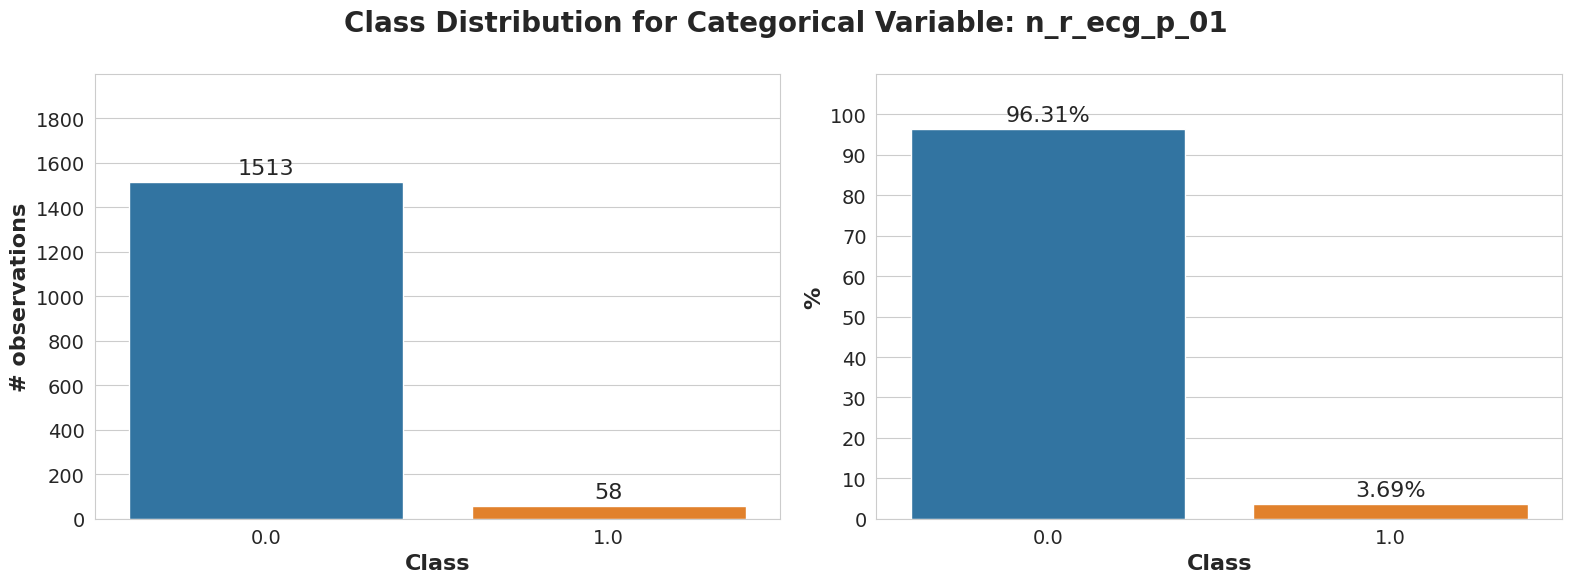

[SAVED] /home/leonardosaccotelli/Desktop/UNIVERSITA/MACHINE-LEARNING/Cost-Sensitive-Learning-For-Myocardial-Infarction-Mortality-Prediction/reports/figures/DP_data_exploration_cleaned/class_distribution_absolute_vs_percentage_n_r_ecg_p_02.png


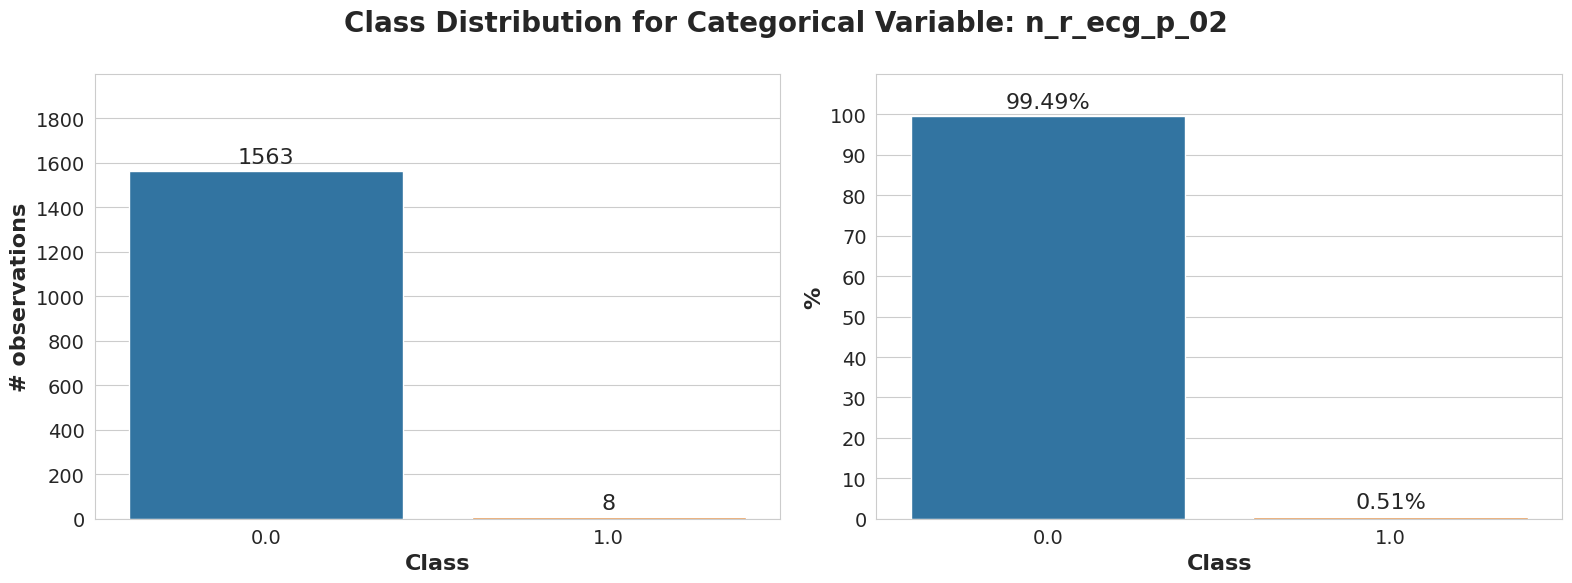

[SAVED] /home/leonardosaccotelli/Desktop/UNIVERSITA/MACHINE-LEARNING/Cost-Sensitive-Learning-For-Myocardial-Infarction-Mortality-Prediction/reports/figures/DP_data_exploration_cleaned/class_distribution_absolute_vs_percentage_n_r_ecg_p_03.png


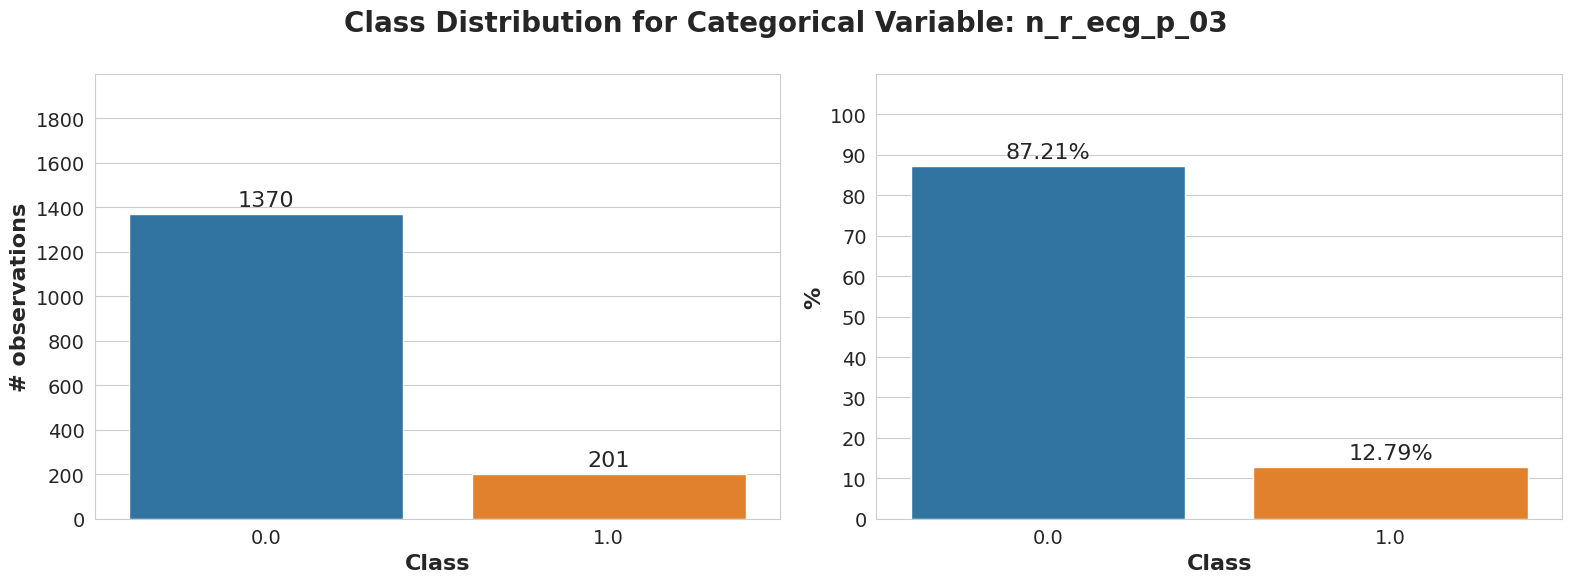

[SAVED] /home/leonardosaccotelli/Desktop/UNIVERSITA/MACHINE-LEARNING/Cost-Sensitive-Learning-For-Myocardial-Infarction-Mortality-Prediction/reports/figures/DP_data_exploration_cleaned/class_distribution_absolute_vs_percentage_n_r_ecg_p_04.png


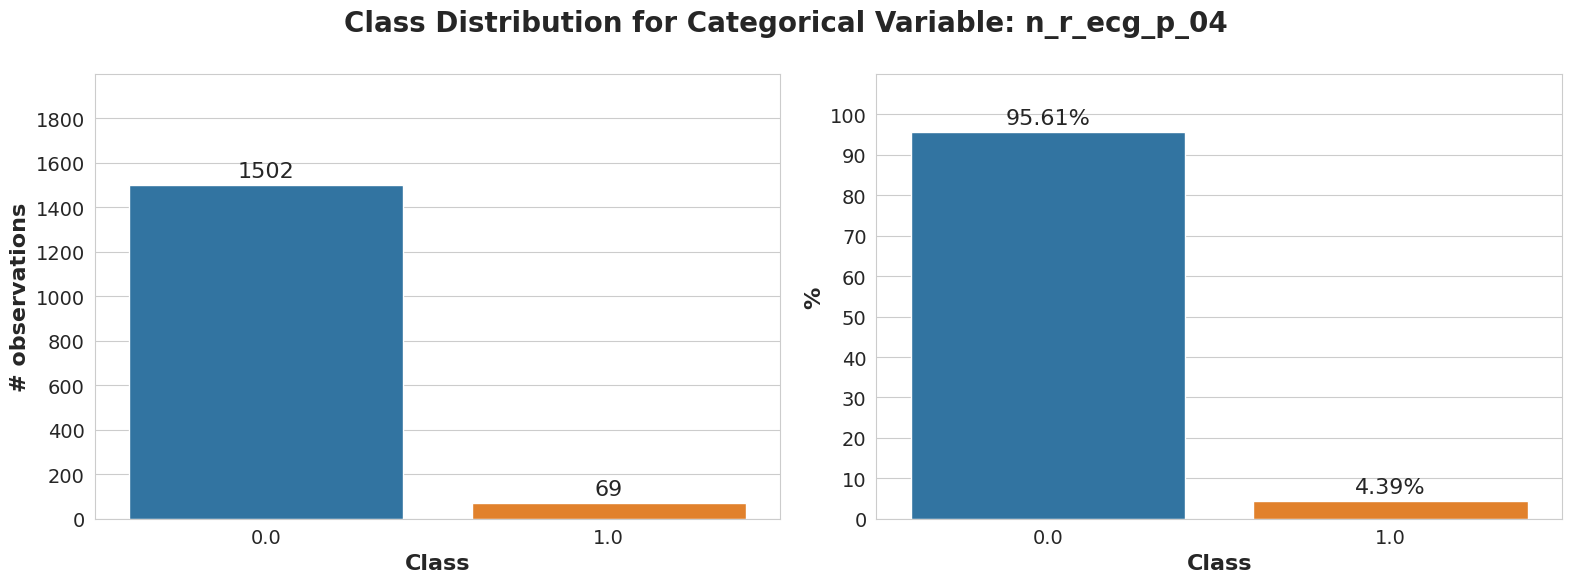

[SAVED] /home/leonardosaccotelli/Desktop/UNIVERSITA/MACHINE-LEARNING/Cost-Sensitive-Learning-For-Myocardial-Infarction-Mortality-Prediction/reports/figures/DP_data_exploration_cleaned/class_distribution_absolute_vs_percentage_n_r_ecg_p_05.png


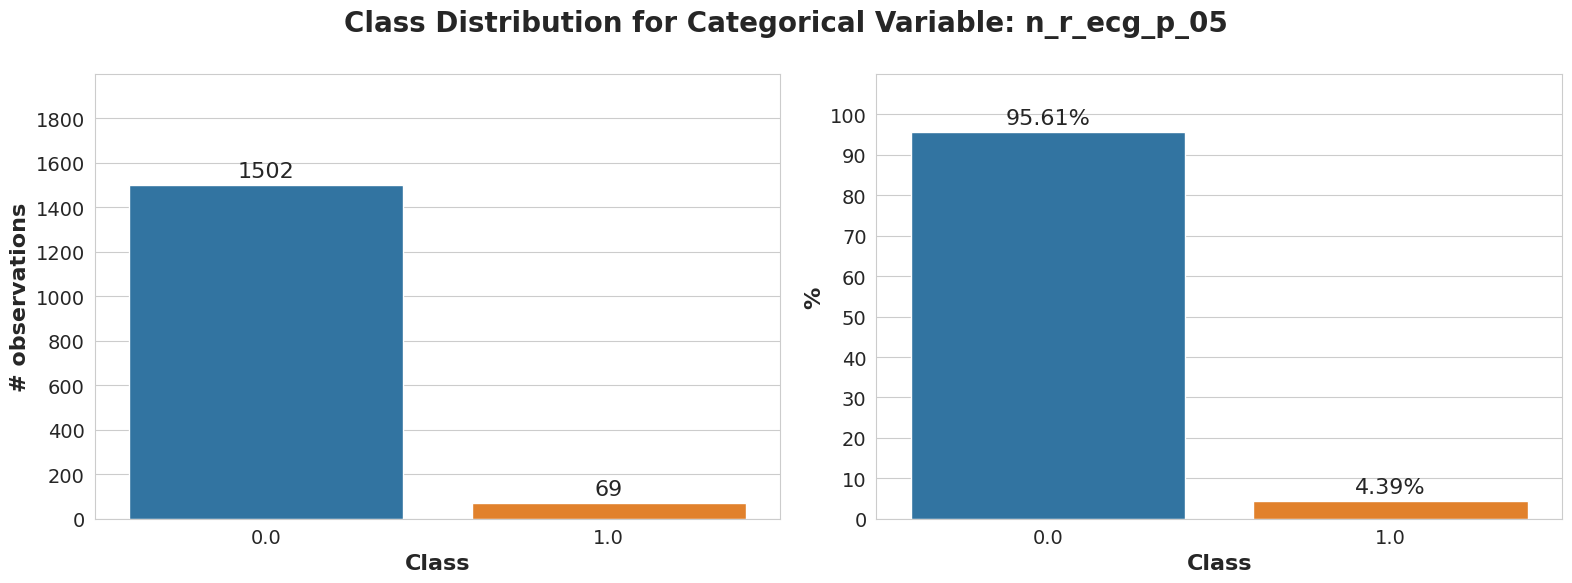

[SAVED] /home/leonardosaccotelli/Desktop/UNIVERSITA/MACHINE-LEARNING/Cost-Sensitive-Learning-For-Myocardial-Infarction-Mortality-Prediction/reports/figures/DP_data_exploration_cleaned/class_distribution_absolute_vs_percentage_n_r_ecg_p_06.png


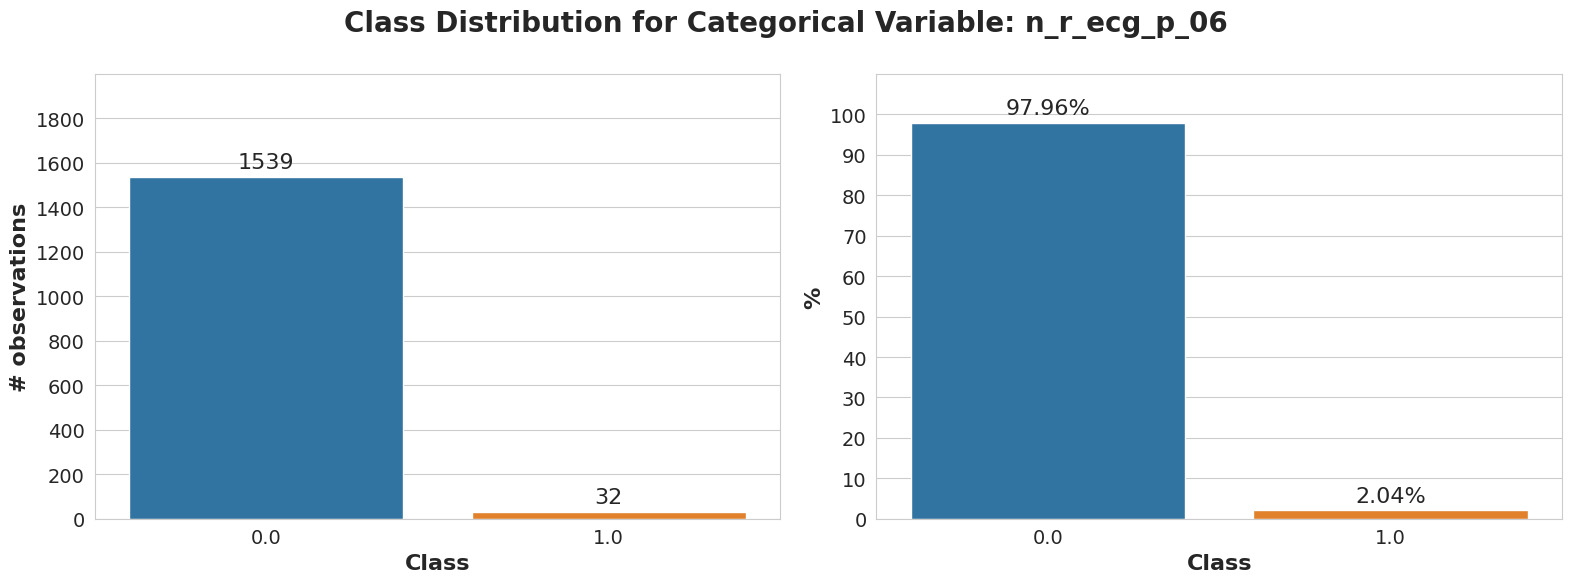

[SAVED] /home/leonardosaccotelli/Desktop/UNIVERSITA/MACHINE-LEARNING/Cost-Sensitive-Learning-For-Myocardial-Infarction-Mortality-Prediction/reports/figures/DP_data_exploration_cleaned/class_distribution_absolute_vs_percentage_n_r_ecg_p_08.png


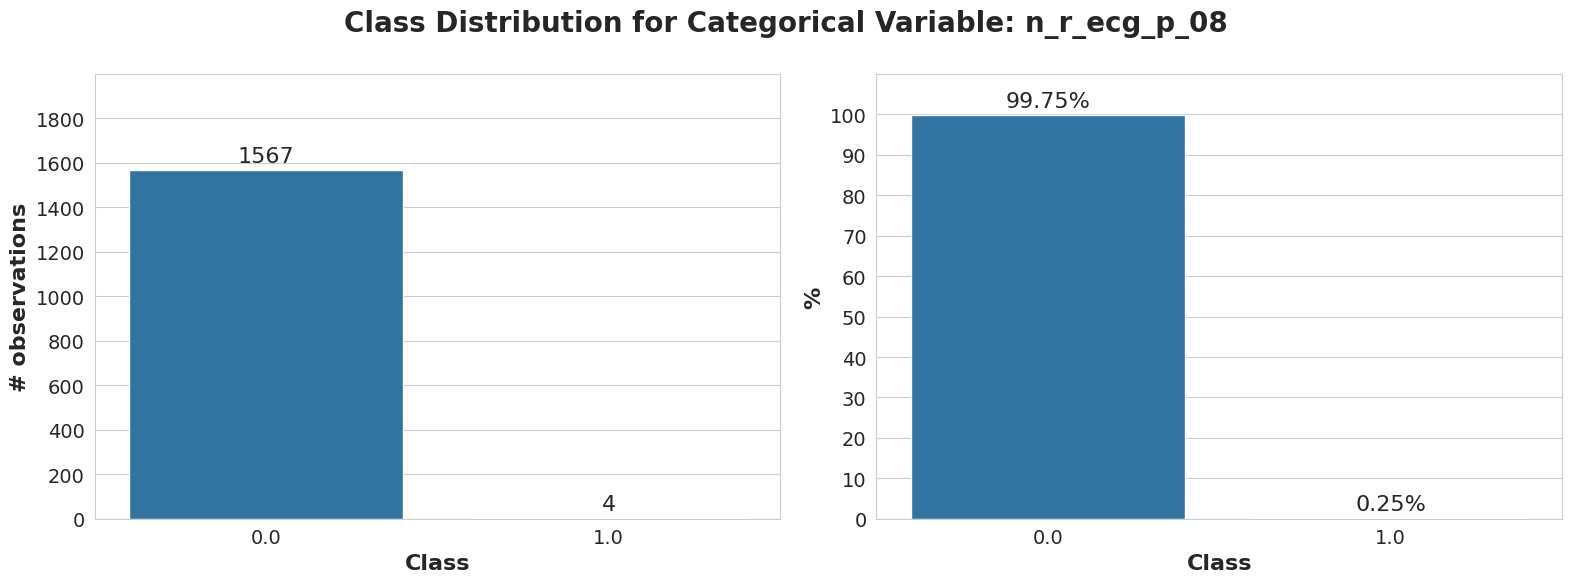

[SAVED] /home/leonardosaccotelli/Desktop/UNIVERSITA/MACHINE-LEARNING/Cost-Sensitive-Learning-For-Myocardial-Infarction-Mortality-Prediction/reports/figures/DP_data_exploration_cleaned/class_distribution_absolute_vs_percentage_n_r_ecg_p_09.png


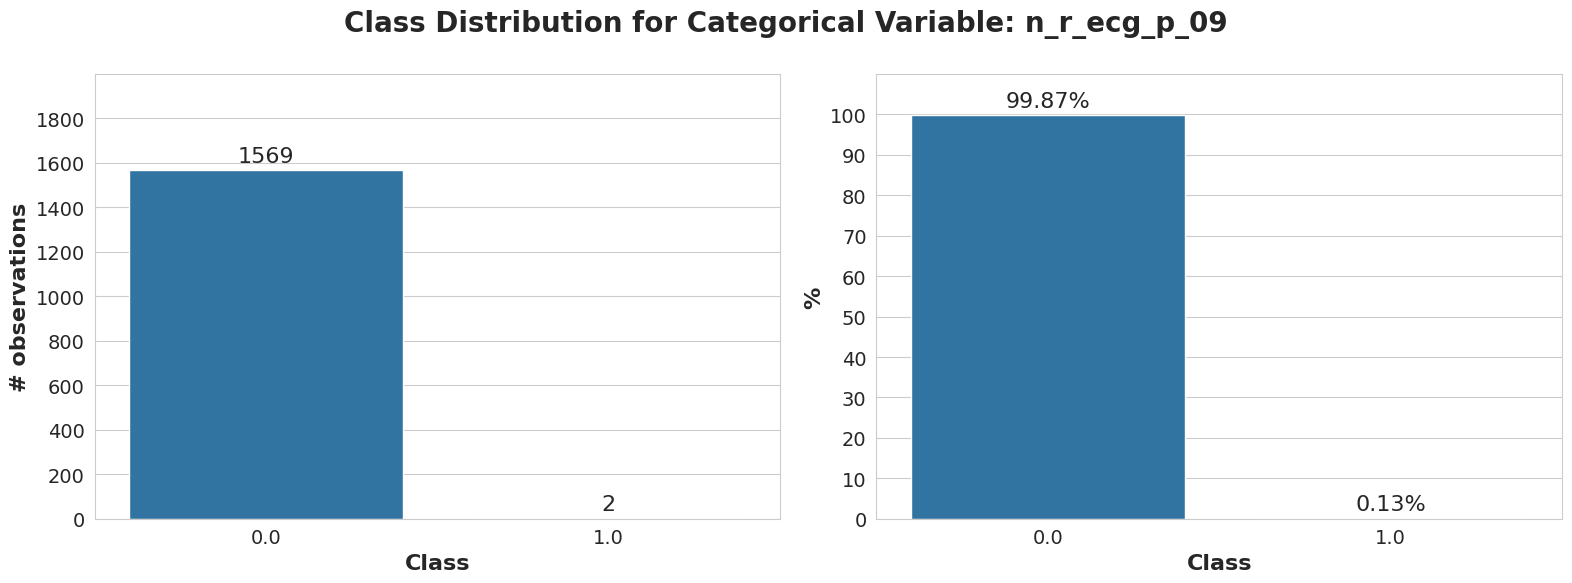

[SAVED] /home/leonardosaccotelli/Desktop/UNIVERSITA/MACHINE-LEARNING/Cost-Sensitive-Learning-For-Myocardial-Infarction-Mortality-Prediction/reports/figures/DP_data_exploration_cleaned/class_distribution_absolute_vs_percentage_n_r_ecg_p_10.png


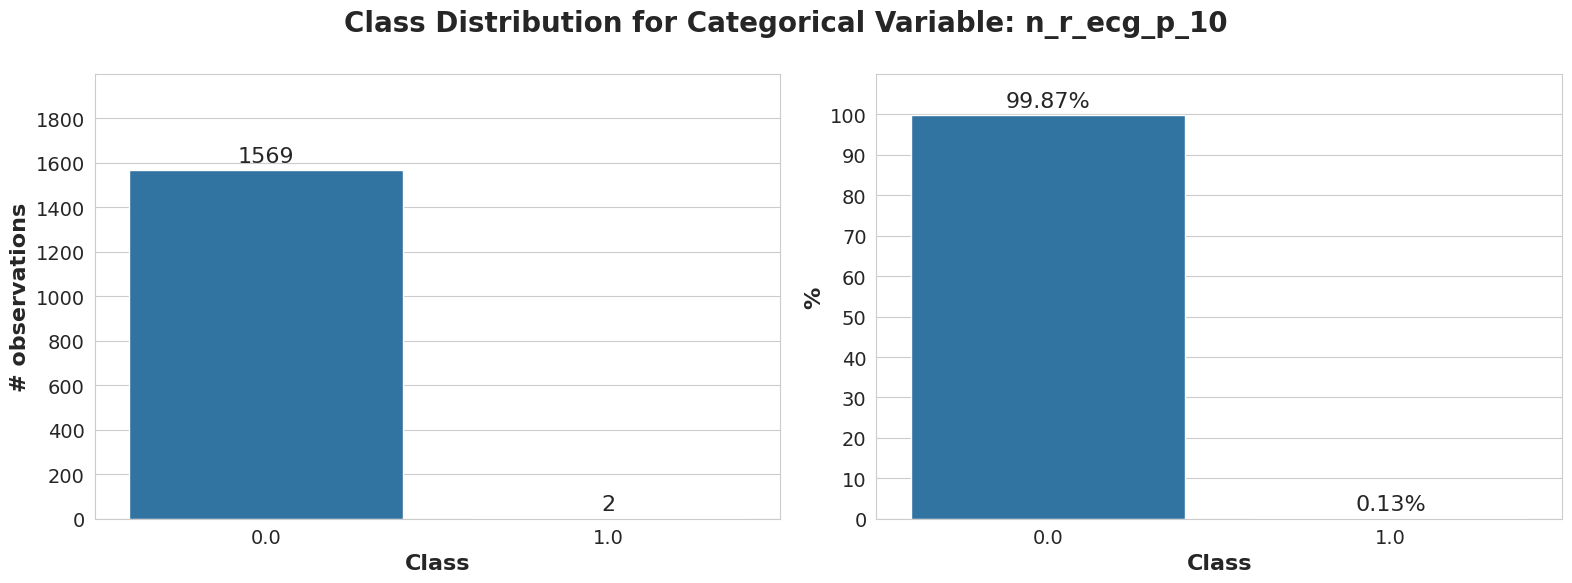

[SAVED] /home/leonardosaccotelli/Desktop/UNIVERSITA/MACHINE-LEARNING/Cost-Sensitive-Learning-For-Myocardial-Infarction-Mortality-Prediction/reports/figures/DP_data_exploration_cleaned/class_distribution_absolute_vs_percentage_n_p_ecg_p_01.png


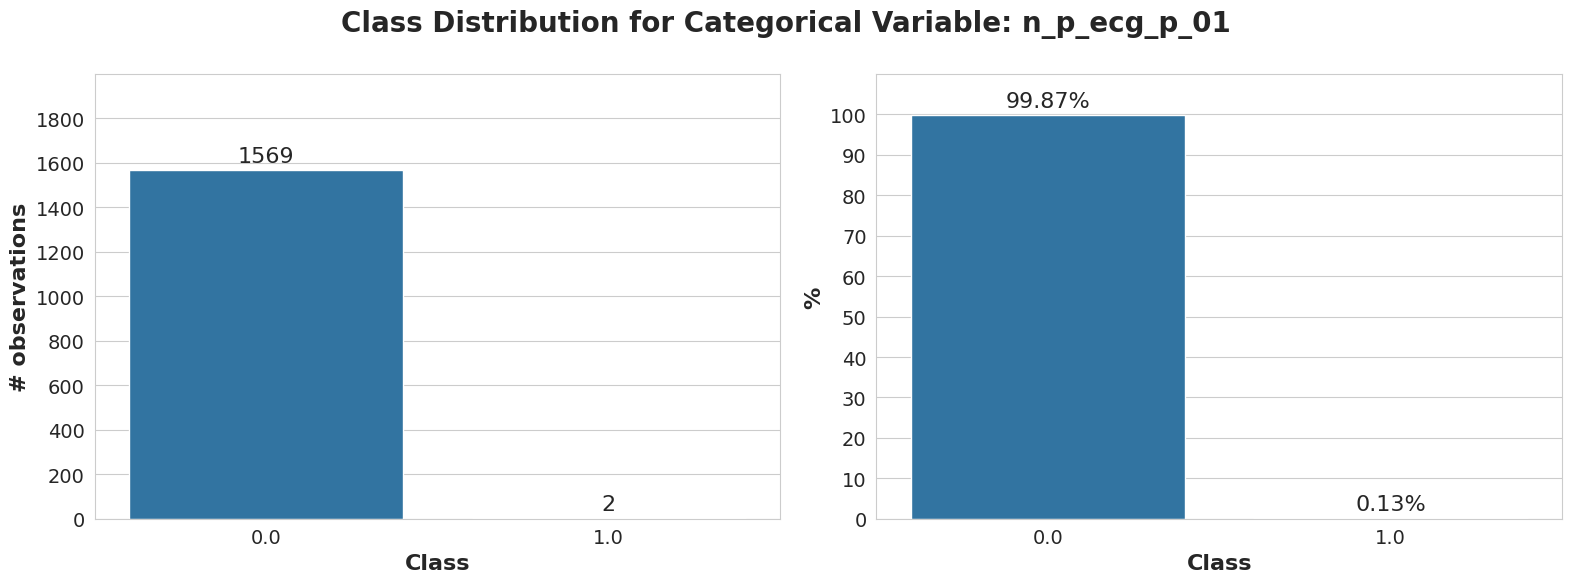

[SAVED] /home/leonardosaccotelli/Desktop/UNIVERSITA/MACHINE-LEARNING/Cost-Sensitive-Learning-For-Myocardial-Infarction-Mortality-Prediction/reports/figures/DP_data_exploration_cleaned/class_distribution_absolute_vs_percentage_n_p_ecg_p_03.png


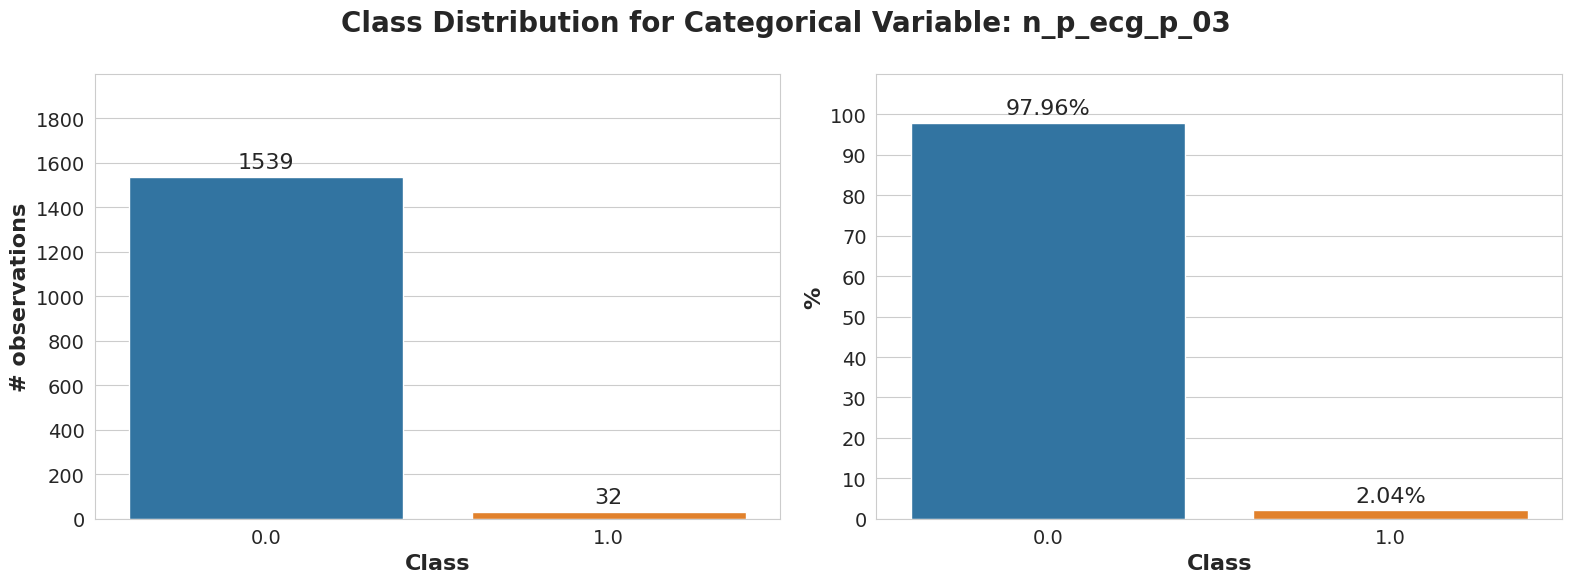

[SAVED] /home/leonardosaccotelli/Desktop/UNIVERSITA/MACHINE-LEARNING/Cost-Sensitive-Learning-For-Myocardial-Infarction-Mortality-Prediction/reports/figures/DP_data_exploration_cleaned/class_distribution_absolute_vs_percentage_n_p_ecg_p_04.png


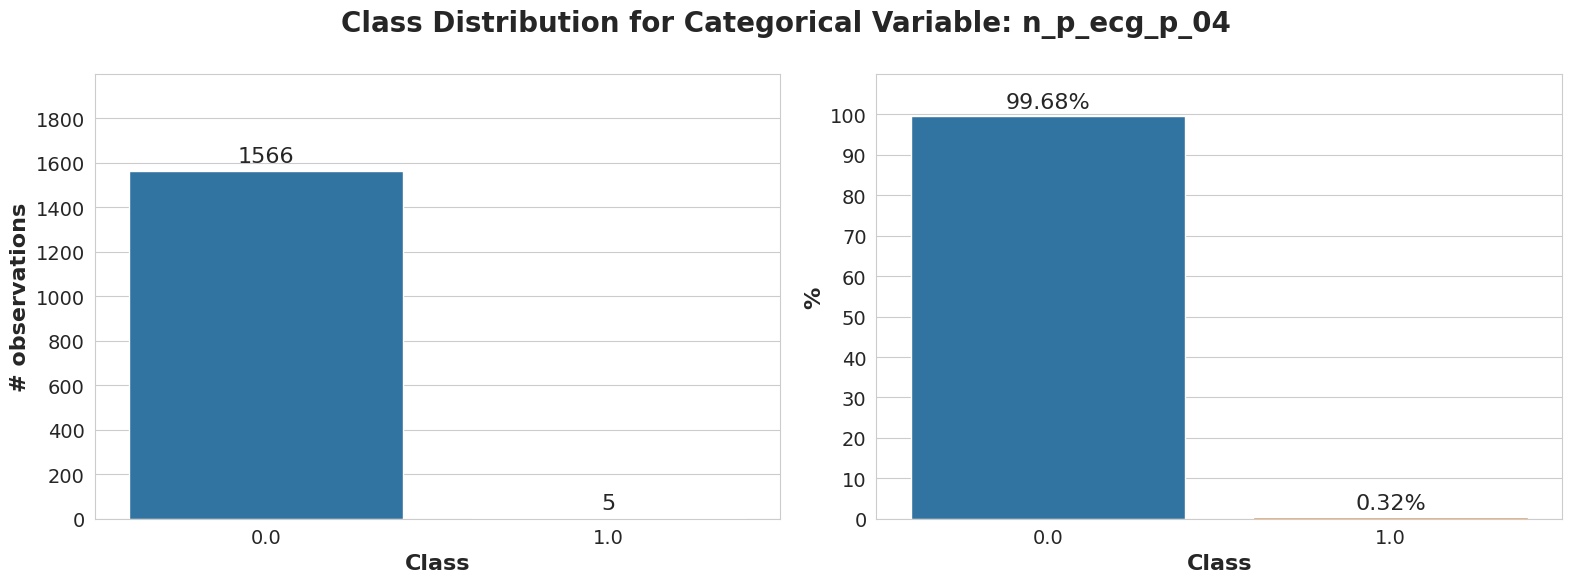

[SAVED] /home/leonardosaccotelli/Desktop/UNIVERSITA/MACHINE-LEARNING/Cost-Sensitive-Learning-For-Myocardial-Infarction-Mortality-Prediction/reports/figures/DP_data_exploration_cleaned/class_distribution_absolute_vs_percentage_n_p_ecg_p_05.png


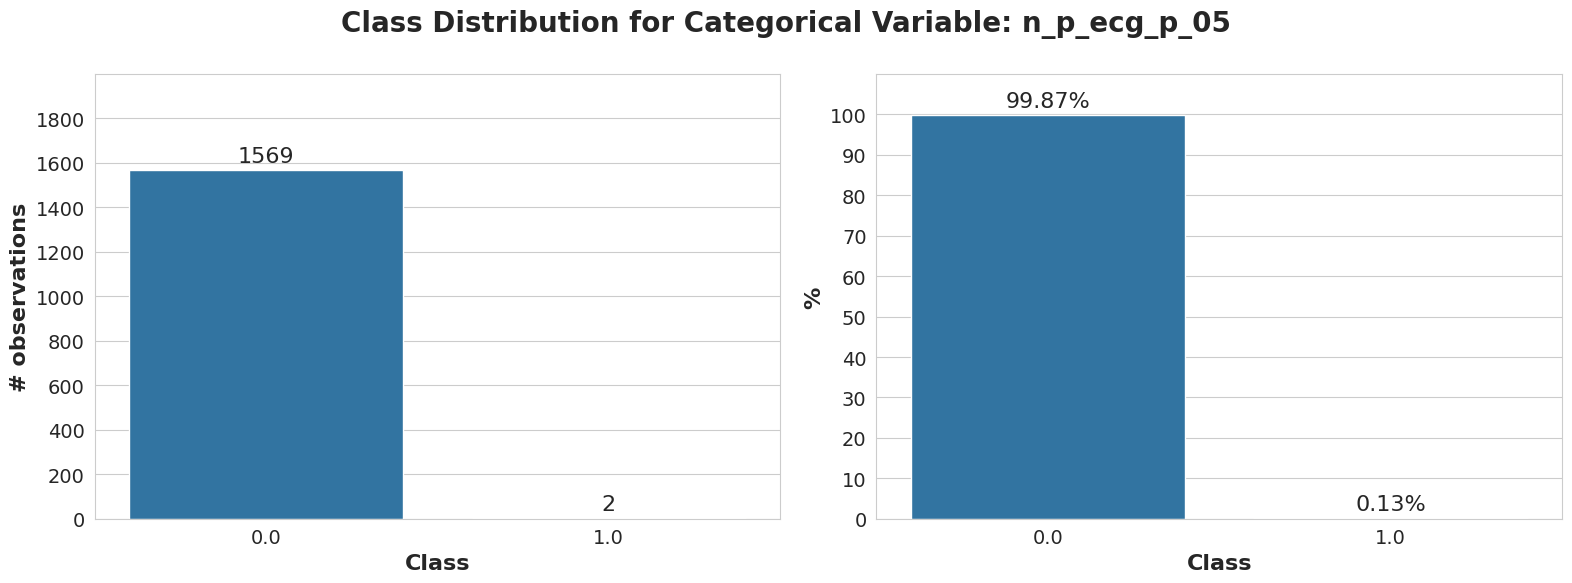

[SAVED] /home/leonardosaccotelli/Desktop/UNIVERSITA/MACHINE-LEARNING/Cost-Sensitive-Learning-For-Myocardial-Infarction-Mortality-Prediction/reports/figures/DP_data_exploration_cleaned/class_distribution_absolute_vs_percentage_n_p_ecg_p_06.png


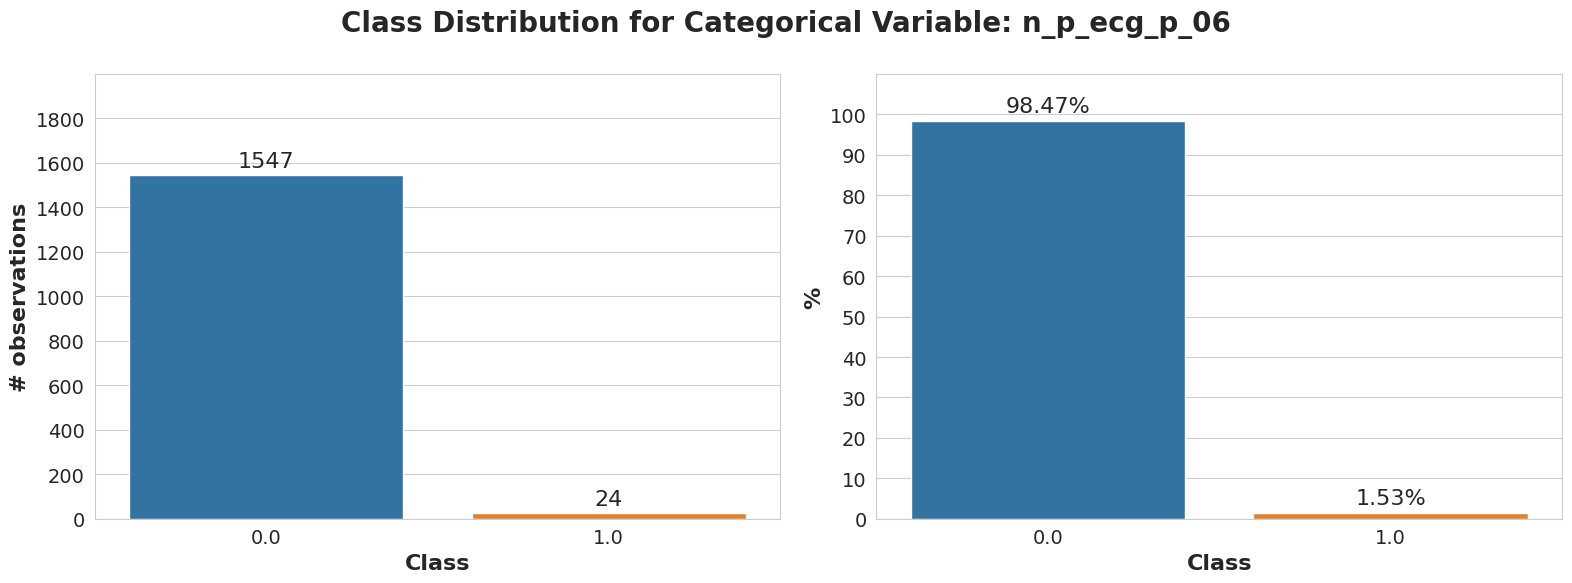

[SAVED] /home/leonardosaccotelli/Desktop/UNIVERSITA/MACHINE-LEARNING/Cost-Sensitive-Learning-For-Myocardial-Infarction-Mortality-Prediction/reports/figures/DP_data_exploration_cleaned/class_distribution_absolute_vs_percentage_n_p_ecg_p_07.png


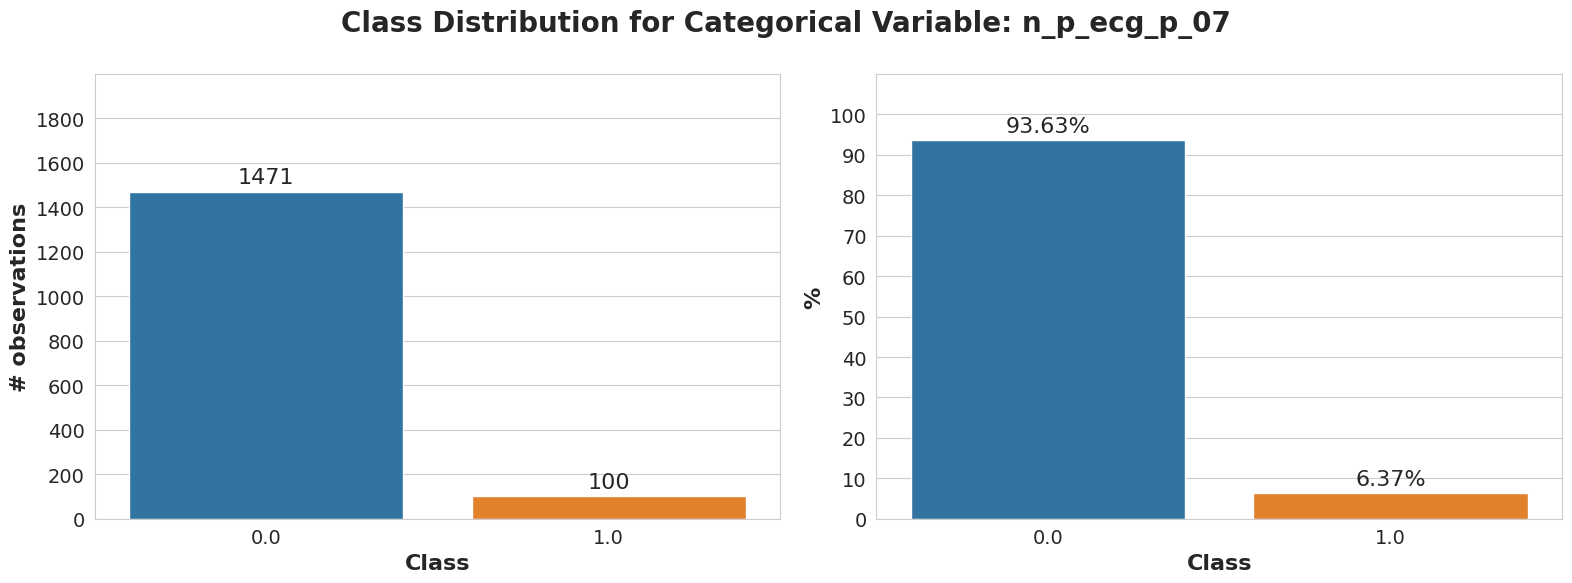

[SAVED] /home/leonardosaccotelli/Desktop/UNIVERSITA/MACHINE-LEARNING/Cost-Sensitive-Learning-For-Myocardial-Infarction-Mortality-Prediction/reports/figures/DP_data_exploration_cleaned/class_distribution_absolute_vs_percentage_n_p_ecg_p_08.png


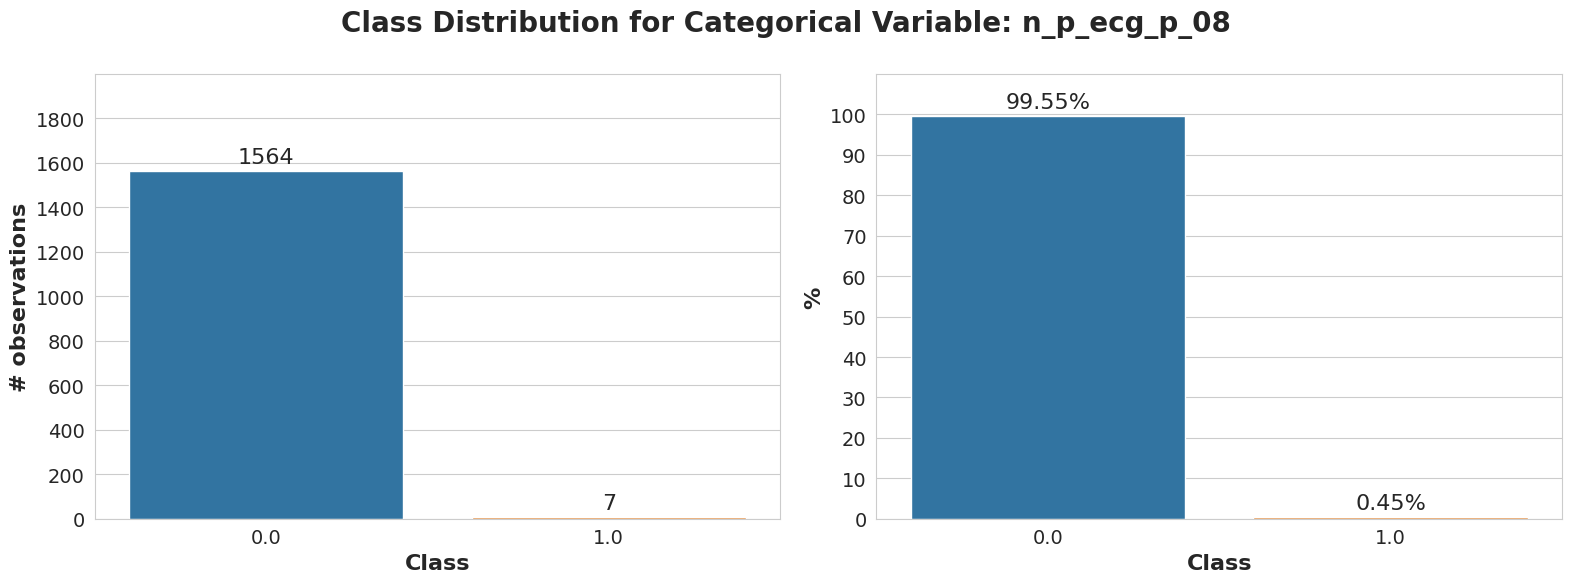

[SAVED] /home/leonardosaccotelli/Desktop/UNIVERSITA/MACHINE-LEARNING/Cost-Sensitive-Learning-For-Myocardial-Infarction-Mortality-Prediction/reports/figures/DP_data_exploration_cleaned/class_distribution_absolute_vs_percentage_n_p_ecg_p_09.png


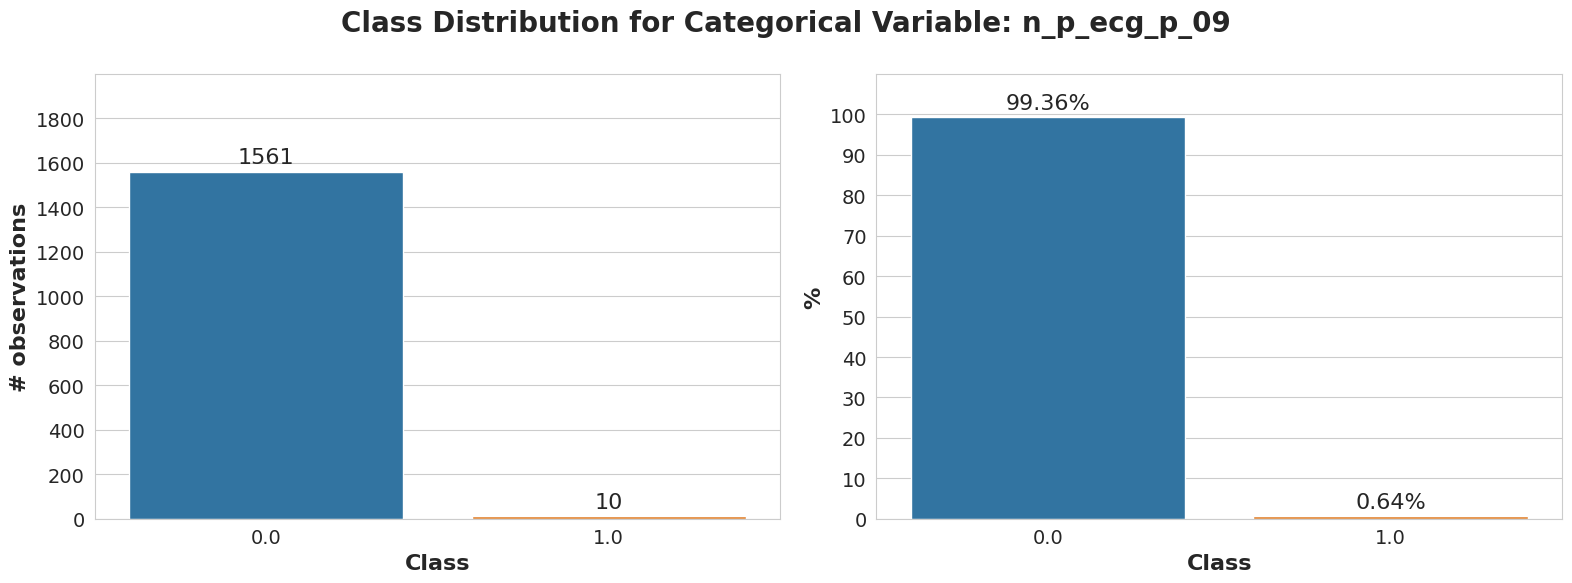

[SAVED] /home/leonardosaccotelli/Desktop/UNIVERSITA/MACHINE-LEARNING/Cost-Sensitive-Learning-For-Myocardial-Infarction-Mortality-Prediction/reports/figures/DP_data_exploration_cleaned/class_distribution_absolute_vs_percentage_n_p_ecg_p_10.png


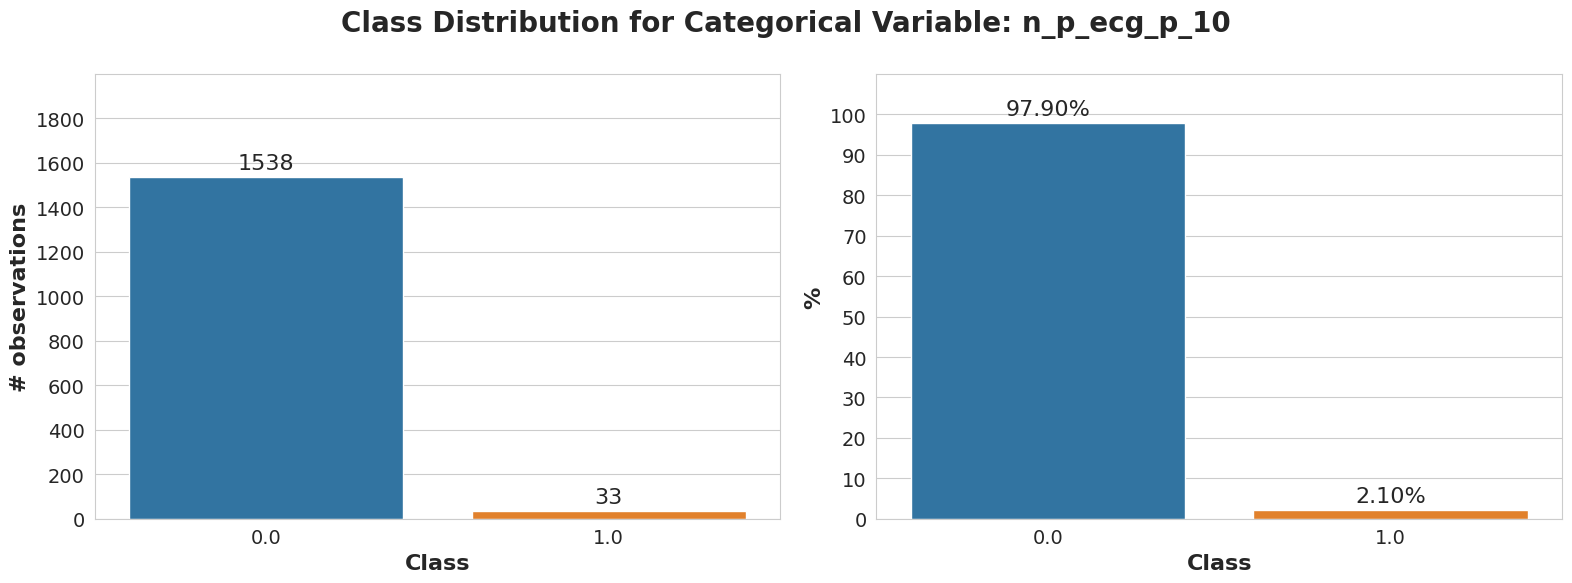

[SAVED] /home/leonardosaccotelli/Desktop/UNIVERSITA/MACHINE-LEARNING/Cost-Sensitive-Learning-For-Myocardial-Infarction-Mortality-Prediction/reports/figures/DP_data_exploration_cleaned/class_distribution_absolute_vs_percentage_n_p_ecg_p_11.png


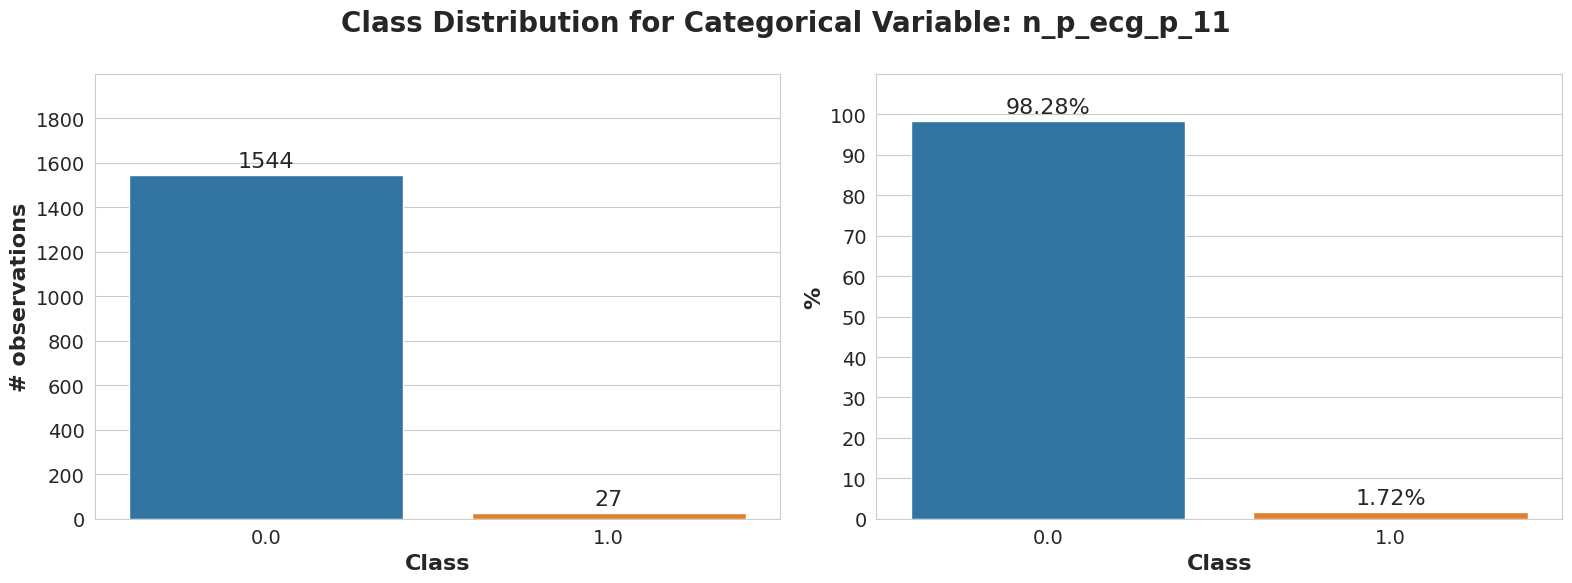

[SAVED] /home/leonardosaccotelli/Desktop/UNIVERSITA/MACHINE-LEARNING/Cost-Sensitive-Learning-For-Myocardial-Infarction-Mortality-Prediction/reports/figures/DP_data_exploration_cleaned/class_distribution_absolute_vs_percentage_n_p_ecg_p_12.png


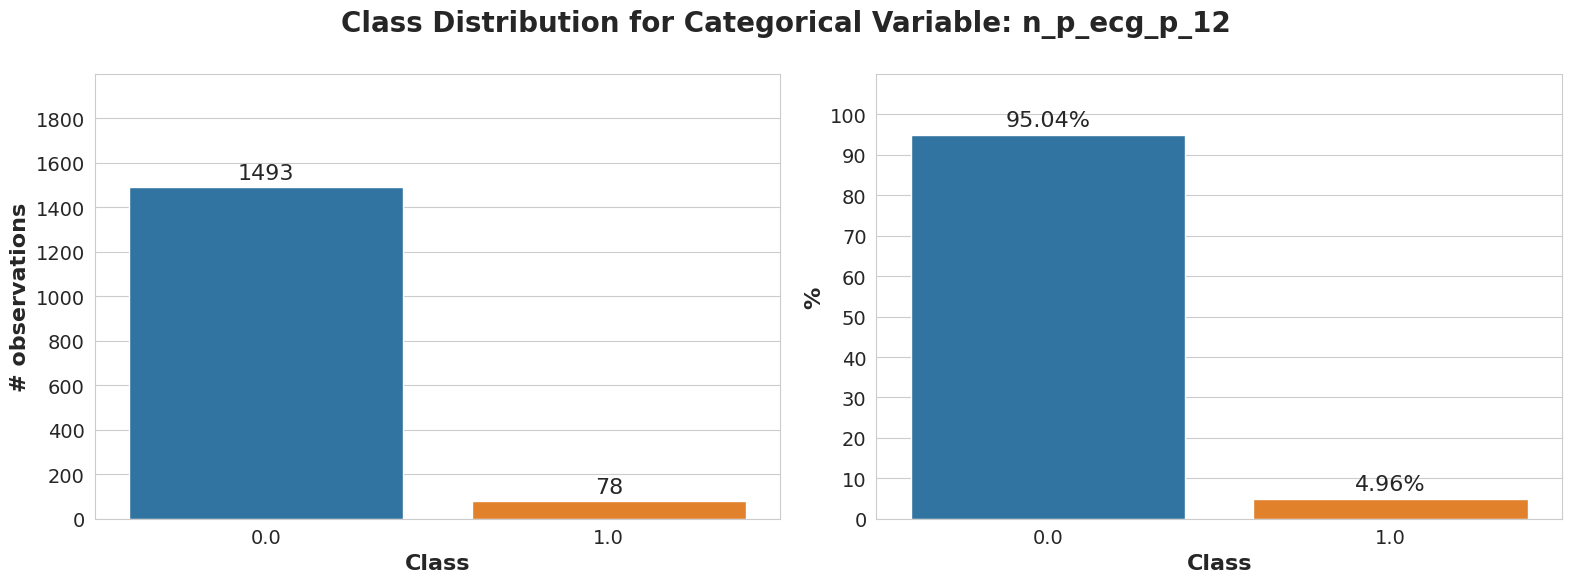

[SAVED] /home/leonardosaccotelli/Desktop/UNIVERSITA/MACHINE-LEARNING/Cost-Sensitive-Learning-For-Myocardial-Infarction-Mortality-Prediction/reports/figures/DP_data_exploration_cleaned/class_distribution_absolute_vs_percentage_fibr_ter_01.png


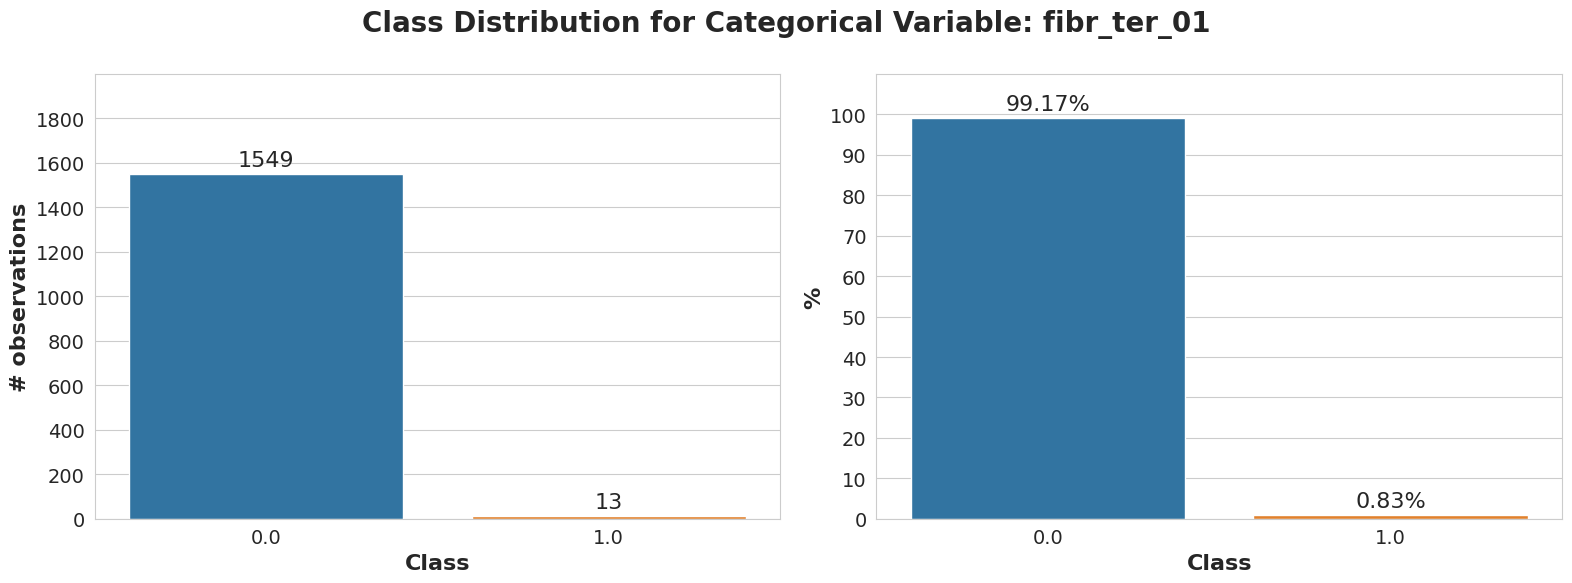

[SAVED] /home/leonardosaccotelli/Desktop/UNIVERSITA/MACHINE-LEARNING/Cost-Sensitive-Learning-For-Myocardial-Infarction-Mortality-Prediction/reports/figures/DP_data_exploration_cleaned/class_distribution_absolute_vs_percentage_fibr_ter_02.png


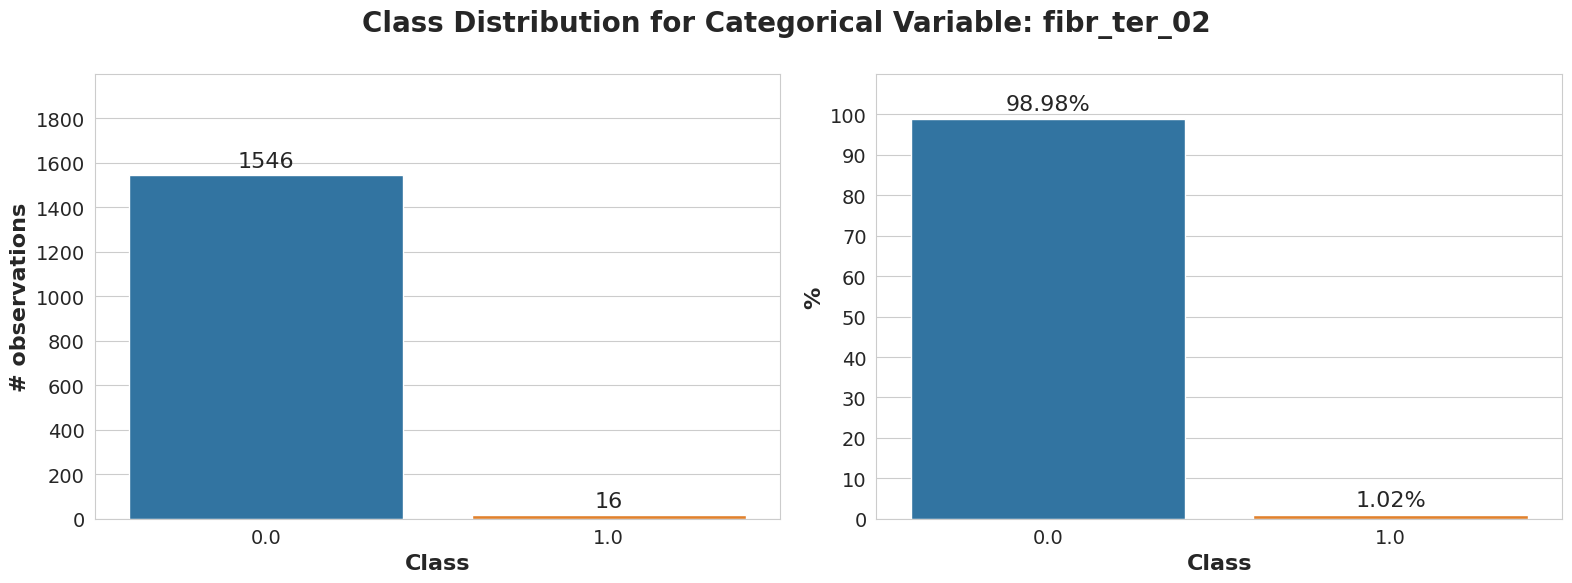

[SAVED] /home/leonardosaccotelli/Desktop/UNIVERSITA/MACHINE-LEARNING/Cost-Sensitive-Learning-For-Myocardial-Infarction-Mortality-Prediction/reports/figures/DP_data_exploration_cleaned/class_distribution_absolute_vs_percentage_fibr_ter_03.png


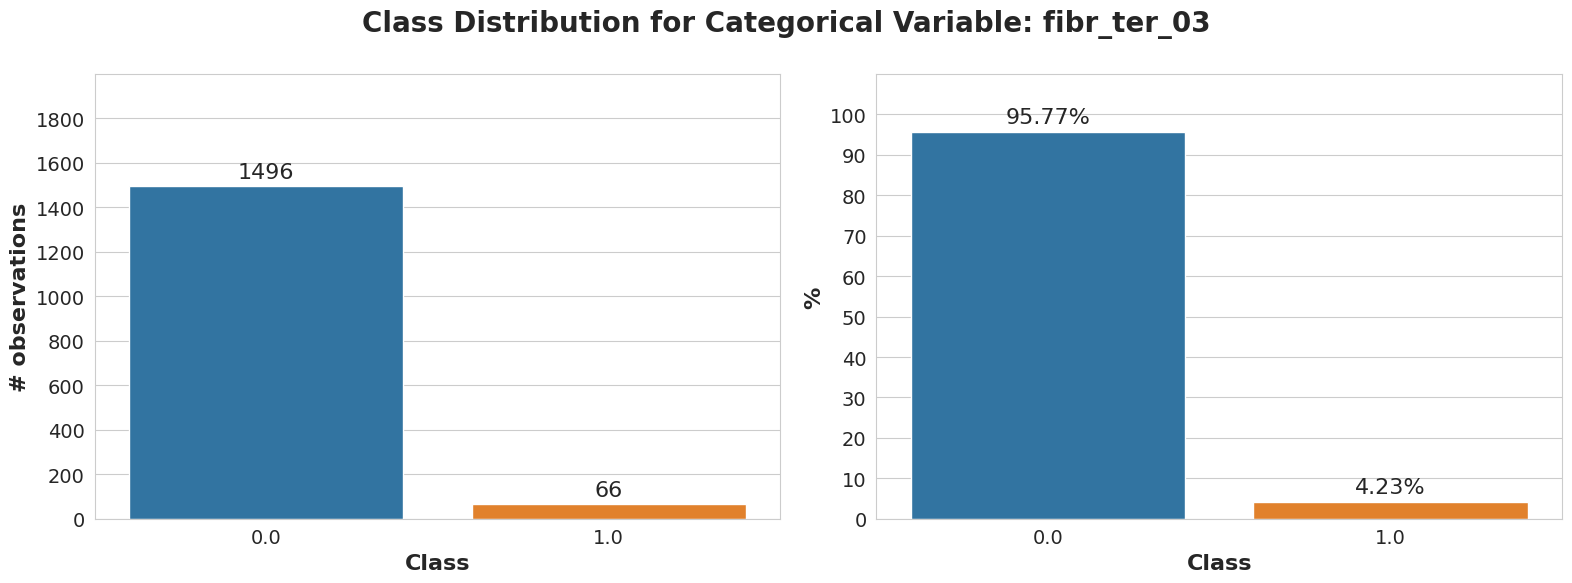

[SAVED] /home/leonardosaccotelli/Desktop/UNIVERSITA/MACHINE-LEARNING/Cost-Sensitive-Learning-For-Myocardial-Infarction-Mortality-Prediction/reports/figures/DP_data_exploration_cleaned/class_distribution_absolute_vs_percentage_fibr_ter_05.png


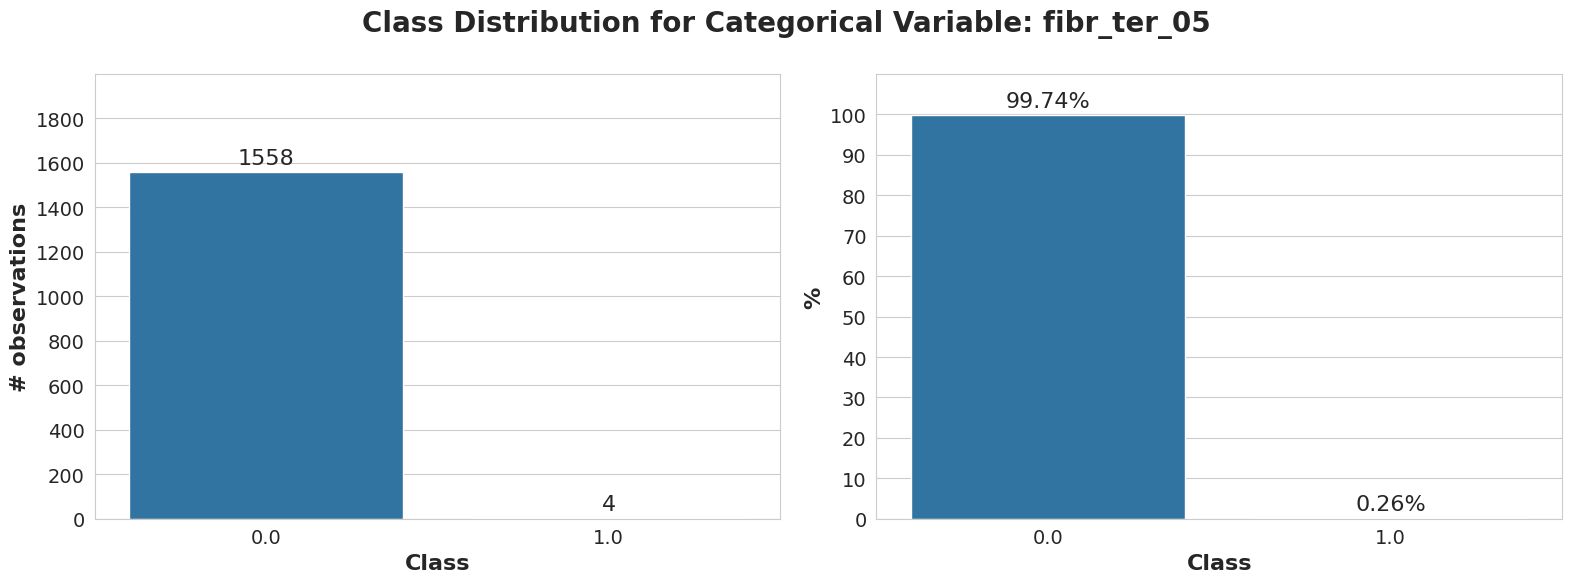

[SAVED] /home/leonardosaccotelli/Desktop/UNIVERSITA/MACHINE-LEARNING/Cost-Sensitive-Learning-For-Myocardial-Infarction-Mortality-Prediction/reports/figures/DP_data_exploration_cleaned/class_distribution_absolute_vs_percentage_fibr_ter_06.png


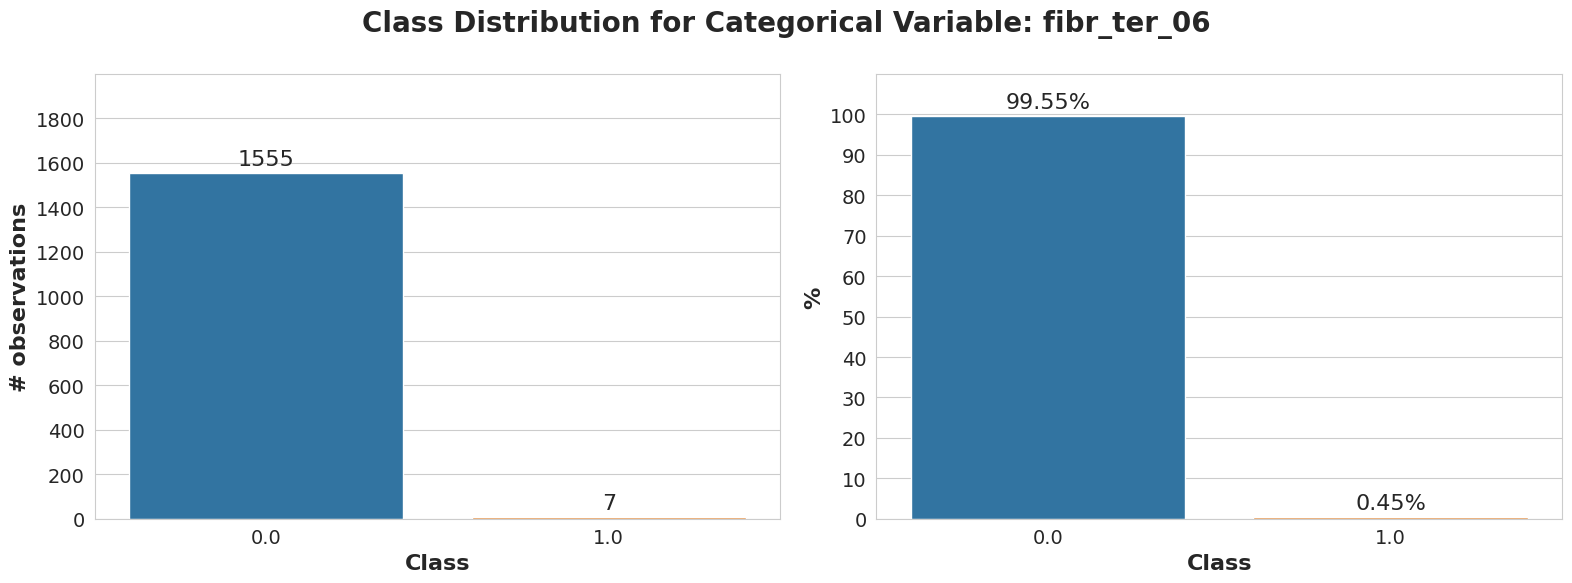

[SAVED] /home/leonardosaccotelli/Desktop/UNIVERSITA/MACHINE-LEARNING/Cost-Sensitive-Learning-For-Myocardial-Infarction-Mortality-Prediction/reports/figures/DP_data_exploration_cleaned/class_distribution_absolute_vs_percentage_fibr_ter_07.png


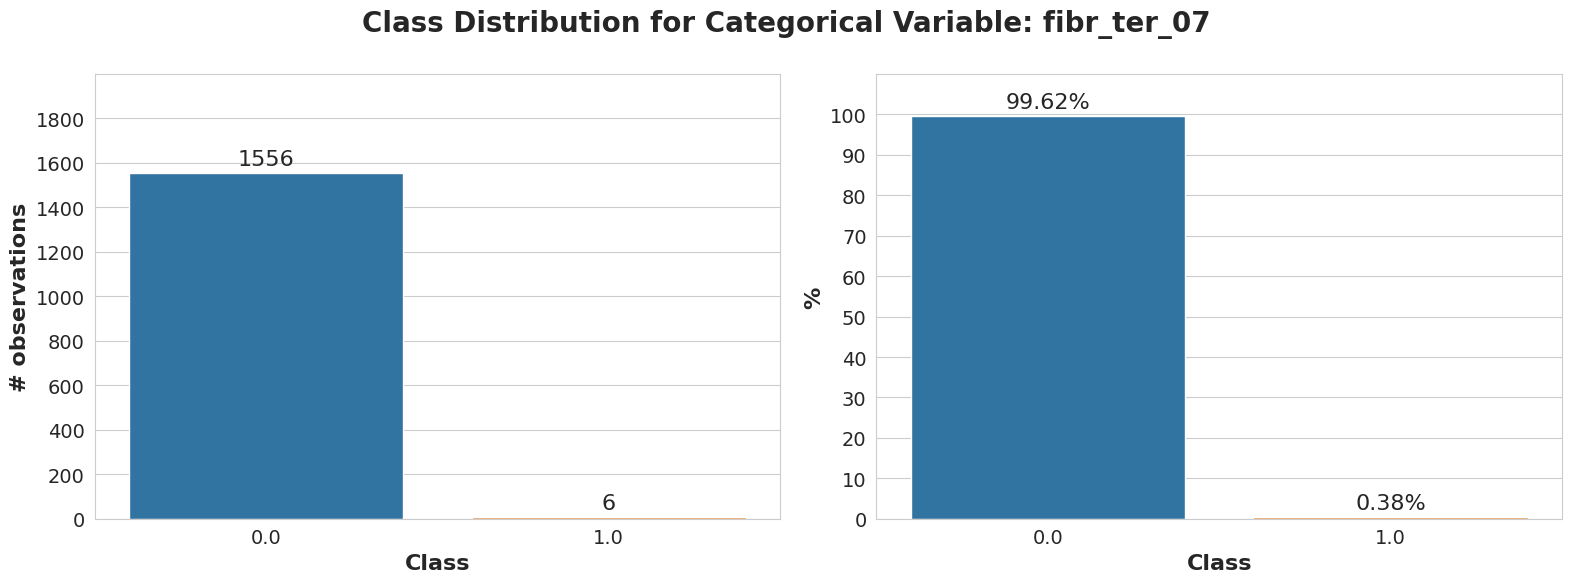

[SAVED] /home/leonardosaccotelli/Desktop/UNIVERSITA/MACHINE-LEARNING/Cost-Sensitive-Learning-For-Myocardial-Infarction-Mortality-Prediction/reports/figures/DP_data_exploration_cleaned/class_distribution_absolute_vs_percentage_fibr_ter_08.png


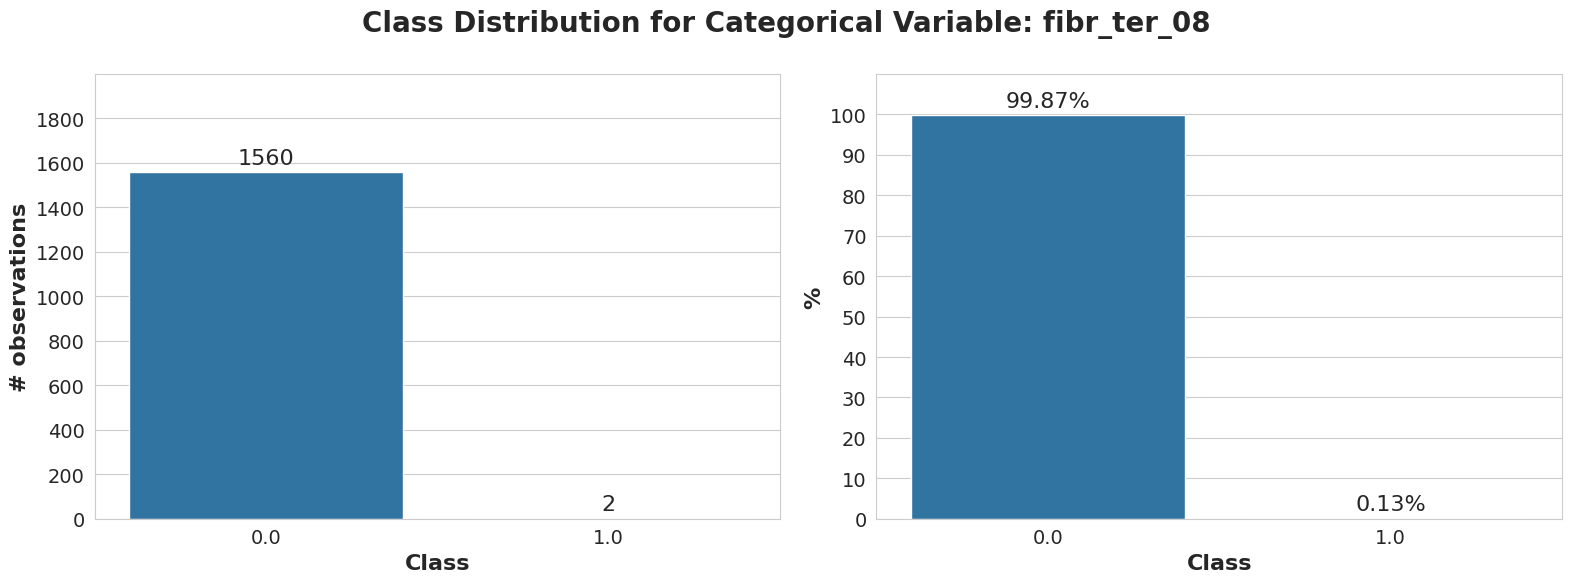

[SAVED] /home/leonardosaccotelli/Desktop/UNIVERSITA/MACHINE-LEARNING/Cost-Sensitive-Learning-For-Myocardial-Infarction-Mortality-Prediction/reports/figures/DP_data_exploration_cleaned/class_distribution_absolute_vs_percentage_GIPO_K.png


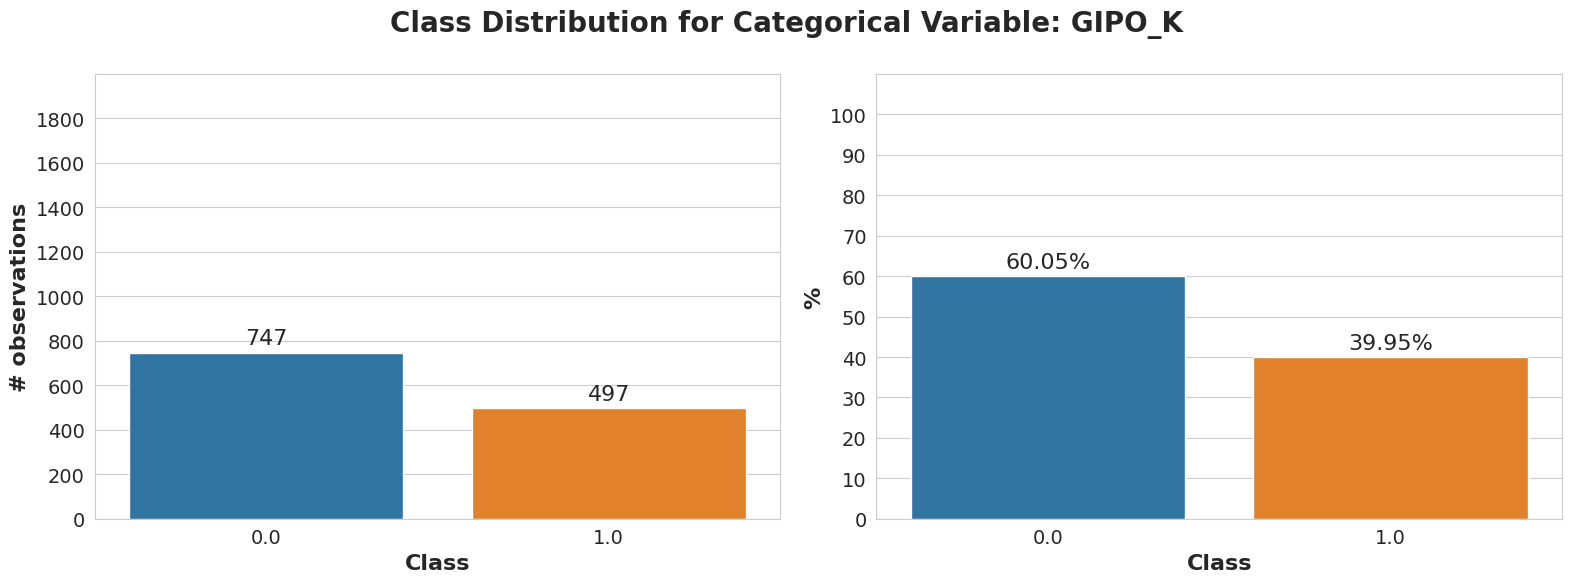

[SAVED] /home/leonardosaccotelli/Desktop/UNIVERSITA/MACHINE-LEARNING/Cost-Sensitive-Learning-For-Myocardial-Infarction-Mortality-Prediction/reports/figures/DP_data_exploration_cleaned/class_distribution_absolute_vs_percentage_GIPER_NA.png


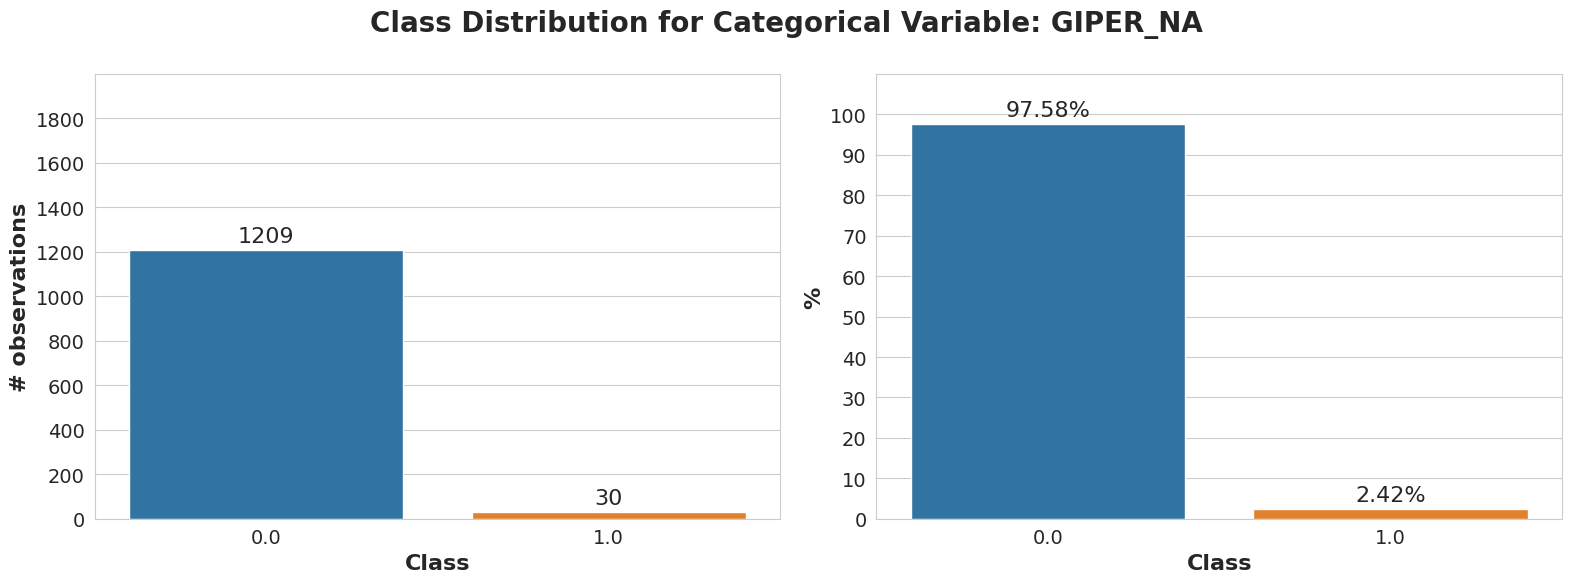

[SAVED] /home/leonardosaccotelli/Desktop/UNIVERSITA/MACHINE-LEARNING/Cost-Sensitive-Learning-For-Myocardial-Infarction-Mortality-Prediction/reports/figures/DP_data_exploration_cleaned/class_distribution_absolute_vs_percentage_NITR_S.png


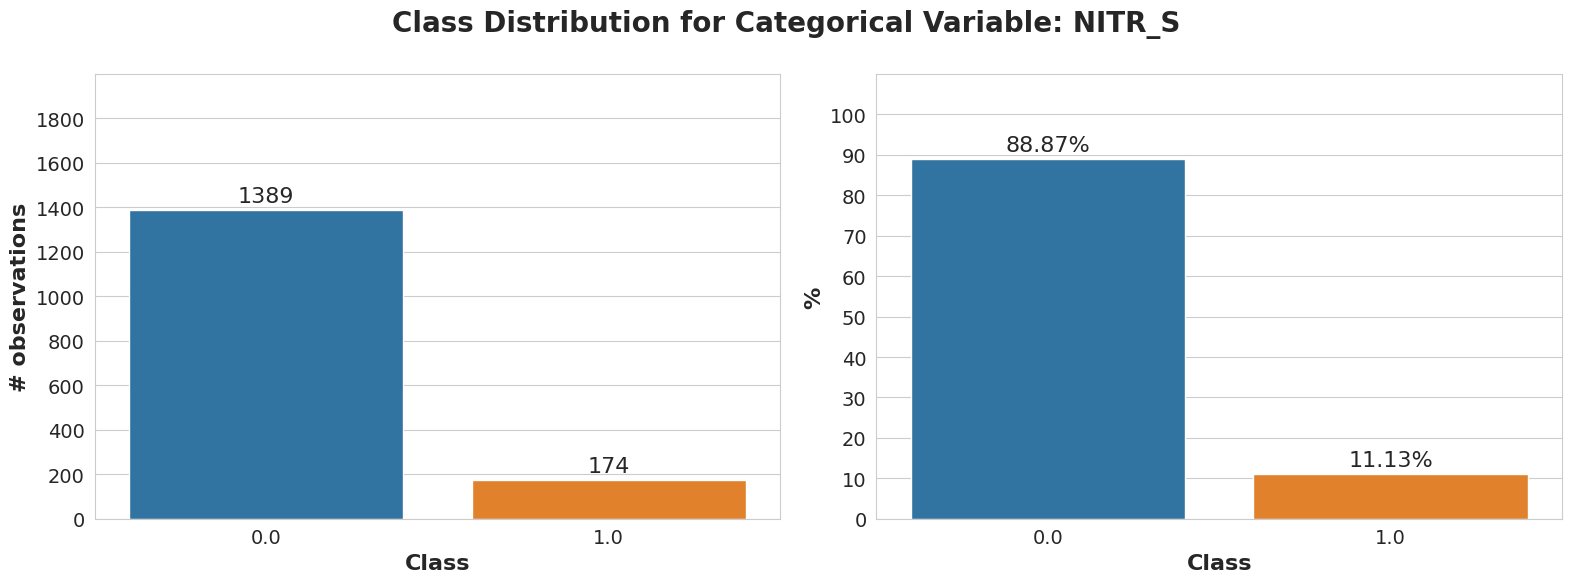

[SAVED] /home/leonardosaccotelli/Desktop/UNIVERSITA/MACHINE-LEARNING/Cost-Sensitive-Learning-For-Myocardial-Infarction-Mortality-Prediction/reports/figures/DP_data_exploration_cleaned/class_distribution_absolute_vs_percentage_LID_S_n.png


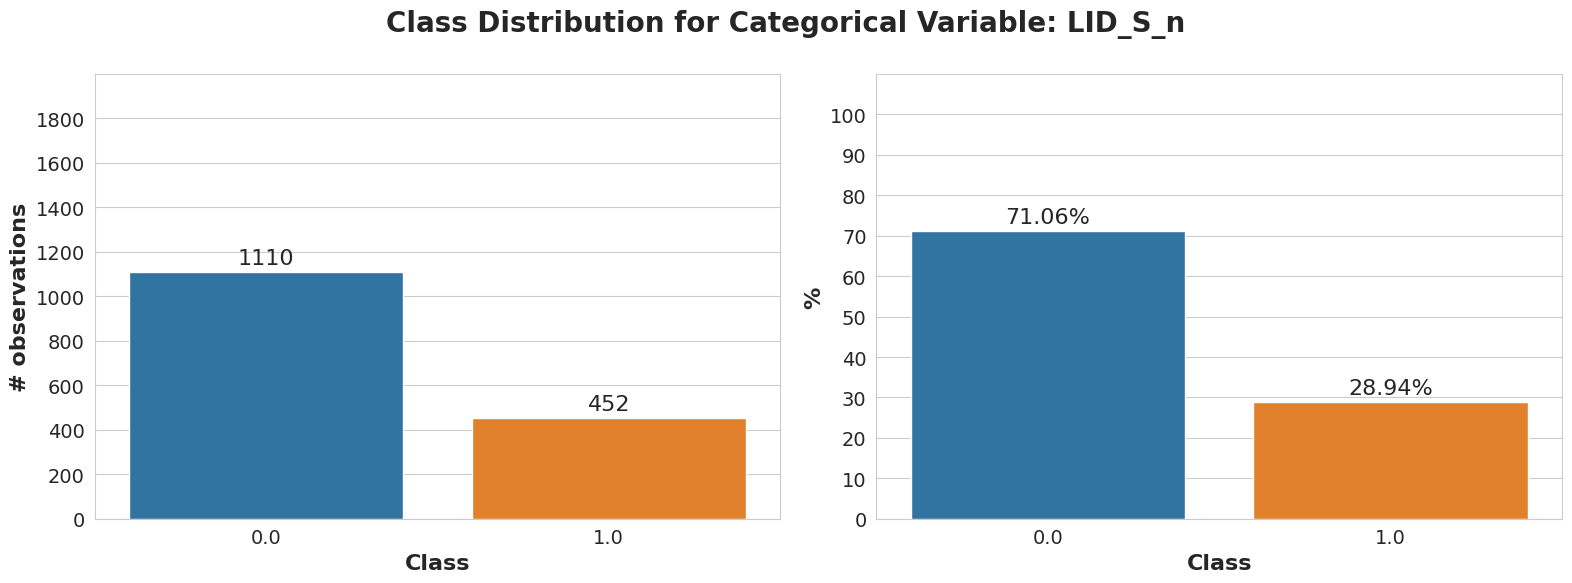

[SAVED] /home/leonardosaccotelli/Desktop/UNIVERSITA/MACHINE-LEARNING/Cost-Sensitive-Learning-For-Myocardial-Infarction-Mortality-Prediction/reports/figures/DP_data_exploration_cleaned/class_distribution_absolute_vs_percentage_B_BLOK_S_n.png


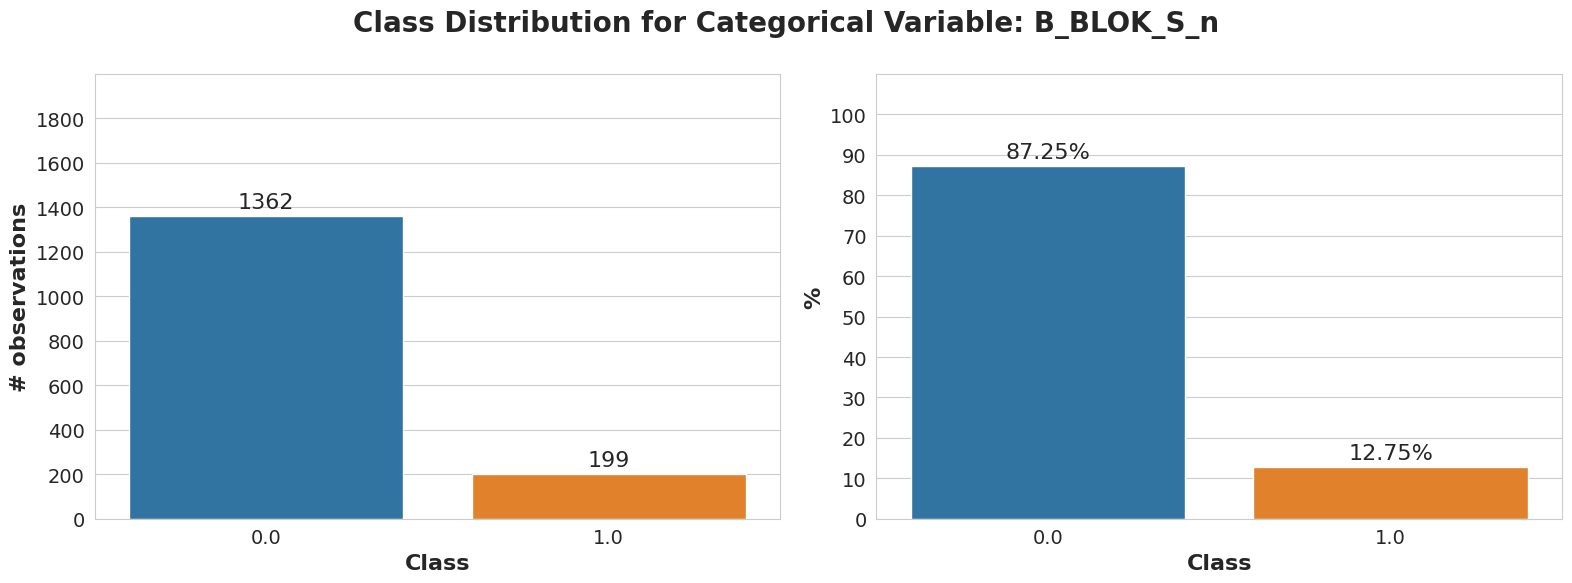

[SAVED] /home/leonardosaccotelli/Desktop/UNIVERSITA/MACHINE-LEARNING/Cost-Sensitive-Learning-For-Myocardial-Infarction-Mortality-Prediction/reports/figures/DP_data_exploration_cleaned/class_distribution_absolute_vs_percentage_ANT_CA_S_n.png


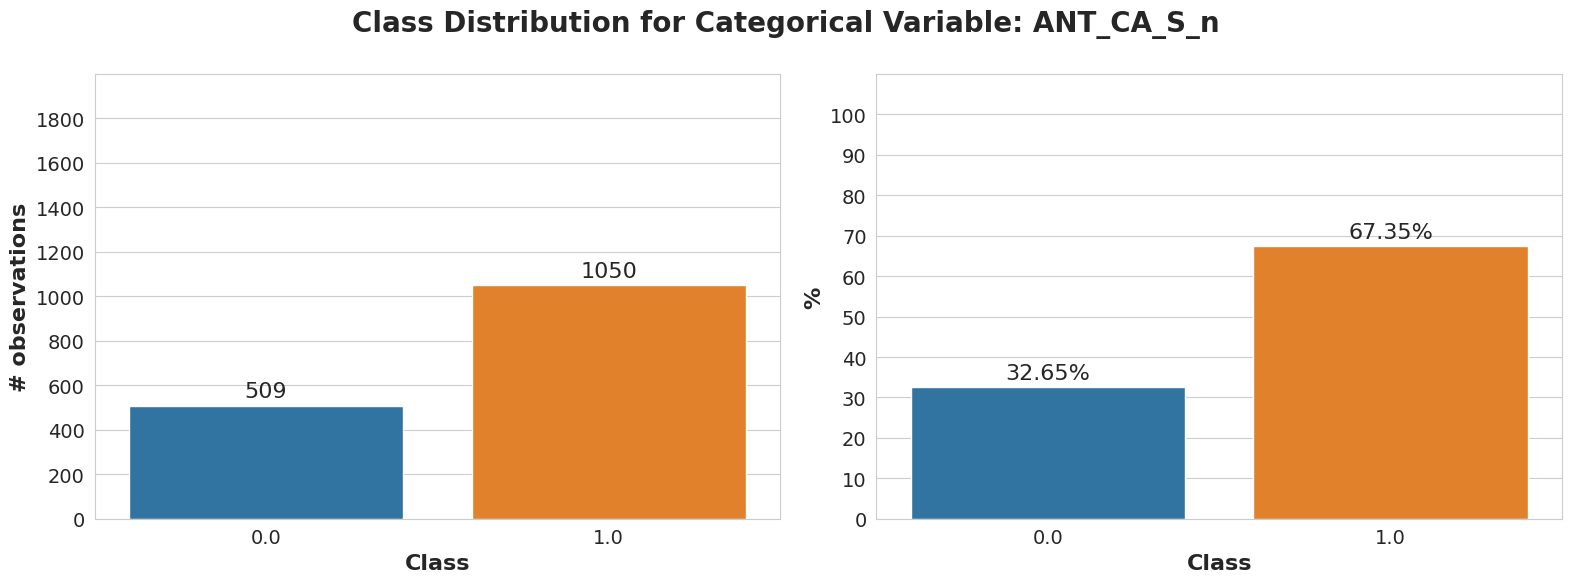

[SAVED] /home/leonardosaccotelli/Desktop/UNIVERSITA/MACHINE-LEARNING/Cost-Sensitive-Learning-For-Myocardial-Infarction-Mortality-Prediction/reports/figures/DP_data_exploration_cleaned/class_distribution_absolute_vs_percentage_GEPAR_S_n.png


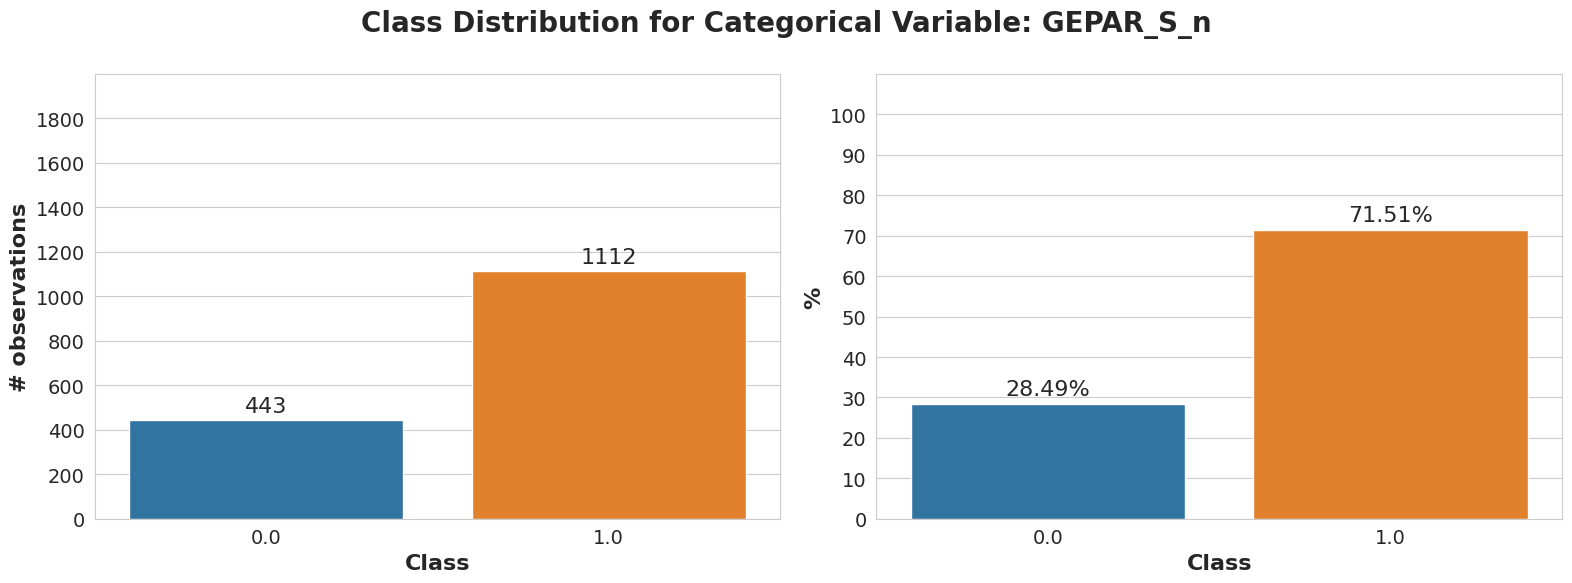

[SAVED] /home/leonardosaccotelli/Desktop/UNIVERSITA/MACHINE-LEARNING/Cost-Sensitive-Learning-For-Myocardial-Infarction-Mortality-Prediction/reports/figures/DP_data_exploration_cleaned/class_distribution_absolute_vs_percentage_ASP_S_n.png


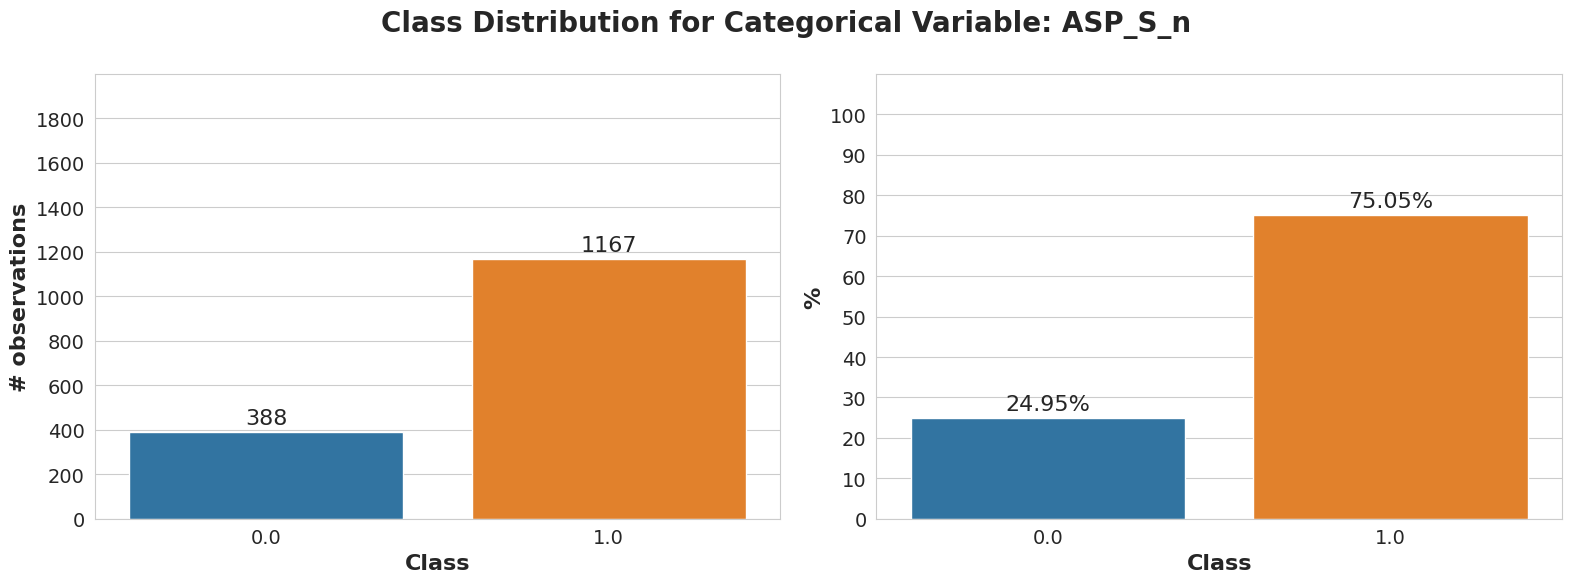

[SAVED] /home/leonardosaccotelli/Desktop/UNIVERSITA/MACHINE-LEARNING/Cost-Sensitive-Learning-For-Myocardial-Infarction-Mortality-Prediction/reports/figures/DP_data_exploration_cleaned/class_distribution_absolute_vs_percentage_TIKL_S_n.png


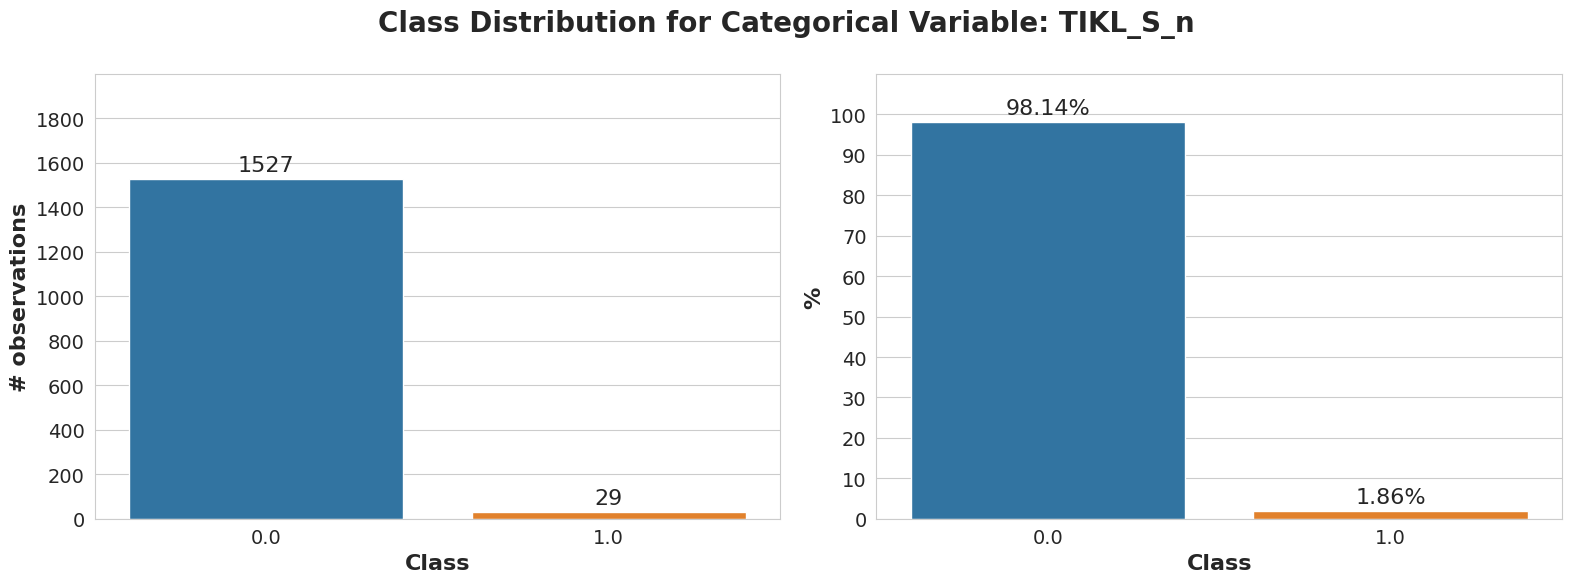

[SAVED] /home/leonardosaccotelli/Desktop/UNIVERSITA/MACHINE-LEARNING/Cost-Sensitive-Learning-For-Myocardial-Infarction-Mortality-Prediction/reports/figures/DP_data_exploration_cleaned/class_distribution_absolute_vs_percentage_TRENT_S_n.png


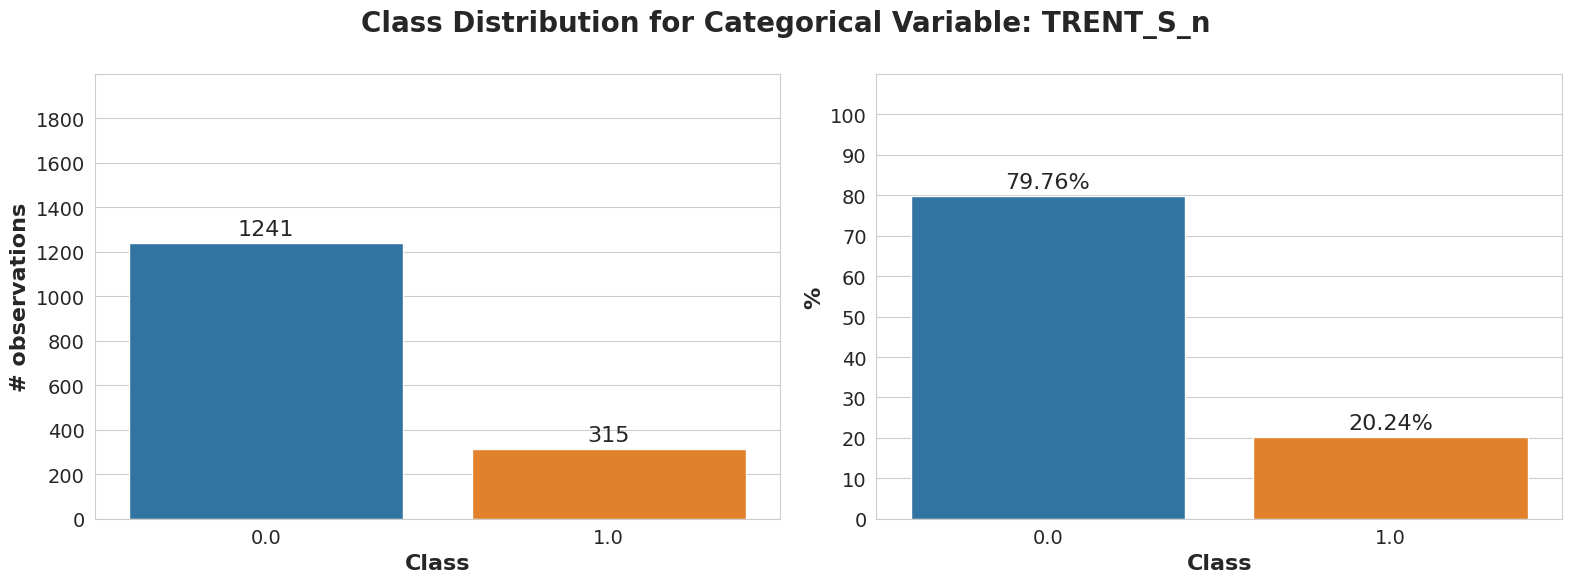

[SAVED] /home/leonardosaccotelli/Desktop/UNIVERSITA/MACHINE-LEARNING/Cost-Sensitive-Learning-For-Myocardial-Infarction-Mortality-Prediction/reports/figures/DP_data_exploration_cleaned/class_distribution_absolute_vs_percentage_IBS_POST.png


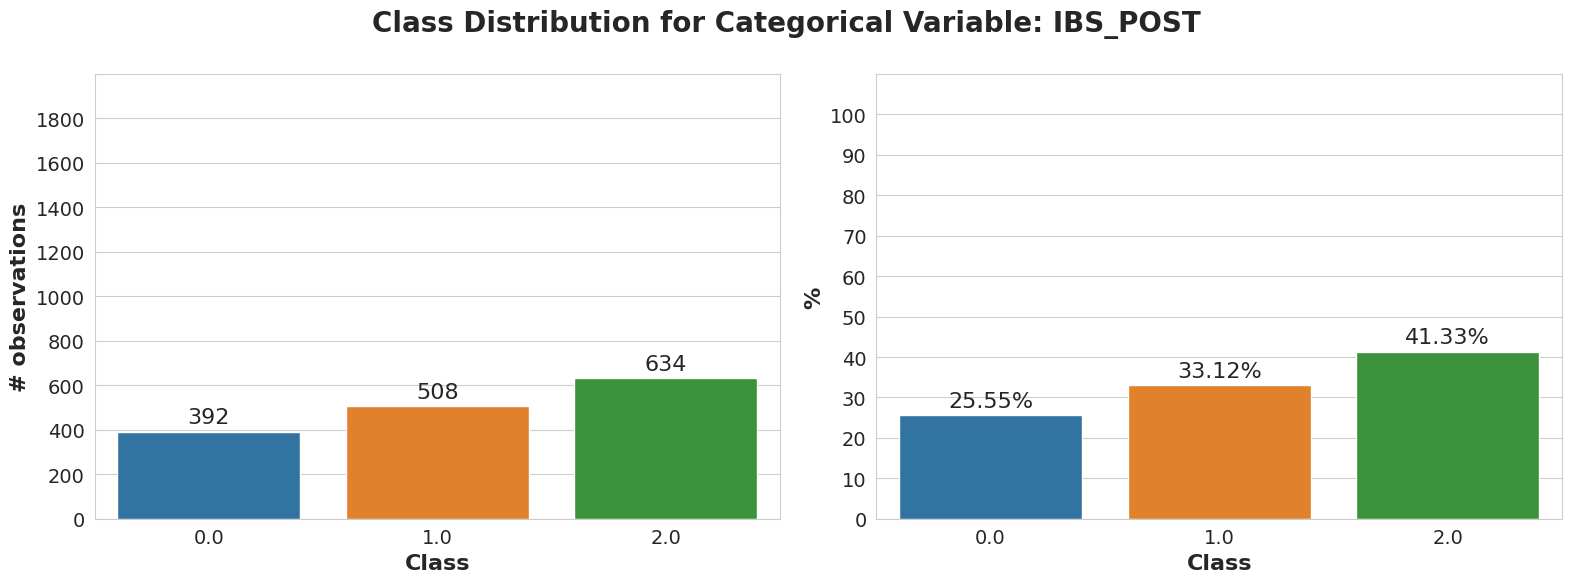

In [52]:
for cat_variable in cols_cat:
    if cat_variable!=target:

        class_counts = df[cat_variable].value_counts().sort_index()
        total = class_counts.sum()
        class_percentages = class_counts / total * 100

        unique_x_ticks_label = df[cat_variable].unique()

        fig, axes = plt.subplots(1, 2, figsize=(16, 6))

        # ------- Subplot 1: Counting the observations per class
        sns.countplot(ax=axes[0],
                      data=df,
                      x=cat_variable,
                      hue=cat_variable,
                      legend=False)
        axes[0].set_xlabel("Class", fontweight="bold", fontsize=16)
        axes[0].set_ylabel("# observations", fontweight="bold", fontsize=16)
        axes[0].set_xticks(ticks=unique_x_ticks_label, labels=unique_x_ticks_label, fontsize=14)
        axes[0].set_yticks(ticks=np.arange(0, 2000, 200),
                           labels=np.arange(0, 2000, 200),
                           fontsize=14)
        axes[0].set_ylim(0, 2000)

        for container in axes[0].containers:
            axes[0].bar_label(container, fmt="%.0f", padding=3)

        axes[0].margins(y=0.1) # Avoid clipping labels at the top

        # ------- Subplot 2: Percentage per class
        sns.barplot(ax=axes[1],
                    x=class_percentages.index.astype(str),
                    y=class_percentages.values,
                    hue=class_percentages.index.astype(str))
        axes[1].set_xlabel("Class", fontweight="bold", fontsize=16)
        axes[1].set_ylabel("%", fontweight="bold", fontsize=16)
        axes[1].set_xticks(ticks=unique_x_ticks_label, labels=unique_x_ticks_label, fontsize=14)
        axes[1].set_yticks(ticks=np.arange(0, 110, 10),
                           labels=np.arange(0, 110, 10),
                           fontsize=14)
        axes[1].set_ylim(0, 110)

        for container in axes[1].containers:
            axes[1].bar_label(container, fmt="%.2f%%", padding=3)

        axes[1].margins(y=0.1)

        # ------- General settings
        plt.suptitle(f"Class Distribution for Categorical Variable: {cat_variable}", fontsize=20, fontweight="bold")
        plt.tight_layout()

        class_distribution_path: Path = FIGURES_DATA_EXPLORATION_DIR / f"class_distribution_absolute_vs_percentage_{cat_variable}.png"
        plt.savefig(class_distribution_path, dpi=300)
        print(f"[SAVED] {class_distribution_path}")

        plt.show()